<a href="https://colab.research.google.com/github/zangatec/TC5035_Equipo10/blob/main/Proyecto_20250216.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import os
DIR = "/content/drive/MyDrive/"
os.chdir(DIR)

In [38]:
d_2023 = pd.read_csv('datos_2023.csv', delimiter = ",")
d_2024 = pd.read_csv('datos_2024.csv', delimiter = ",")
d_2022 = pd.read_csv('datos_2022.csv', delimiter = ",")

In [39]:
datos_df = pd.concat([d_2022,d_2023, d_2024], ignore_index=True)

In [5]:
 datos_df.head()

,em_segmento,em_tipo_gob,genero,uuid_rec,target,mes_informacion,f_con_credito,mes,creditos,cte_creds_prom_3ant,...,em_empl_cred_prom_6m,em_sdo_creds_emp,em_empl_saldcredt_prom_3m,em_empl_saldcredt_prom_6m,em_vencido_emp,em_empl_ven_prom_3m,em_empl_ven_prom_6m,em_castigos_emp,em_empl_cast_3m,em_empl_cast_6m
0,RELACIONADA,NaN,F,fc56b626-a3d,0,2022-01-01,1,1,1,1.0,...,44.333,1725871.51,1.788158e+06,1.930171e+06,0.0,0.0,0.000,0.0,0.000,0.000
1,PRIVADA,NaN,M,feaf8608-538,0,2022-01-01,1,1,2,2.0,...,3548.833,72304525.10,7.169885e+07,7.040020e+07,0.0,1186.3,16298.435,0.0,10638.395,9389.913
2,RELACIONADA,NaN,F,ff896d05-30a,0,2022-01-01,1,1,2,2.0,...,0.000,0.00,0.000000e+00,0.000000e+00,0.0,0.0,0.000,0.0,0.000,0.000
3,PRIVADA,NaN,F,ff5e0a39-87c,0,2022-01-01,1,1,1,1.0,...,3548.833,72304525.10,7.169885e+07,7.040020e+07,0.0,1186.3,16298.435,0.0,10638.395,9389.913
4,PRIVADA,NaN,M,fe246665-41d,0,2022-01-01,1,1,2,2.0,...,3548.833,72304525.10,7.169885e+07,7.040020e+07,0.0,1186.3,16298.435,0.0,10638.395,9389.913


In [40]:
# Se crean nuevas variables para medir cambios de los datos observados vs los promedios de los últimos 3 o 6 meses
# Diccionario con la estructura variable_resultado: (numerador, denominador)
variables = {
    "tasa_creds_3m": ("creditos", "cte_creds_prom_3ant"),
    "tasa_disp_3m": ("dispersion", "cte_dip_prom_3m"),
    "tasa_cap_3m": ("sdo_prom_capt", "sdo_cap_prom_3ant"),
    "tasa_rot_3m": ("em_rotacion_6m", "em_r6m_prom_3m"),
    "tasa_em_empl_3m": ("em_empleados", "em_empl_prom_3m"),
    "tasa_em_disp_3m": ("em_dispersion_empleados", "em_disp_prom_3m"),
    "tasa_penetracion_3m": ("em_porc_pen", "em_porc_pen_prom_3m"),
    "tasa_em_disp_prom_3m": ("em_disp_emp_prom", "em_disp_empl_prom_3m"),
    "tasa_em_creds_3m": ("em_num_creds_emp", "em_empl_cred_prom_3m"),
    "tasa_em_sdo_creds_3m": ("em_sdo_creds_emp", "em_empl_saldcredt_prom_3m"),
    "tasa_vencido_em_3m": ("em_vencido_emp", "em_empl_ven_prom_3m"),
    "tasa_cast_em_3m": ("em_castigos_emp", "em_empl_cast_3m"),
    "tasa_disper_vs_inicial": ("dispersion", "dispersion_inicial"),
    "cap3m_disp3m": ("sdo_cap_prom_3ant", "cte_dip_prom_3m"),
    "cap6m_disp6m": ("sdo_cap_prom_6ant", "cte_dip_prom_6m"),
    "catp_disper": ("sdo_prom_capt", "dispersion"),
    "disp6m_dispinicial": ("cte_dip_prom_6m", "dispersion_inicial"),
    "disp3m_dispinicial": ("cte_dip_prom_3m", "dispersion_inicial"),
    "tasa_creds_6m": ("creditos", "cte_creds_prom_6ant"),
    "tasa_disp_6m": ("dispersion", "cte_dip_prom_6m"),
    "tasa_cap_6m": ("sdo_prom_capt", "sdo_cap_prom_6ant"),
    "tasa_rot_6m": ("em_rotacion_6m", "em_r6m_prom_6m"),
    "tasa_em_empl_6m": ("em_empleados", "em_empl_prom_6m"),
    "tasa_em_disp_6m": ("em_dispersion_empleados", "em_disp_prom_6m"),
    "tasa_penetracion_6m": ("em_porc_pen", "em_porc_pen_prom_6m"),
    "tasa_em_disp_prom_6m": ("em_disp_emp_prom", "em_disp_empl_prom_6m"),
    "tasa_em_creds_6m": ("em_num_creds_emp", "em_empl_cred_prom_6m"),
    "tasa_em_sdo_creds_6m": ("em_sdo_creds_emp", "em_empl_saldcredt_prom_6m"),
    "tasa_vencido_em_6m": ("em_vencido_emp", "em_empl_ven_prom_6m"),
    "tasa_cast_em_6m": ("em_castigos_emp", "em_empl_cast_6m"),

     "disper_edad_ingreso": ("dispersion", "edad_ingreso"),
    "disper_edad_mes": ("dispersion", "edad_perdida_emp")

}

# Crear las nuevas variables con tratamiento de división por cero
for nueva_var, (num, denom) in variables.items():
    datos_df[nueva_var] = datos_df[num] / datos_df[denom]
    datos_df[nueva_var] = datos_df[nueva_var].where(datos_df[denom] != 0, 0)  # Si el denominador es 0, asigna 0

# Mostrar el DataFrame con las nuevas variables
print(datos_df.head())

   em_segmento em_tipo_gob genero      uuid_rec  target mes_informacion  \
0  RELACIONADA         NaN      F  fc56b626-a3d       0      2022-01-01   
1      PRIVADA         NaN      M  feaf8608-538       0      2022-01-01   
2  RELACIONADA         NaN      F  ff896d05-30a       0      2022-01-01   
3      PRIVADA         NaN      F  ff5e0a39-87c       0      2022-01-01   
4      PRIVADA         NaN      M  fe246665-41d       0      2022-01-01   

   f_con_credito  mes  creditos  cte_creds_prom_3ant  ...  tasa_em_empl_6m  \
0              1    1         1                  1.0  ...         1.007519   
1              1    1         2                  2.0  ...         1.073876   
2              1    1         2                  2.0  ...         1.000000   
3              1    1         1                  1.0  ...         1.073876   
4              1    1         2                  2.0  ...         1.073876   

   tasa_em_disp_6m  tasa_penetracion_6m  tasa_em_disp_prom_6m  \
0         0.798

## **EDA**

**El Análisis Exploratorio de Datos** (EDA, por sus siglas en inglés) es el proceso inicial en la ciencia de datos que permite comprender la estructura, la calidad y las relaciones dentro del conjunto de datos antes de aplicar modelos de machine learning o técnicas avanzadas.

In [7]:
# Dimensiones del dataset
print(f"Filas: {datos_df.shape[0]}, Columnas: {datos_df.shape[1]}")


Filas: 7347882, Columnas: 82


In [8]:
# Tipos de datos y valores nulos
print(datos_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7347882 entries, 0 to 7347881
Data columns (total 82 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   em_segmento                object 
 1   em_tipo_gob                object 
 2   genero                     object 
 3   uuid_rec                   object 
 4   target                     int64  
 5   mes_informacion            object 
 6   f_con_credito              int64  
 7   mes                        int64  
 8   creditos                   int64  
 9   cte_creds_prom_3ant        float64
 10  cte_creds_prom_6ant        float64
 11  dispersion_inicial         float64
 12  dispersion                 float64
 13  cte_dip_prom_3m            float64
 14  cte_dip_prom_6m            float64
 15  sdo_prom_capt              float64
 16  sdo_cap_prom_3ant          float64
 17  sdo_cap_prom_6ant          float64
 18  edad_ingreso               int64  
 19  edad_perdida_emp           int64  
 20  me

In [9]:
#Estadística descriptiva
df_describe = datos_df.describe().T
pd.options.display.float_format = '{:.2f}'.format
df_describe

,count,mean,std,min,25%,50%,75%,max
target,7347882.00,0.04,0.20,0.00,0.00,0.00,0.00,1.00
f_con_credito,7347882.00,0.18,0.38,0.00,0.00,0.00,0.00,1.00
mes,7347882.00,6.03,3.33,1.00,3.00,6.00,9.00,12.00
creditos,7347882.00,0.21,0.51,0.00,0.00,0.00,0.00,57.00
cte_creds_prom_3ant,7347882.00,0.21,0.50,0.00,0.00,0.00,0.00,56.00
...,...,...,...,...,...,...,...,...
tasa_em_sdo_creds_6m,7347882.00,0.96,0.45,0.00,0.96,1.02,1.08,5.93
tasa_vencido_em_6m,7347882.00,0.19,0.45,0.00,0.00,0.00,0.00,3.66
tasa_cast_em_6m,7347882.00,0.05,0.30,-0.13,0.00,0.00,0.00,4.69
disper_edad_ingreso,7347882.00,373.30,1573.20,0.00,169.19,276.90,445.29,2951972.05


In [10]:
datos_df.describe(include="object")

,em_segmento,em_tipo_gob,genero,uuid_rec,mes_informacion
count,7343193,2703217,7347882,7347882,7347882
unique,9,4,4,543935,32
top,PYME,MUNICIPAL,M,fe3e1ae0-39c,2023-10-01
freq,2743929,1580316,4293417,32,239108


In [41]:
datos_df['mes'] =datos_df['mes'].astype(str)

In [42]:
 categoricas = [ 'em_segmento',  'em_tipo_gob' , 'genero' , 'mes']

In [13]:
# Conteo de categorías
print(datos_df[categoricas].nunique())

em_segmento     9
em_tipo_gob     4
genero          4
mes            12
dtype: int64


In [14]:
# Porcentaje de valores nulos por columna
porcentaje_nulos = datos_df.isnull().mean() * 100
porcentaje_nulos


,0
em_segmento,0.06
em_tipo_gob,63.21
genero,0.00
uuid_rec,0.00
target,0.00
...,...
tasa_em_sdo_creds_6m,0.00
tasa_vencido_em_6m,0.00
tasa_cast_em_6m,0.00
disper_edad_ingreso,0.00


In [43]:
datos_df.loc[datos_df['em_segmento'] == 'GOBIERNO', 'em_segmento'] = datos_df['em_tipo_gob']

In [9]:
# Para visualizar la distribución del cambpo em_segmento
conteo = datos_df["em_segmento"].value_counts()
porcentaje = datos_df["em_segmento"].value_counts(normalize=True) * 100
resultado = pd.DataFrame({"Conteo": conteo, "Porcentaje": porcentaje})
print(resultado)

                   Conteo  Porcentaje
em_segmento                          
PYME              2743929   37.378671
MUNICIPAL         1579637   21.518316
ESTATAL           1024164   13.951487
EMPRESAS          1018756   13.877817
CORPORATIVA        627328    8.545661
PRIVADA            136912    1.865059
RELACIONADA        109072    1.485813
FEDERAL             97129    1.323122
INCLUSION SOCIAL     2075    0.028266
AFIRME               1568    0.021360
ALIANZAS              267    0.003637
FIDEICOMISO            58    0.000790


In [44]:
# Hacemos un reagrupado para reducir las categorías
mapeo_segmento = {
    "FEDERAL": "ESTATAL",  # Agrupar FEDERAL con ESTATAL
    "PRIVADA": "CORPORATIVO",
    "RELACIONADA": "CORPORATIVO",
    "INCLUSION SOCIAL": "CORPORATIVO",
    "AFIRME": "CORPORATIVO",
    "ALIANZAS": "CORPORATIVO",
    "FIDEICOMISO": "CORPORATIVO",

    "CORPORATIVA": "CORPORATIVO"
    }

# Aplicar el mapeo a la columna
datos_df["em_segmento"] = datos_df["em_segmento"].replace(mapeo_segmento)



In [18]:
# Para visualizar la distribución del cambpo em_segmento
conteo = datos_df["em_segmento"].value_counts()
porcentaje = datos_df["em_segmento"].value_counts(normalize=True) * 100
resultado = pd.DataFrame({"Conteo": conteo, "Porcentaje": porcentaje})
print(resultado)

              Conteo  Porcentaje
em_segmento                     
PYME         2743929       37.38
MUNICIPAL    1579637       21.52
ESTATAL      1121293       15.27
EMPRESAS     1018756       13.88
CORPORATIVO   877280       11.95


In [45]:
#Imputación de "segmento" con la moda
datos_df["em_segmento"].fillna(datos_df["em_segmento"].mode()[0], inplace=True)
# Verificar que no haya valores faltantes en la columna
print(datos_df["em_segmento"].isnull().sum())
# Mostrar las frecuencias de la variable categórica
print(datos_df["em_segmento"].value_counts())

0
em_segmento
PYME           2750916
MUNICIPAL      1579637
ESTATAL        1121293
EMPRESAS       1018756
CORPORATIVO     877280
Name: count, dtype: int64


In [20]:
datos_df['genero'].value_counts()

,count
genero,
M,4293417
F,3054045
Otro,407
R,13


In [46]:
#Imputación de "genero" con la moda para los datos que no sean "M" o "F"

# Calcular la moda de la variable "genero"
moda_genero = datos_df['genero'].mode()[0]  # La moda es el valor más frecuente

# Reemplazar valores que no sean "F" o "M" con la moda
datos_df.loc[~datos_df['genero'].isin(['F', 'M']), 'genero'] = moda_genero

In [22]:
datos_df['genero'].value_counts()

,count
genero,
M,4293837
F,3054045


In [13]:
# Se elimina por tener 63% de nulos
datos_df = datos_df.drop(columns=['em_tipo_gob'])

In [24]:
#Tamaño del df antes de eliminar duplicados
print(len(datos_df))

7347882


In [25]:
# Eliminar duplicados si existen
datos_df = datos_df.drop_duplicates()
print(len(datos_df))

7347882


In [47]:
# Se crea lista para agrupar las variables numéricas y puedan manipularse fácilmente
numericas = datos_df.select_dtypes(include=['number']).columns.tolist()
numericas = [col for col in numericas if col != 'target']
numericas

['f_con_credito',
 'creditos',
 'cte_creds_prom_3ant',
 'cte_creds_prom_6ant',
 'dispersion_inicial',
 'dispersion',
 'cte_dip_prom_3m',
 'cte_dip_prom_6m',
 'sdo_prom_capt',
 'sdo_cap_prom_3ant',
 'sdo_cap_prom_6ant',
 'edad_ingreso',
 'edad_perdida_emp',
 'meses_antig_en_bco',
 'meses_antig_en_emp',
 'em_antig_dispersando',
 'em_rotacion_6m',
 'em_r6m_prom_3m',
 'em_r6m_prom_6m',
 'em_empleados',
 'em_empl_prom_3m',
 'em_empl_prom_6m',
 'em_dispersion_empleados',
 'em_disp_prom_3m',
 'em_disp_prom_6m',
 'em_porc_pen',
 'em_porc_pen_prom_3m',
 'em_porc_pen_prom_6m',
 'em_disp_emp_prom',
 'em_disp_empl_prom_3m',
 'em_disp_empl_prom_6m',
 'em_num_creds_emp',
 'em_empl_cred_prom_3m',
 'em_empl_cred_prom_6m',
 'em_sdo_creds_emp',
 'em_empl_saldcredt_prom_3m',
 'em_empl_saldcredt_prom_6m',
 'em_vencido_emp',
 'em_empl_ven_prom_3m',
 'em_empl_ven_prom_6m',
 'em_castigos_emp',
 'em_empl_cast_3m',
 'em_empl_cast_6m',
 'tasa_creds_3m',
 'tasa_disp_3m',
 'tasa_cap_3m',
 'tasa_rot_3m',
 'tasa_em


 Análisis de la columna: f_con_credito
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0
Valor maximo =  1
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1306253


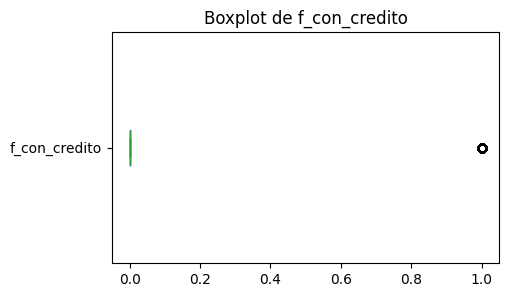

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.777272416731787 %

 Análisis de la columna: creditos
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0
Valor maximo =  57
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1306253


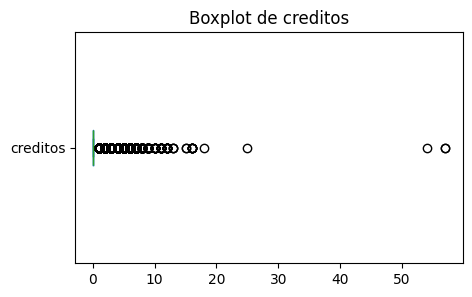

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.777272416731787 %

 Análisis de la columna: cte_creds_prom_3ant
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  56.0
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1314359


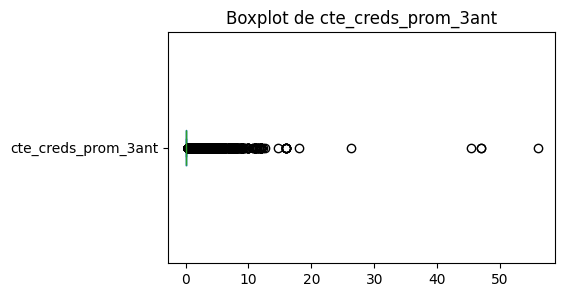

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.887589920469598 %

 Análisis de la columna: cte_creds_prom_6ant
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  52.167
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1345479


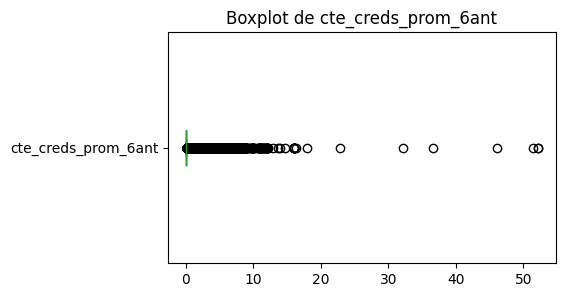

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 18.311113324900973 %

 Análisis de la columna: dispersion_inicial
Cuartil 1=  4875.333
Cuartil 3=  10561.333
Rango intercuartilico=  5686.000000000001
Mediana =  7010.133
Valor minimo =  0.0
Valor maximo =  16298406.513
El bigote superior de la gráfica de cajas es  19090.333000000002
El bigote inferior de la gráfica de cajas es  -3653.667000000002
los datos atípicos en esta columna son: 503676


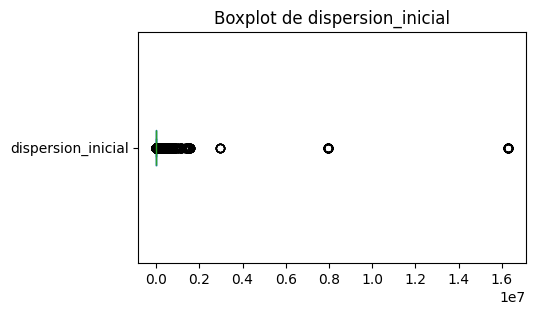

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.854709969485084 %

 Análisis de la columna: dispersion
Cuartil 1=  6464.342500000001
Cuartil 3=  15163.42
Rango intercuartilico=  8699.0775
Mediana =  9619.5
Valor minimo =  0.01
Valor maximo =  171943518.58
El bigote superior de la gráfica de cajas es  28212.036249999997
El bigote inferior de la gráfica de cajas es  -6584.2737499999985
los datos atípicos en esta columna son: 549591


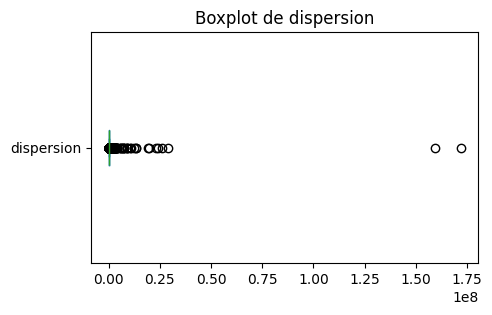

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 7.479583912752001 %

 Análisis de la columna: cte_dip_prom_3m
Cuartil 1=  6645.26175
Cuartil 3=  15390.376
Rango intercuartilico=  8745.11425
Mediana =  9918.8
Valor minimo =  0.0
Valor maximo =  57511846.787
El bigote superior de la gráfica de cajas es  28508.047375000002
El bigote inferior de la gráfica de cajas es  -6472.409625000002
los datos atípicos en esta columna son: 485084


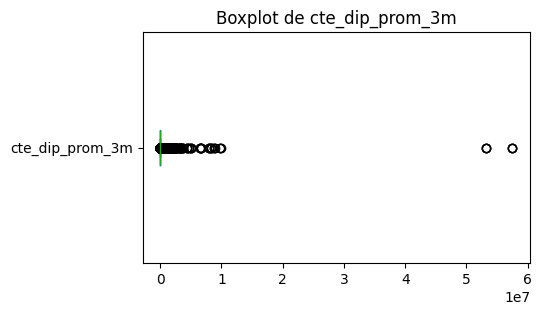

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.601684675937909 %

 Análisis de la columna: cte_dip_prom_6m
Cuartil 1=  6620.333
Cuartil 3=  15224.666
Rango intercuartilico=  8604.332999999999
Mediana =  9891.207
Valor minimo =  0.0
Valor maximo =  32744043.272
El bigote superior de la gráfica de cajas es  28131.165499999996
El bigote inferior de la gráfica de cajas es  -6286.166499999998
los datos atípicos en esta columna son: 460887


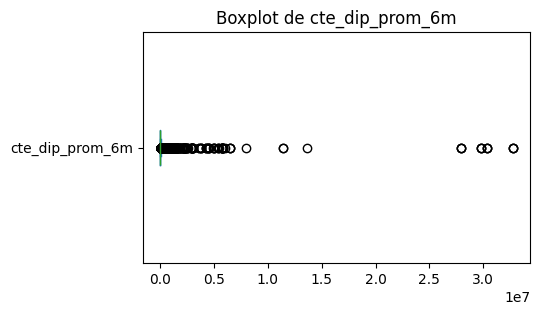

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.272378897755843 %

 Análisis de la columna: sdo_prom_capt
Cuartil 1=  231.04
Cuartil 3=  3037.58
Rango intercuartilico=  2806.54
Mediana =  855.43
Valor minimo =  0.0
Valor maximo =  72179291.15
El bigote superior de la gráfica de cajas es  7247.389999999999
El bigote inferior de la gráfica de cajas es  -3978.7699999999995
los datos atípicos en esta columna son: 1061324


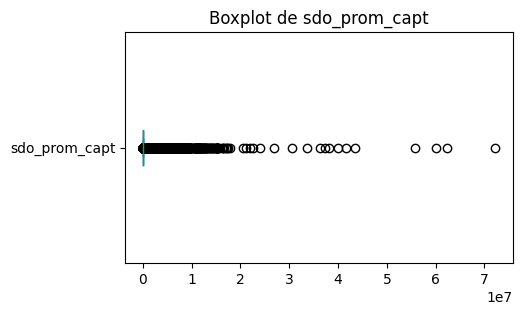

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 14.443944527144012 %

 Análisis de la columna: sdo_cap_prom_3ant
Cuartil 1=  314.957
Cuartil 3=  3253.9275
Rango intercuartilico=  2938.9705
Mediana =  974.9515
Valor minimo =  0.0
Valor maximo =  59479868.07
El bigote superior de la gráfica de cajas es  7662.38325
El bigote inferior de la gráfica de cajas es  -4093.49875
los datos atípicos en esta columna son: 1023839


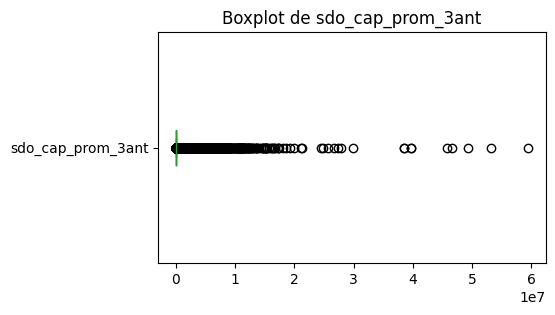

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.933797521517086 %

 Análisis de la columna: sdo_cap_prom_6ant
Cuartil 1=  354.44
Cuartil 3=  3367.557
Rango intercuartilico=  3013.1169999999997
Mediana =  1037.173
Valor minimo =  0.0
Valor maximo =  52635542.125
El bigote superior de la gráfica de cajas es  7887.232499999999
El bigote inferior de la gráfica de cajas es  -4165.2355
los datos atípicos en esta columna son: 1003410


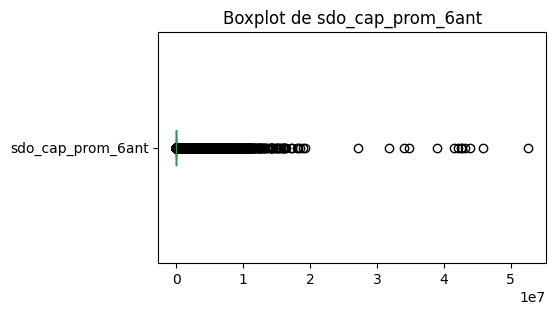

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.655771826493677 %

 Análisis de la columna: edad_ingreso
Cuartil 1=  28.0
Cuartil 3=  48.0
Rango intercuartilico=  20.0
Mediana =  37.0
Valor minimo =  18
Valor maximo =  100
El bigote superior de la gráfica de cajas es  78.0
El bigote inferior de la gráfica de cajas es  -2.0
los datos atípicos en esta columna son: 25094


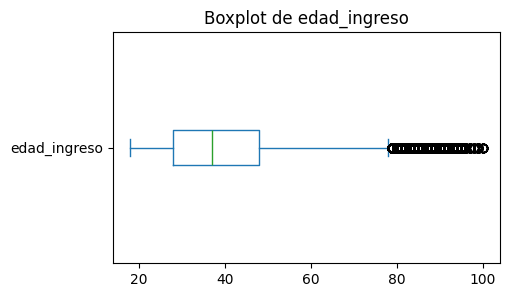

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.34151337759642847 %

 Análisis de la columna: edad_perdida_emp
Cuartil 1=  31.0
Cuartil 3=  52.0
Rango intercuartilico=  21.0
Mediana =  41.0
Valor minimo =  18
Valor maximo =  105
El bigote superior de la gráfica de cajas es  83.5
El bigote inferior de la gráfica de cajas es  -0.5
los datos atípicos en esta columna son: 25404


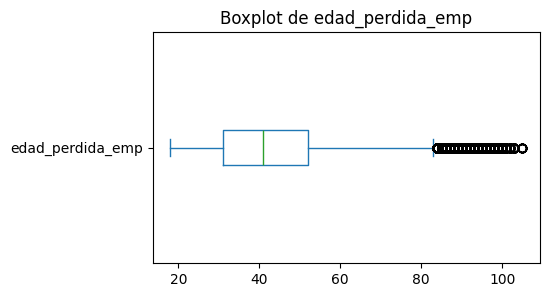

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.34573228040406745 %

 Análisis de la columna: meses_antig_en_bco
Cuartil 1=  8.0
Cuartil 3=  65.0
Rango intercuartilico=  57.0
Mediana =  26.0
Valor minimo =  0
Valor maximo =  103
El bigote superior de la gráfica de cajas es  150.5
El bigote inferior de la gráfica de cajas es  -77.5
los datos atípicos en esta columna son: 0


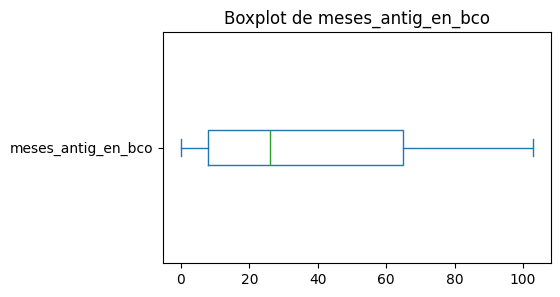

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.0 %

 Análisis de la columna: meses_antig_en_emp
Cuartil 1=  7.0
Cuartil 3=  53.0
Rango intercuartilico=  46.0
Mediana =  22.0
Valor minimo =  0
Valor maximo =  103
El bigote superior de la gráfica de cajas es  122.0
El bigote inferior de la gráfica de cajas es  -62.0
los datos atípicos en esta columna son: 0


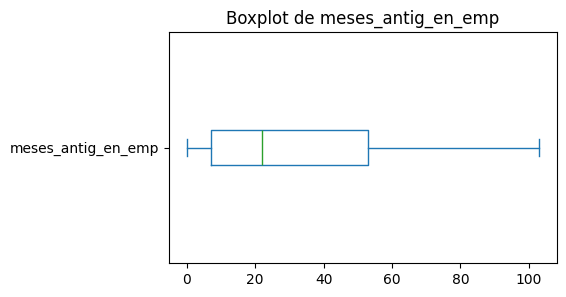

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.0 %

 Análisis de la columna: em_antig_dispersando
Cuartil 1=  36.0
Cuartil 3=  87.0
Rango intercuartilico=  51.0
Mediana =  73.0
Valor minimo =  0
Valor maximo =  102
El bigote superior de la gráfica de cajas es  163.5
El bigote inferior de la gráfica de cajas es  -40.5
los datos atípicos en esta columna son: 0


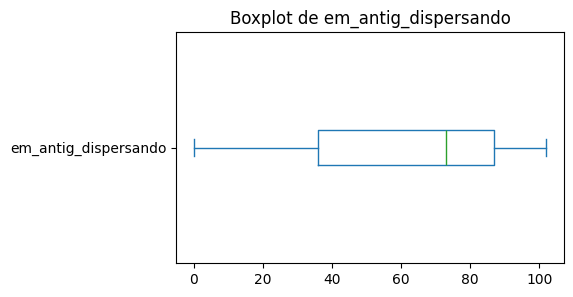

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.0 %

 Análisis de la columna: em_rotacion_6m
Cuartil 1=  0.054
Cuartil 3=  0.233
Rango intercuartilico=  0.17900000000000002
Mediana =  0.132
Valor minimo =  0.0
Valor maximo =  1.0
El bigote superior de la gráfica de cajas es  0.5015000000000001
El bigote inferior de la gráfica de cajas es  -0.21450000000000002
los datos atípicos en esta columna son: 354119


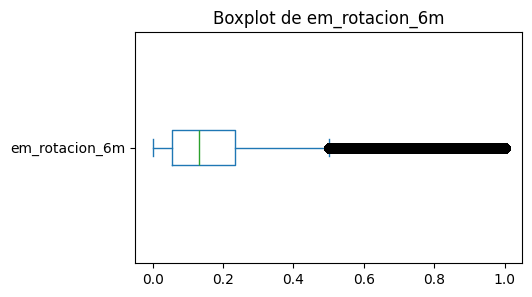

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.819334333349393 %

 Análisis de la columna: em_r6m_prom_3m
Cuartil 1=  0.056
Cuartil 3=  0.234
Rango intercuartilico=  0.17800000000000002
Mediana =  0.136
Valor minimo =  0.0
Valor maximo =  1.0
El bigote superior de la gráfica de cajas es  0.501
El bigote inferior de la gráfica de cajas es  -0.21100000000000002
los datos atípicos en esta columna son: 363601


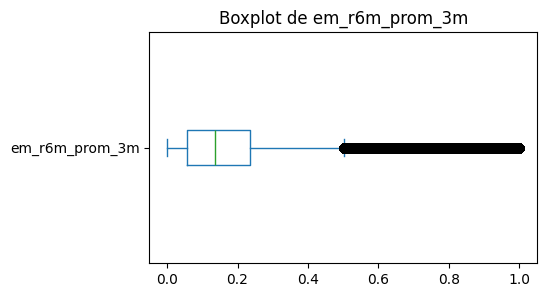

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.948378321807563 %

 Análisis de la columna: em_r6m_prom_6m
Cuartil 1=  0.058
Cuartil 3=  0.236
Rango intercuartilico=  0.178
Mediana =  0.14
Valor minimo =  0.0
Valor maximo =  1.0
El bigote superior de la gráfica de cajas es  0.503
El bigote inferior de la gráfica de cajas es  -0.20900000000000002
los datos atípicos en esta columna son: 369988


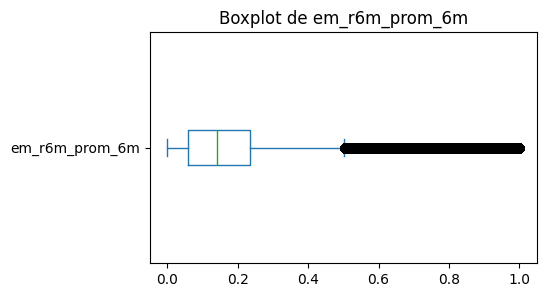

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 5.0353013290088215 %

 Análisis de la columna: em_empleados
Cuartil 1=  127.0
Cuartil 3=  3374.0
Rango intercuartilico=  3247.0
Mediana =  738.0
Valor minimo =  0
Valor maximo =  18402
El bigote superior de la gráfica de cajas es  8244.5
El bigote inferior de la gráfica de cajas es  -4743.5
los datos atípicos en esta columna son: 480689


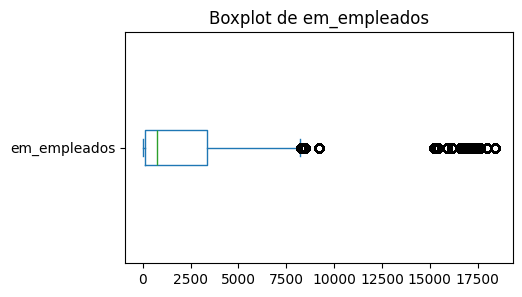

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.541871521616706 %

 Análisis de la columna: em_empl_prom_3m
Cuartil 1=  126.333
Cuartil 3=  3368.333
Rango intercuartilico=  3242.0
Mediana =  728.0
Valor minimo =  0.0
Valor maximo =  18003.667
El bigote superior de la gráfica de cajas es  8231.333
El bigote inferior de la gráfica de cajas es  -4736.667
los datos atípicos en esta columna son: 487486


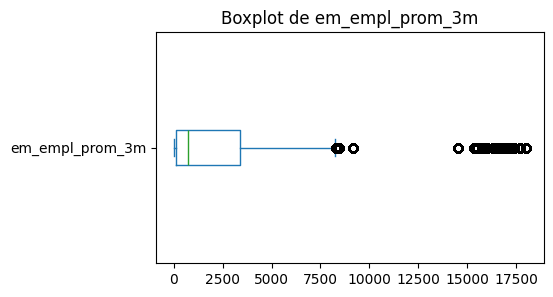

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.634374368015164 %

 Análisis de la columna: em_empl_prom_6m
Cuartil 1=  124.5
Cuartil 3=  3366.333
Rango intercuartilico=  3241.833
Mediana =  719.833
Valor minimo =  0.0
Valor maximo =  17605.0
El bigote superior de la gráfica de cajas es  8229.0825
El bigote inferior de la gráfica de cajas es  -4738.2495
los datos atípicos en esta columna son: 500931


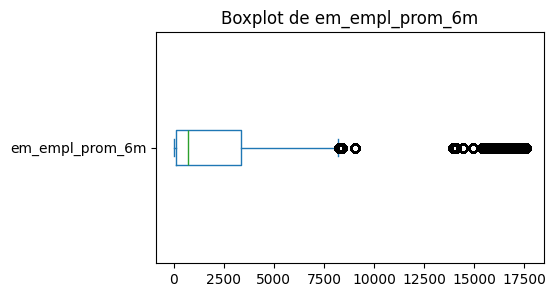

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.817352265591636 %

 Análisis de la columna: em_dispersion_empleados
Cuartil 1=  1171712.68
Cuartil 3=  46296429.47
Rango intercuartilico=  45124716.79
Mediana =  7614279.72
Valor minimo =  0.0
Valor maximo =  364306551.59
El bigote superior de la gráfica de cajas es  113983504.655
El bigote inferior de la gráfica de cajas es  -66515362.505
los datos atípicos en esta columna son: 456317


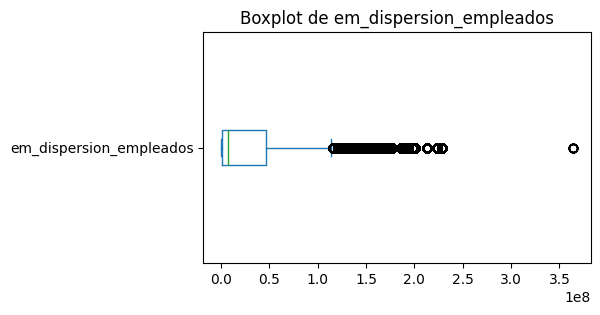

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.210184104752907 %

 Análisis de la columna: em_disp_prom_3m
Cuartil 1=  1167167.263
Cuartil 3=  46209137.857
Rango intercuartilico=  45041970.594000004
Mediana =  7680829.513
Valor minimo =  0.0
Valor maximo =  179772937.76
El bigote superior de la gráfica de cajas es  113772093.748
El bigote inferior de la gráfica de cajas es  -66395788.628000006
los datos atípicos en esta columna son: 520356


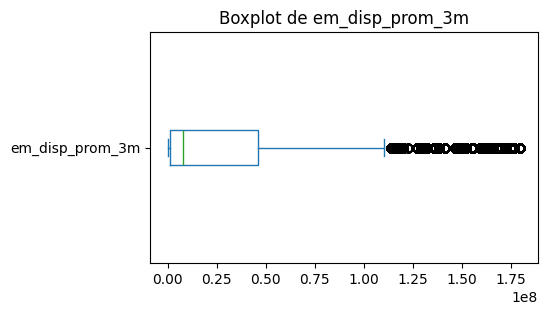

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 7.0817141592638535 %

 Análisis de la columna: em_disp_prom_6m
Cuartil 1=  1145919.333
Cuartil 3=  46035316.622
Rango intercuartilico=  44889397.289000005
Mediana =  7504799.185
Valor minimo =  0.0
Valor maximo =  173941962.44
El bigote superior de la gráfica de cajas es  113369412.5555
El bigote inferior de la gráfica de cajas es  -66188176.60050001
los datos atípicos en esta columna son: 457630


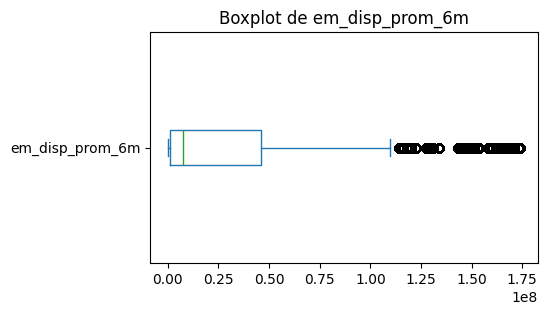

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.228053199547842 %

 Análisis de la columna: em_porc_pen
Cuartil 1=  0.093
Cuartil 3=  0.382
Rango intercuartilico=  0.28900000000000003
Mediana =  0.253
Valor minimo =  0.0
Valor maximo =  1.0
El bigote superior de la gráfica de cajas es  0.8155000000000001
El bigote inferior de la gráfica de cajas es  -0.3405
los datos atípicos en esta columna son: 1107


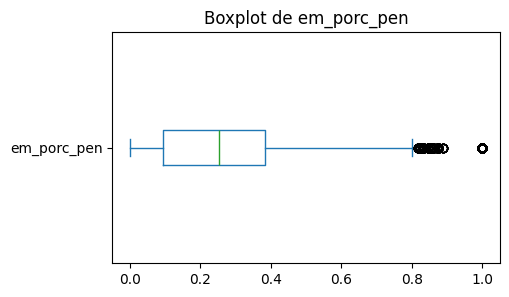

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.015065565832439879 %

 Análisis de la columna: em_porc_pen_prom_3m
Cuartil 1=  0.107
Cuartil 3=  0.544
Rango intercuartilico=  0.43700000000000006
Mediana =  0.315
Valor minimo =  0.0
Valor maximo =  3.0
El bigote superior de la gráfica de cajas es  1.1995
El bigote inferior de la gráfica de cajas es  -0.5485000000000001
los datos atípicos en esta columna son: 1348


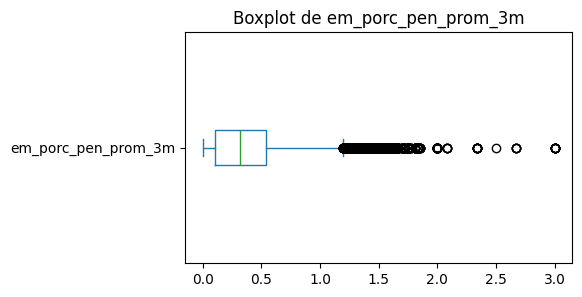

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.018345422531281803 %

 Análisis de la columna: em_porc_pen_prom_6m
Cuartil 1=  0.105
Cuartil 3=  0.538
Rango intercuartilico=  0.43300000000000005
Mediana =  0.309
Valor minimo =  0.0
Valor maximo =  3.0
El bigote superior de la gráfica de cajas es  1.1875
El bigote inferior de la gráfica de cajas es  -0.5445000000000001
los datos atípicos en esta columna son: 1269


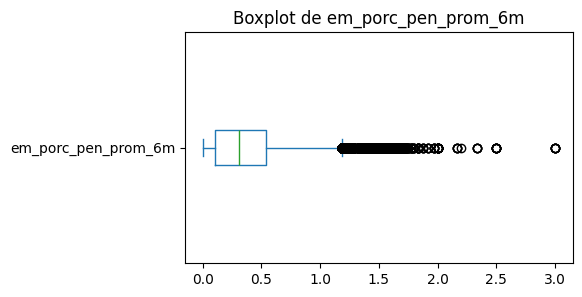

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 0.01727028278352864 %

 Análisis de la columna: em_disp_emp_prom
Cuartil 1=  7913.368
Cuartil 3=  13910.22
Rango intercuartilico=  5996.851999999999
Mediana =  10657.849
Valor minimo =  0.0
Valor maximo =  18215327.58
El bigote superior de la gráfica de cajas es  22905.498
El bigote inferior de la gráfica de cajas es  -1081.909999999998
los datos atípicos en esta columna son: 292144


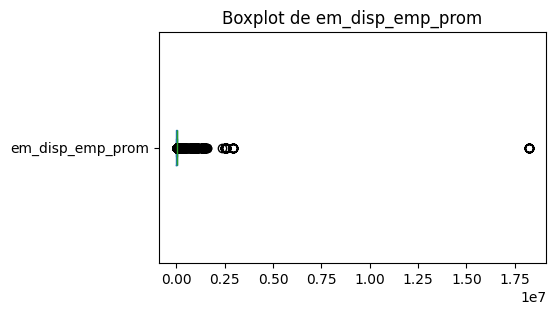

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 3.9758940059189847 %

 Análisis de la columna: em_disp_empl_prom_3m
Cuartil 1=  8091.85
Cuartil 3=  14004.264
Rango intercuartilico=  5912.413999999999
Mediana =  10602.877
Valor minimo =  0.0
Valor maximo =  6120526.916
El bigote superior de la gráfica de cajas es  22872.885
El bigote inferior de la gráfica de cajas es  -776.7709999999988
los datos atípicos en esta columna son: 277467


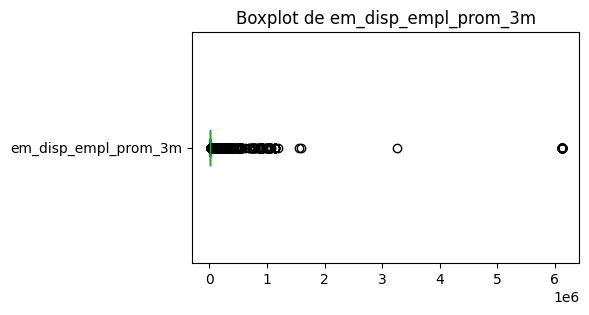

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 3.7761493720231214 %

 Análisis de la columna: em_disp_empl_prom_6m
Cuartil 1=  8018.042
Cuartil 3=  13885.536
Rango intercuartilico=  5867.494
Mediana =  10546.012
Valor minimo =  0.0
Valor maximo =  3503533.301
El bigote superior de la gráfica de cajas es  22686.777000000002
El bigote inferior de la gráfica de cajas es  -783.1989999999996
los datos atípicos en esta columna son: 244772


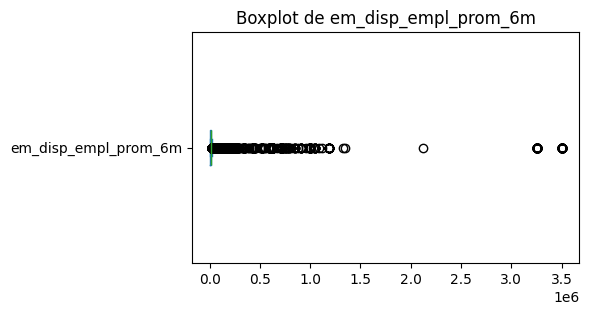

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 3.3311912194561644 %

 Análisis de la columna: em_num_creds_emp
Cuartil 1=  12.0
Cuartil 3=  1923.0
Rango intercuartilico=  1911.0
Mediana =  167.0
Valor minimo =  0
Valor maximo =  8226
El bigote superior de la gráfica de cajas es  4789.5
El bigote inferior de la gráfica de cajas es  -2854.5
los datos atípicos en esta columna son: 256785


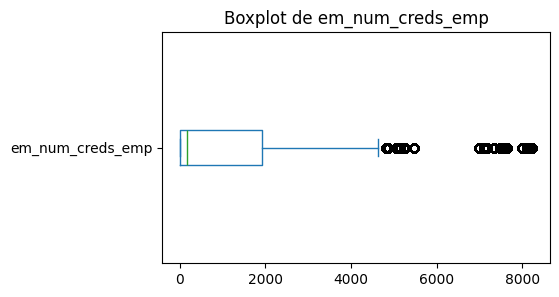

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 3.4946805079341234 %

 Análisis de la columna: em_empl_cred_prom_3m
Cuartil 1=  11.667
Cuartil 3=  1897.0
Rango intercuartilico=  1885.333
Mediana =  165.0
Valor minimo =  0.0
Valor maximo =  8132.333
El bigote superior de la gráfica de cajas es  4724.9995
El bigote inferior de la gráfica de cajas es  -2816.3325
los datos atípicos en esta columna son: 315993


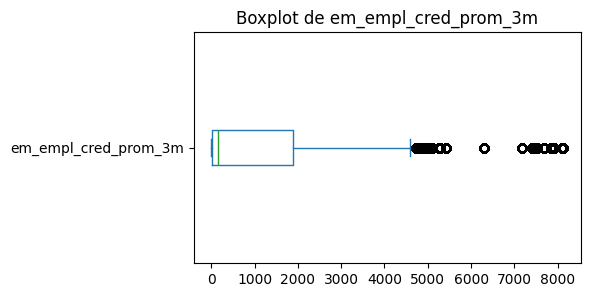

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.300463725465379 %

 Análisis de la columna: em_empl_cred_prom_6m
Cuartil 1=  11.333
Cuartil 3=  1876.833
Rango intercuartilico=  1865.5
Mediana =  162.0
Valor minimo =  0.0
Valor maximo =  7911.333
El bigote superior de la gráfica de cajas es  4675.0830000000005
El bigote inferior de la gráfica de cajas es  -2786.917
los datos atípicos en esta columna son: 313602


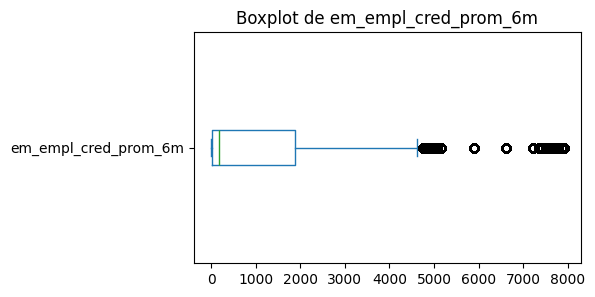

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.267923736390976 %

 Análisis de la columna: em_sdo_creds_emp
Cuartil 1=  72402.22
Cuartil 3=  29932733.89
Rango intercuartilico=  29860331.67
Mediana =  2336708.81
Valor minimo =  0.0
Valor maximo =  214485264.52
El bigote superior de la gráfica de cajas es  74723231.39500001
El bigote inferior de la gráfica de cajas es  -44718095.285000004
los datos atípicos en esta columna son: 892601


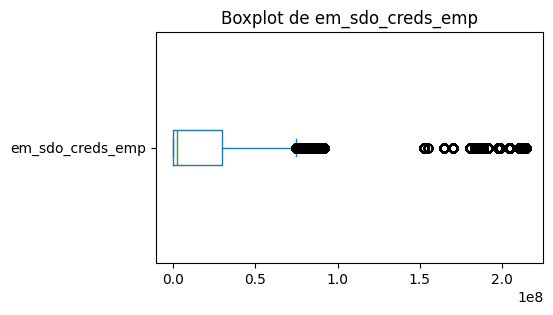

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 12.147731822585065 %

 Análisis de la columna: em_empl_saldcredt_prom_3m
Cuartil 1=  70003.923
Cuartil 3=  29698538.89
Rango intercuartilico=  29628534.967
Mediana =  2263857.427
Valor minimo =  0.0
Valor maximo =  213519430.94
El bigote superior de la gráfica de cajas es  74141341.3405
El bigote inferior de la gráfica de cajas es  -44372798.527499996
los datos atípicos en esta columna son: 905017


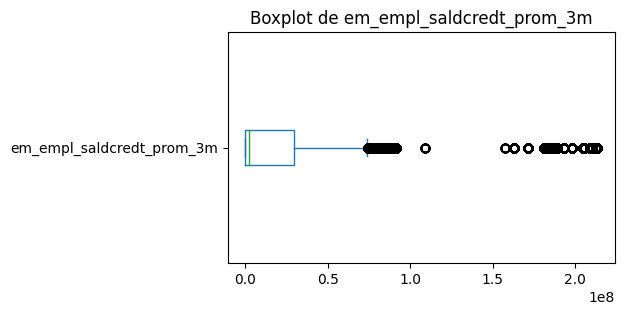

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 12.316705684712955 %

 Análisis de la columna: em_empl_saldcredt_prom_6m
Cuartil 1=  66127.547
Cuartil 3=  28959601.613
Rango intercuartilico=  28893474.066000003
Mediana =  2165059.34
Valor minimo =  0.0
Valor maximo =  211365944.39
El bigote superior de la gráfica de cajas es  72299812.71200001
El bigote inferior de la gráfica de cajas es  -43274083.55200001
los datos atípicos en esta columna son: 929923


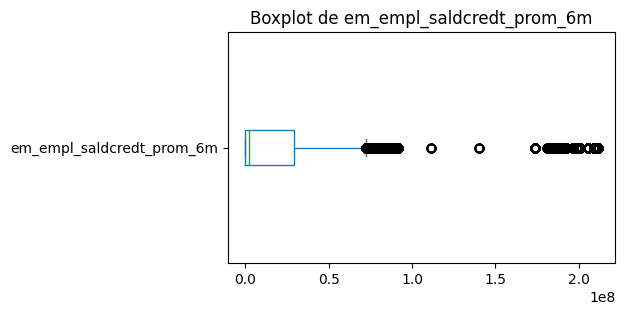

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 12.655660501897009 %

 Análisis de la columna: em_vencido_emp
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  20556076.42
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1408355


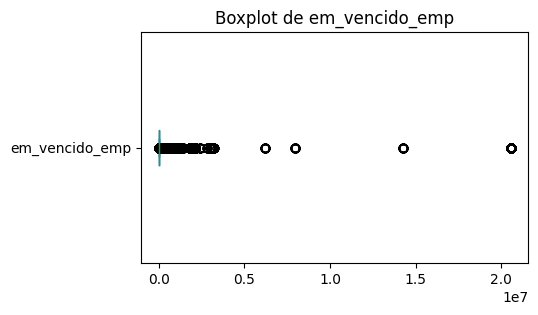

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 19.166815689201325 %

 Análisis de la columna: em_empl_ven_prom_3m
Cuartil 1=  0.0
Cuartil 3=  350.0
Rango intercuartilico=  350.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  12076661.983
El bigote superior de la gráfica de cajas es  875.0
El bigote inferior de la gráfica de cajas es  -525.0
los datos atípicos en esta columna son: 1740812


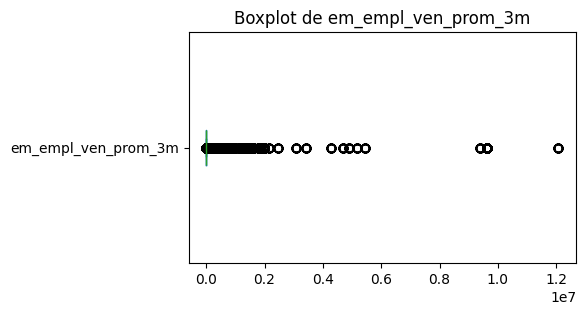

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 23.69134398184402 %

 Análisis de la columna: em_empl_ven_prom_6m
Cuartil 1=  0.0
Cuartil 3=  21644.823
Rango intercuartilico=  21644.823
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  7754908.595
El bigote superior de la gráfica de cajas es  54112.057499999995
El bigote inferior de la gráfica de cajas es  -32467.2345
los datos atípicos en esta columna son: 1091954


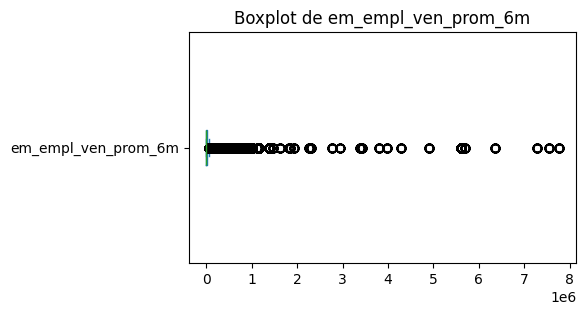

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 14.860799343266537 %

 Análisis de la columna: em_castigos_emp
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  -22.73
Valor maximo =  7629429.98
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 332835


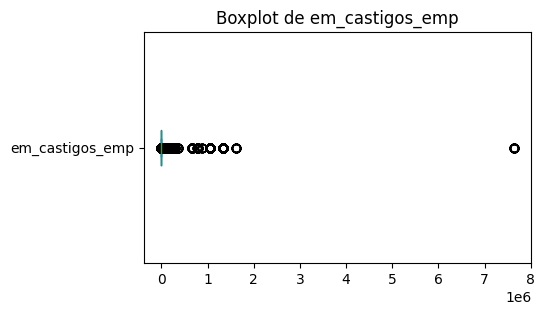

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.529672632195237 %

 Análisis de la columna: em_empl_cast_3m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  -22.73
Valor maximo =  4475940.295
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 742598


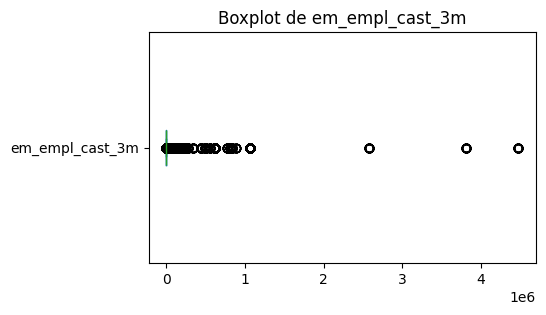

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 10.106286410151933 %

 Análisis de la columna: em_empl_cast_6m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  -22.73
Valor maximo =  2577765.35
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1273862


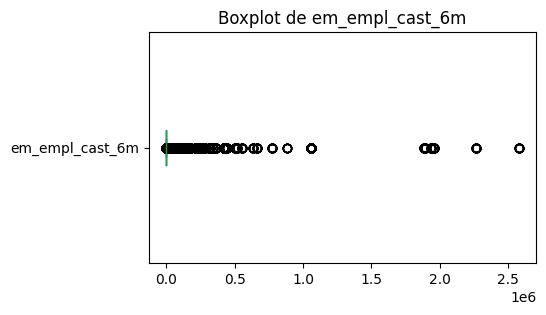

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.336451510789093 %

 Análisis de la columna: tasa_creds_3m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  3.003003003003003
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1299187


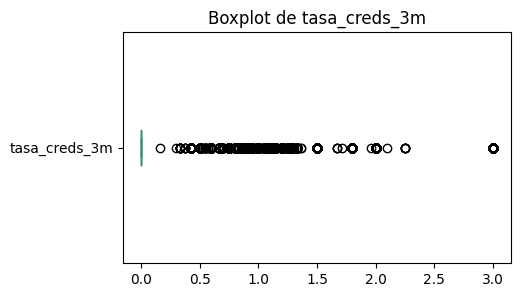

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.68110865144541 %

 Análisis de la columna: tasa_disp_3m
Cuartil 1=  0.8853838125852953
Cuartil 3=  1.1282793127053146
Rango intercuartilico=  0.24289550012001926
Mediana =  1.0
Valor minimo =  0.0
Valor maximo =  2.996455159572716
El bigote superior de la gráfica de cajas es  1.4926225628853436
El bigote inferior de la gráfica de cajas es  0.5210405624052664
los datos atípicos en esta columna son: 749189


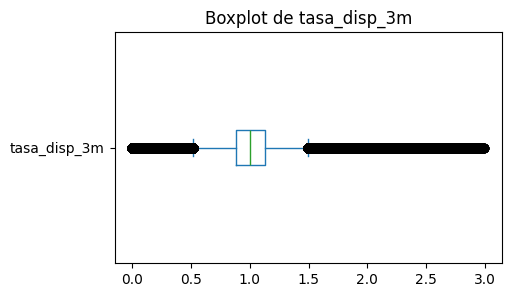

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 10.195985727587896 %

 Análisis de la columna: tasa_cap_3m
Cuartil 1=  0.6106758504604092
Cuartil 3=  1.3207004706928478
Rango intercuartilico=  0.7100246202324386
Mediana =  1.0
Valor minimo =  0.0
Valor maximo =  3.3333333333333335
El bigote superior de la gráfica de cajas es  2.3857374010415056
El bigote inferior de la gráfica de cajas es  -0.4543610798882488
los datos atípicos en esta columna son: 248205


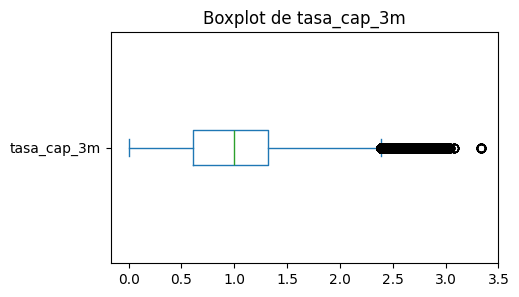

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 3.377912165709792 %

 Análisis de la columna: tasa_rot_3m
Cuartil 1=  0.917910447761194
Cuartil 3=  1.0502793296089385
Rango intercuartilico=  0.13236888184774454
Mediana =  0.9957805907172996
Valor minimo =  0.0
Valor maximo =  3.1666666666666665
El bigote superior de la gráfica de cajas es  1.2488326523805553
El bigote inferior de la gráfica de cajas es  0.7193571249895772
los datos atípicos en esta columna son: 1015574


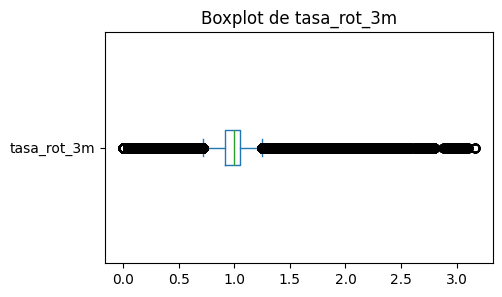

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.821316128919872 %

 Análisis de la columna: tasa_em_empl_3m
Cuartil 1=  0.9918521441817743
Cuartil 3=  1.0122686966028263
Rango intercuartilico=  0.020416552421052003
Mediana =  1.0
Valor minimo =  0.0
Valor maximo =  2.9611650485436893
El bigote superior de la gráfica de cajas es  1.0428935252344043
El bigote inferior de la gráfica de cajas es  0.9612273155501962
los datos atípicos en esta columna son: 1349248


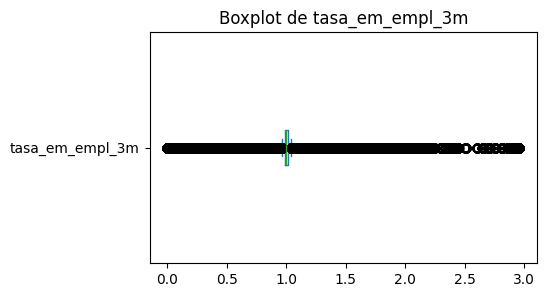

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 18.362407017423525 %

 Análisis de la columna: tasa_em_disp_3m
Cuartil 1=  0.9269266486629473
Cuartil 3=  1.0758923910548124
Rango intercuartilico=  0.1489657423918651
Mediana =  0.9958636107870668
Valor minimo =  0.0
Valor maximo =  2.9867277711103086
El bigote superior de la gráfica de cajas es  1.29934100464261
El bigote inferior de la gráfica de cajas es  0.7034780350751496
los datos atípicos en esta columna son: 668499


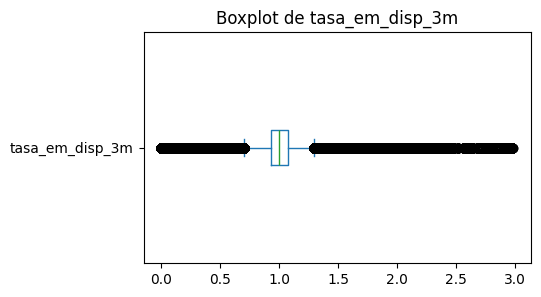

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 9.097846154851153 %

 Análisis de la columna: tasa_penetracion_3m
Cuartil 1=  0.655982905982906
Cuartil 3=  0.864
Rango intercuartilico=  0.208017094017094
Mediana =  0.7341772151898734
Valor minimo =  0.0
Valor maximo =  2.857142857142857
El bigote superior de la gráfica de cajas es  1.176025641025641
El bigote inferior de la gráfica de cajas es  0.343957264957265
los datos atípicos en esta columna son: 1019614


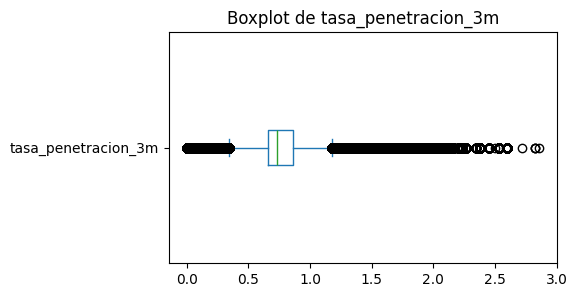

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.876297959058133 %

 Análisis de la columna: tasa_em_disp_prom_3m
Cuartil 1=  0.9304009545289696
Cuartil 3=  1.062969162720415
Rango intercuartilico=  0.13256820819144532
Mediana =  0.9949637218422706
Valor minimo =  0.0
Valor maximo =  2.976555727263846
El bigote superior de la gráfica de cajas es  1.261821475007583
El bigote inferior de la gráfica de cajas es  0.7315486422418016
los datos atípicos en esta columna son: 716680


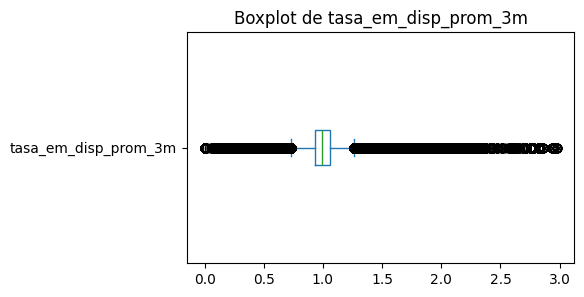

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 9.75355891670552 %

 Análisis de la columna: tasa_em_creds_3m
Cuartil 1=  0.9323693715039948
Cuartil 3=  1.0527781646010306
Rango intercuartilico=  0.12040879309703578
Mediana =  1.001392434439545
Valor minimo =  0.0
Valor maximo =  2.7858137790635378
El bigote superior de la gráfica de cajas es  1.2333913542465842
El bigote inferior de la gráfica de cajas es  0.7517561818584411
los datos atípicos en esta columna son: 1305062


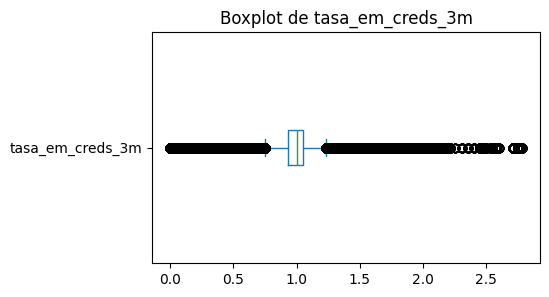

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.761063664332116 %

 Análisis de la columna: tasa_em_sdo_creds_3m
Cuartil 1=  0.975709007111856
Cuartil 3=  1.0305982703435714
Rango intercuartilico=  0.05488926323171539
Mediana =  1.0053503874118617
Valor minimo =  0.0
Valor maximo =  2.9955398735609915
El bigote superior de la gráfica de cajas es  1.1129321651911446
El bigote inferior de la gráfica de cajas es  0.893375112264283
los datos atípicos en esta columna son: 1832242


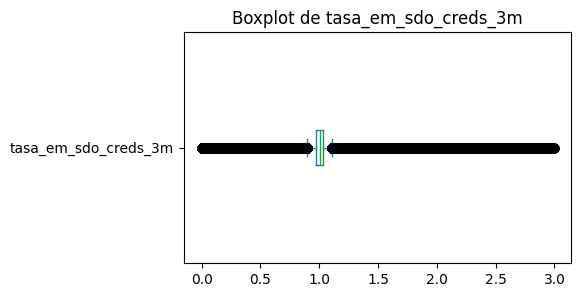

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 24.935648122819607 %

 Análisis de la columna: tasa_vencido_em_3m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  2.9208970677647677
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1408355


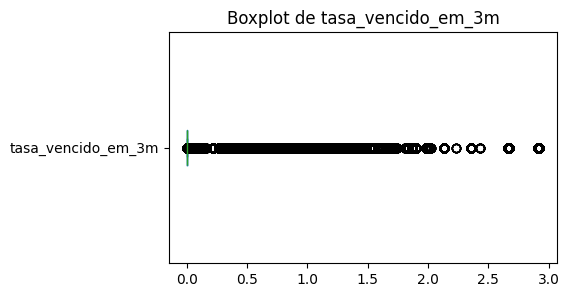

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 19.166815689201325 %

 Análisis de la columna: tasa_cast_em_3m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  -0.009889270714012983
Valor maximo =  2.9568822797842924
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 332835


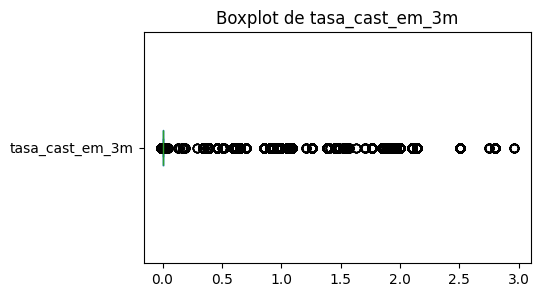

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.529672632195237 %

 Análisis de la columna: tasa_disper_vs_inicial
Cuartil 1=  0.9703386712014107
Cuartil 3=  1.6873959474618503
Rango intercuartilico=  0.7170572762604396
Mediana =  1.2282307949232834
Valor minimo =  0.0
Valor maximo =  7777.777733333332
El bigote superior de la gráfica de cajas es  2.7629818618525097
El bigote inferior de la gráfica de cajas es  -0.10524724318924872
los datos atípicos en esta columna son: 571446


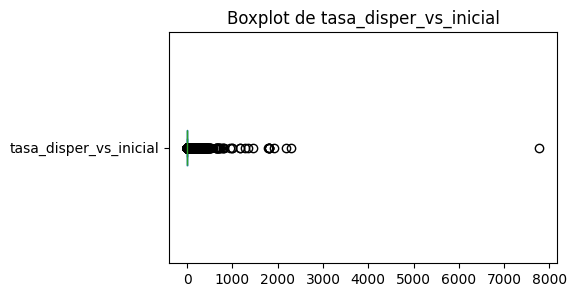

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 7.77701656069055 %

 Análisis de la columna: cap3m_disp3m
Cuartil 1=  0.03784199778803265
Cuartil 3=  0.2730721685676104
Rango intercuartilico=  0.23523017077957775
Mediana =  0.10341612012301137
Valor minimo =  0.0
Valor maximo =  9109.932713333332
El bigote superior de la gráfica de cajas es  0.625917424736977
El bigote inferior de la gráfica de cajas es  -0.315003258381334
los datos atípicos en esta columna son: 959836


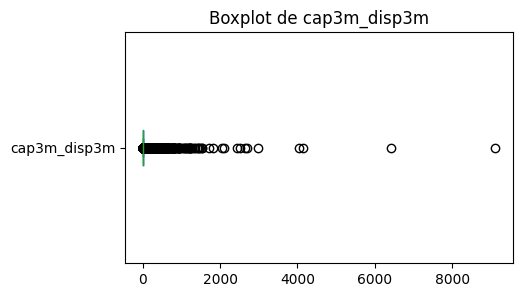

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.062757404106382 %

 Análisis de la columna: cap6m_disp6m
Cuartil 1=  0.04301482865428648
Cuartil 3=  0.28318869668428626
Rango intercuartilico=  0.2401738680299998
Mediana =  0.11026024084170166
Valor minimo =  0.0
Valor maximo =  5510.079253333333
El bigote superior de la gráfica de cajas es  0.6434494987292859
El bigote inferior de la gráfica de cajas es  -0.3172459733907132
los datos atípicos en esta columna son: 937112


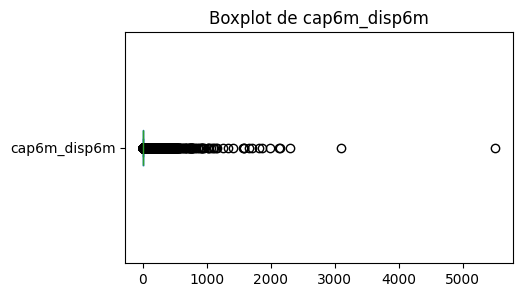

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 12.753498218942546 %

 Análisis de la columna: catp_disper
Cuartil 1=  0.02893977864843341
Cuartil 3=  0.26332385494919774
Rango intercuartilico=  0.23438407630076433
Mediana =  0.09409183214758207
Valor minimo =  0.0
Valor maximo =  7458647.999999999
El bigote superior de la gráfica de cajas es  0.6148999694003443
El bigote inferior de la gráfica de cajas es  -0.3226363358027131
los datos atípicos en esta columna son: 1006383


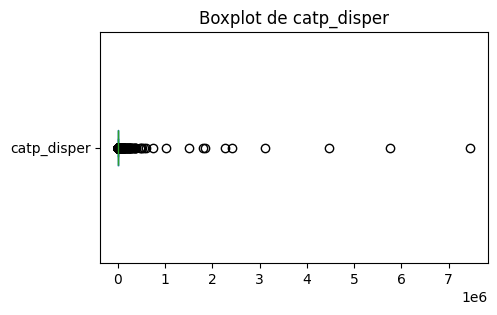

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 13.696232465355324 %

 Análisis de la columna: disp6m_dispinicial
Cuartil 1=  1.0
Cuartil 3=  1.667695735031197
Rango intercuartilico=  0.667695735031197
Mediana =  1.2364181383763262
Valor minimo =  0.0
Valor maximo =  2998.8595466666666
El bigote superior de la gráfica de cajas es  2.6692393375779924
El bigote inferior de la gráfica de cajas es  -0.0015436025467954195
los datos atípicos en esta columna son: 455213


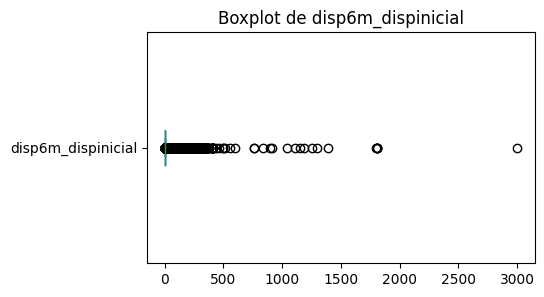

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.195159367012154 %

 Análisis de la columna: disp3m_dispinicial
Cuartil 1=  1.0
Cuartil 3=  1.7037430820101012
Rango intercuartilico=  0.7037430820101012
Mediana =  1.2530883302379283
Valor minimo =  0.0
Valor maximo =  3799.609913333333
El bigote superior de la gráfica de cajas es  2.759357705025253
El bigote inferior de la gráfica de cajas es  -0.05561462301515174
los datos atípicos en esta columna son: 481954


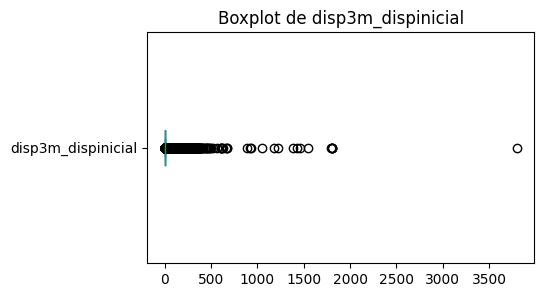

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.559087366944652 %

 Análisis de la columna: tasa_creds_6m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  6.006006006006006
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1306253


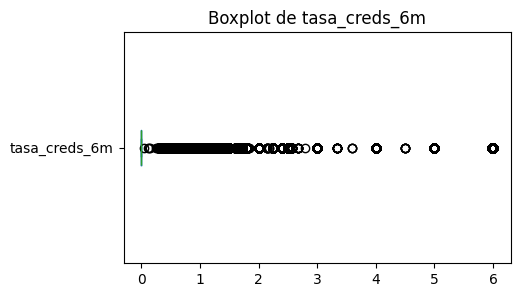

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 17.777272416731787 %

 Análisis de la columna: tasa_disp_6m
Cuartil 1=  0.8526589437569525
Cuartil 3=  1.144560764435106
Rango intercuartilico=  0.2919018206781534
Mediana =  0.9975096118290134
Valor minimo =  0.0
Valor maximo =  5.963342217248481
El bigote superior de la gráfica de cajas es  1.582413495452336
El bigote inferior de la gráfica de cajas es  0.4148062127397224
los datos atípicos en esta columna son: 636446


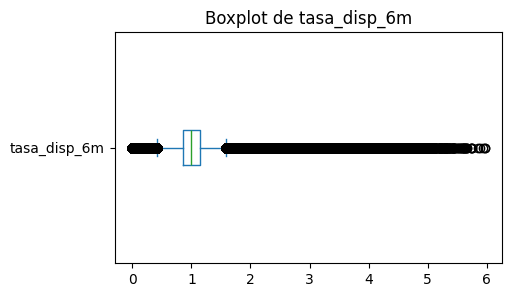

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 8.661625213905177 %

 Análisis de la columna: tasa_cap_6m
Cuartil 1=  0.4861844904233961
Cuartil 3=  1.3599532736607995
Rango intercuartilico=  0.8737687832374035
Mediana =  0.9386346255145532
Valor minimo =  0.0
Valor maximo =  6.666666666666667
El bigote superior de la gráfica de cajas es  2.6706064485169048
El bigote inferior de la gráfica de cajas es  -0.8244686844327092
los datos atípicos en esta columna son: 364938


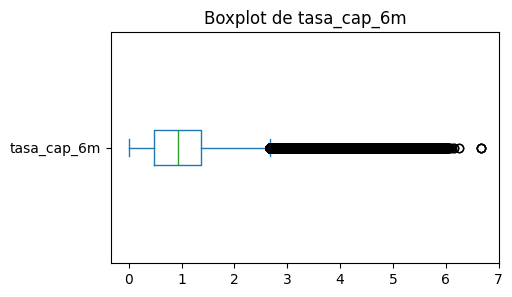

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.966574041335993 %

 Análisis de la columna: tasa_rot_6m
Cuartil 1=  0.8494117647058823
Cuartil 3=  1.0845070422535212
Rango intercuartilico=  0.23509527754763893
Mediana =  0.9803921568627452
Valor minimo =  0.0
Valor maximo =  6.4
El bigote superior de la gráfica de cajas es  1.4371499585749796
El bigote inferior de la gráfica de cajas es  0.4967688483844239
los datos atípicos en esta columna son: 925521


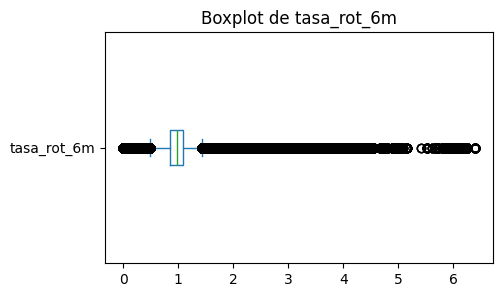

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 12.595752082028536 %

 Análisis de la columna: tasa_em_empl_6m
Cuartil 1=  0.9868550901985553
Cuartil 3=  1.0285048221197415
Rango intercuartilico=  0.04164973192118615
Mediana =  1.0029367581390853
Valor minimo =  0.0
Valor maximo =  5.5964912280701755
El bigote superior de la gráfica de cajas es  1.0909794200015206
El bigote inferior de la gráfica de cajas es  0.9243804923167761
los datos atípicos en esta columna son: 1230657


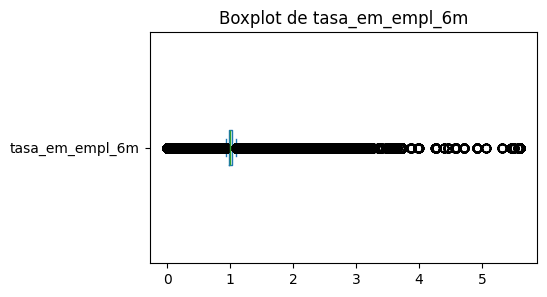

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 16.74845894367928 %

 Análisis de la columna: tasa_em_disp_6m
Cuartil 1=  0.9189496020038137
Cuartil 3=  1.1032145157150781
Rango intercuartilico=  0.1842649137112644
Mediana =  0.9946053857178917
Valor minimo =  0.0
Valor maximo =  5.282350904155321
El bigote superior de la gráfica de cajas es  1.3796118862819746
El bigote inferior de la gráfica de cajas es  0.6425522314369171
los datos atípicos en esta columna son: 623612


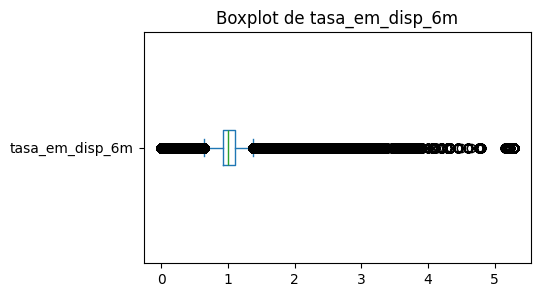

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 8.486962637668922 %

 Análisis de la columna: tasa_penetracion_6m
Cuartil 1=  0.655282817502668
Cuartil 3=  0.8776978417266187
Rango intercuartilico=  0.22241502422395065
Mediana =  0.7350877192982457
Valor minimo =  0.0
Valor maximo =  5.434782608695652
El bigote superior de la gráfica de cajas es  1.2113203780625446
El bigote inferior de la gráfica de cajas es  0.32166028116674206
los datos atípicos en esta columna son: 1134905


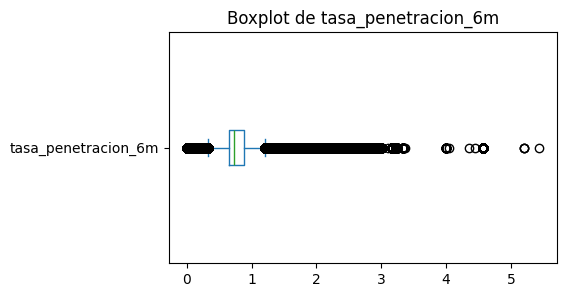

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 15.445335131946866 %

 Análisis de la columna: tasa_em_disp_prom_6m
Cuartil 1=  0.9221110955077865
Cuartil 3=  1.0772874210311958
Rango intercuartilico=  0.15517632552340932
Mediana =  0.9904835990999208
Valor minimo =  0.0
Valor maximo =  5.199136635850856
El bigote superior de la gráfica de cajas es  1.3100519093163099
El bigote inferior de la gráfica de cajas es  0.6893466072226725
los datos atípicos en esta columna son: 591789


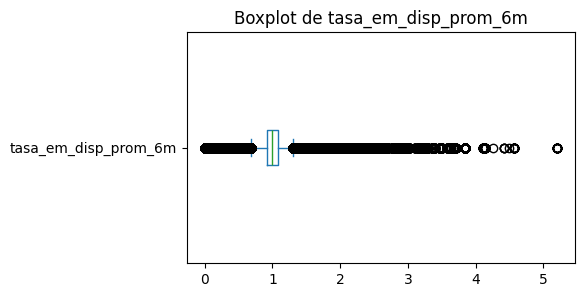

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 8.053871850418936 %

 Análisis de la columna: tasa_em_creds_6m
Cuartil 1=  0.9229349330872174
Cuartil 3=  1.088757982314144
Rango intercuartilico=  0.1658230492269266
Mediana =  1.0130216670938845
Valor minimo =  0.0
Valor maximo =  5.142990727031871
El bigote superior de la gráfica de cajas es  1.3374925561545339
El bigote inferior de la gráfica de cajas es  0.6742003592468275
los datos atípicos en esta columna son: 1377192


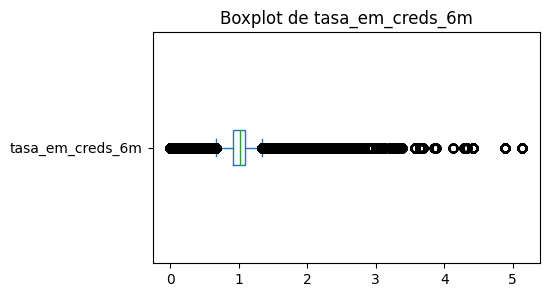

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 18.74270708212244 %

 Análisis de la columna: tasa_em_sdo_creds_6m
Cuartil 1=  0.9594394299773159
Cuartil 3=  1.0815354519248594
Rango intercuartilico=  0.12209602194754354
Mediana =  1.0176834342966044
Valor minimo =  0.0
Valor maximo =  5.9250868286373075
El bigote superior de la gráfica de cajas es  1.2646794848461749
El bigote inferior de la gráfica de cajas es  0.7762953970560006
los datos atípicos en esta columna son: 1780255


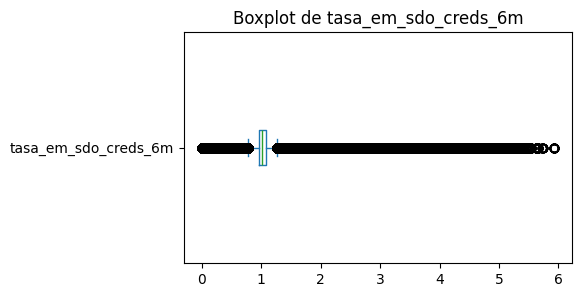

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 24.228138121978553 %

 Análisis de la columna: tasa_vencido_em_6m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  0.0
Valor maximo =  3.663369345035543
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 1408355


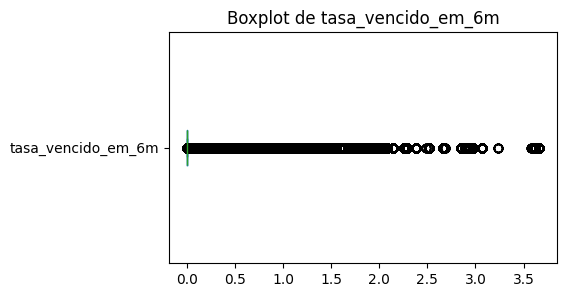

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 19.166815689201325 %

 Análisis de la columna: tasa_cast_em_6m
Cuartil 1=  0.0
Cuartil 3=  0.0
Rango intercuartilico=  0.0
Mediana =  0.0
Valor minimo =  -0.13015345854328905
Valor maximo =  4.694465435091388
El bigote superior de la gráfica de cajas es  0.0
El bigote inferior de la gráfica de cajas es  0.0
los datos atípicos en esta columna son: 332835


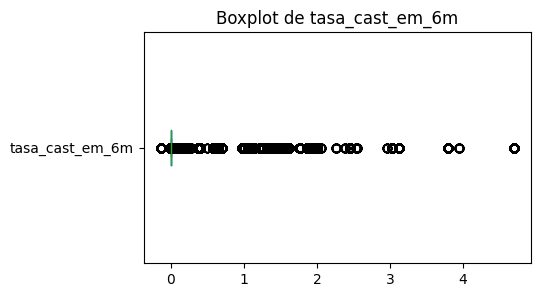

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 4.529672632195237 %

 Análisis de la columna: disper_edad_ingreso
Cuartil 1=  169.19260482180292
Cuartil 3=  445.28630050505046
Rango intercuartilico=  276.0936956832476
Mediana =  276.8954444444445
Valor minimo =  0.00013157894736842105
Valor maximo =  2951972.053888889
El bigote superior de la gráfica de cajas es  859.4268440299218
El bigote inferior de la gráfica de cajas es  -244.94793870306844
los datos atípicos en esta columna son: 460003


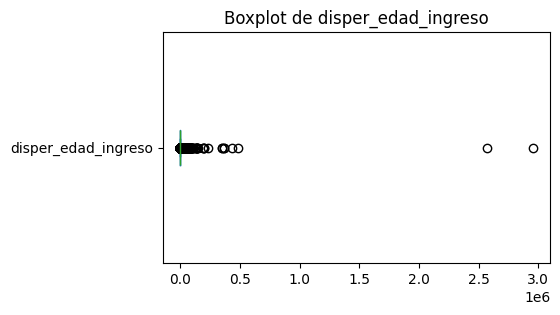

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.2603482200721245 %

 Análisis de la columna: disper_edad_mes
Cuartil 1=  156.04166666666666
Cuartil 3=  402.94813034188036
Rango intercuartilico=  246.9064636752137
Mediana =  252.823
Valor minimo =  0.00012987012987012987
Valor maximo =  2796605.1036842107
El bigote superior de la gráfica de cajas es  773.3078258547009
El bigote inferior de la gráfica de cajas es  -214.3180288461539
los datos atípicos en esta columna son: 455652


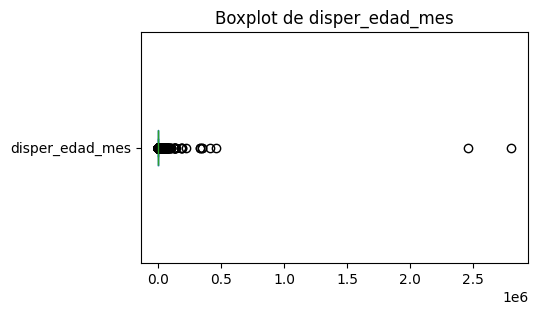

El porcentaje total de outliers (valores atípicos) en la columna {col_num} es: 6.201133877762326 %


In [27]:

#Calculando los datos
for col_num in numericas:
  print(f"\n Análisis de la columna: {col_num}")
  Q1p = datos_df[col_num].quantile(0.25)
  print("Cuartil 1= ", Q1p)
  Q3p = datos_df[col_num].quantile(0.75)
  print("Cuartil 3= ", Q3p)
  IQp = Q3p-Q1p
  print("Rango intercuartilico= ", IQp)
  Medianap = datos_df[col_num].median()
  print("Mediana = ", Medianap)
  Minp = datos_df[col_num].min()
  print("Valor minimo = ", Minp)
  Maxp = datos_df[col_num].max()
  print("Valor maximo = ", Maxp)

  #Calculando bigote superior e ingerior
  lsp = (Q3p + 1.5*IQp)
  print("El bigote superior de la gráfica de cajas es ", lsp)
  lip = (Q1p - 1.5*IQp)
  print("El bigote inferior de la gráfica de cajas es ", lip)

  #Ubicando los outliers en cada columna numérica
  ubicacionp = (datos_df[col_num] <lip) | (datos_df[col_num]>lsp)

  #Obteniendo los outliers (datos atípicos) de price
  outliersp = datos_df[col_num][ubicacionp]

  #Contando los outliers
  print("los datos atípicos en esta columna son:", outliersp.count())

  plt.figure(figsize=(5, 3))
  datos_df[col_num].plot(kind="box", vert=False)
  plt.title(f"Boxplot de {col_num}")
  plt.show()

  #Calculando % de valores atípicos
  num_registrosa = datos_df[col_num].count().sum()
  num_registrosa
  porc_outl_a= outliersp.count()/num_registrosa
  print("El porcentaje total de outliers (valores atípicos) en la columna {col_num} es:",(porc_outl_a)*100,"%")

  #SE PUEDEN RELLENAR O ELIMINAR ESTOS VALORES ATÍPICOS, SERÁ DECISIÓN DE VER QUÉ PODEMOS HACER CON ESTOS DATOS


In [28]:

# Outliers

# Usando el método IQR (Interquartile Range)
Q1 = datos_df[numericas].quantile(0.25)

Q3 = datos_df[numericas].quantile(0.75)
IQR = Q3 - Q1

# Filtrar posibles outliers
outliers = ((datos_df[numericas] < (Q1 - 1.5 * IQR)) | (datos_df[numericas] > (Q3 + 1.5 * IQR))).sum()

# Calcular el porcentaje de outliers por variable
total_filas = datos_df.shape[0]
porcentaje_outliers = (outliers / total_filas) * 100


# Ordenar los porcentajes de mayor a menor
porcentaje_outliers_ordenado = porcentaje_outliers.sort_values(ascending=False)

# Configurar Pandas para mostrar todas las filas
pd.set_option('display.max_rows', None)  # Muestra todas las filas

# Mostrar resultados ordenados
print("\nPorcentaje de posibles outliers por variable (ordenado de mayor a menor):")
print(porcentaje_outliers_ordenado)



Porcentaje de posibles outliers por variable (ordenado de mayor a menor):
tasa_em_sdo_creds_3m        24.94
tasa_em_sdo_creds_6m        24.23
em_empl_ven_prom_3m         23.69
em_vencido_emp              19.17
tasa_vencido_em_6m          19.17
tasa_vencido_em_3m          19.17
tasa_em_creds_6m            18.74
tasa_em_empl_3m             18.36
cte_creds_prom_6ant         18.31
cte_creds_prom_3ant         17.89
creditos                    17.78
tasa_creds_6m               17.78
f_con_credito               17.78
tasa_em_creds_3m            17.76
tasa_creds_3m               17.68
em_empl_cast_6m             17.34
tasa_em_empl_6m             16.75
tasa_penetracion_6m         15.45
em_empl_ven_prom_6m         14.86
sdo_prom_capt               14.44
sdo_cap_prom_3ant           13.93
tasa_penetracion_3m         13.88
tasa_rot_3m                 13.82
catp_disper                 13.70
sdo_cap_prom_6ant           13.66
cap3m_disp3m                13.06
cap6m_disp6m                12.75
em_empl

In [ ]:

# Suponiendo que 'numericas' es una lista con los nombres de las variables numéricas
# Crear un número de filas y columnas dinámicas para acomodar los histogramas
n = len(numericas)
ncols = 3  # Número de columnas en la gráfica
nrows = (n // ncols) + (n % ncols > 0)  # Número de filas, asegurando que todos los gráficos caben

# Crear una figura con subgráficas ajustadas
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 10))
axes = axes.flatten()  # Aplanar para facilitar el acceso a cada subgráfico

# Crear histogramas solo para las variables numéricas
for i, var in enumerate(numericas):
    axes[i].hist(datos_df[var], bins=30, edgecolor='black')
    axes[i].set_title(var)  # Título para cada gráfico individual

# Eliminar los ejes de las subgráficas que no tengan datos
for i in range(n, len(axes)):
    fig.delaxes(axes[i])

# Título general para el gráfico
plt.suptitle("Distribución de Variables Numéricas")

# Ajustar espacio entre las subgráficas para evitar superposición
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajusta el rectángulo para dar espacio al suptítulo

# Mostrar los gráficos
plt.show()

In [ ]:

# Suponiendo que 'numericas' es una lista con los nombres de las variables numéricas
# Y 'target' es la variable que quieres comparar (0 o 1)

# Crear número de filas y columnas dinámicas para acomodar las gráficas
n = len(numericas)
ncols = 2  # Una columna para el histograma y otra para el boxplot
nrows = n  # Una fila por cada variable numérica

# Crear una figura con subgráficas ajustadas
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * n))

# Para cada variable numérica, generar los gráficos
for i, var in enumerate(numericas):
    # Histograma en la primera columna
    axes[i, 0].hist(datos_df[var], bins=30, edgecolor='black')
    axes[i, 0].set_title(f'Histograma de {var}')

    # Boxplot en la segunda columna comparando con el 'target'
    sns.boxplot(x='target', y=var, data=datos_df, ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {var} vs Target')

# Ajustar espacio entre las subgráficas para evitar superposición
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajusta el rectángulo para dar espacio al suptítulo

# Mostrar los gráficos
plt.show()

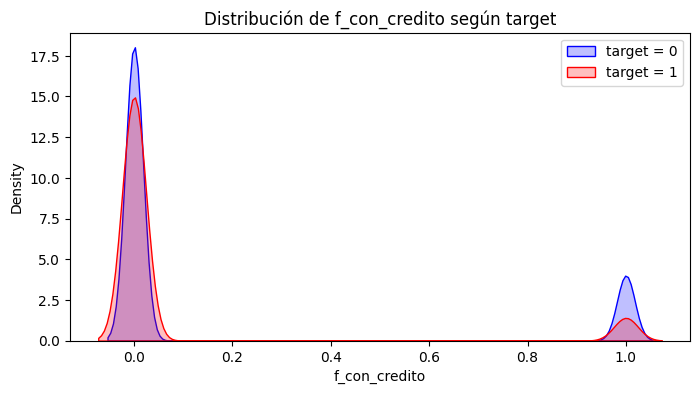

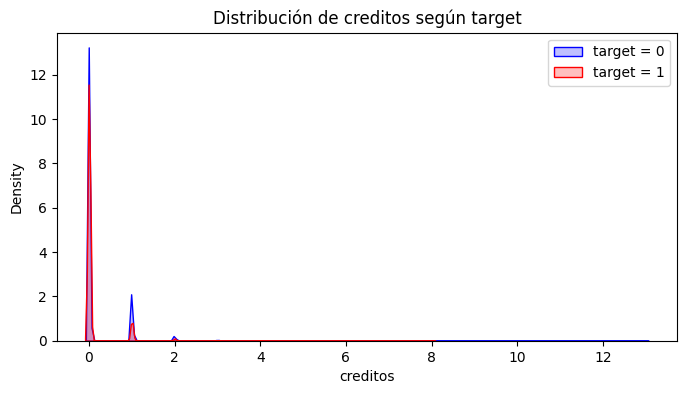

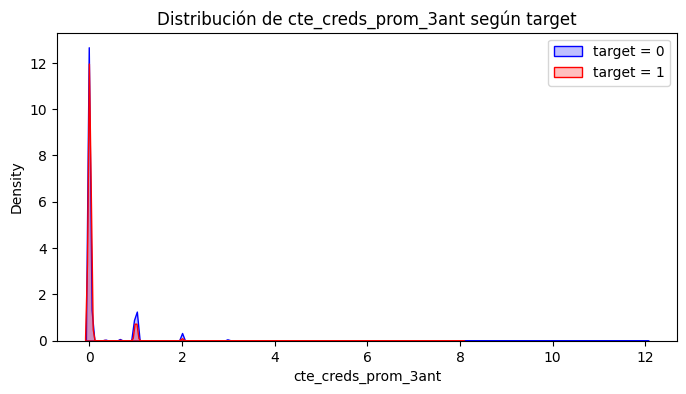

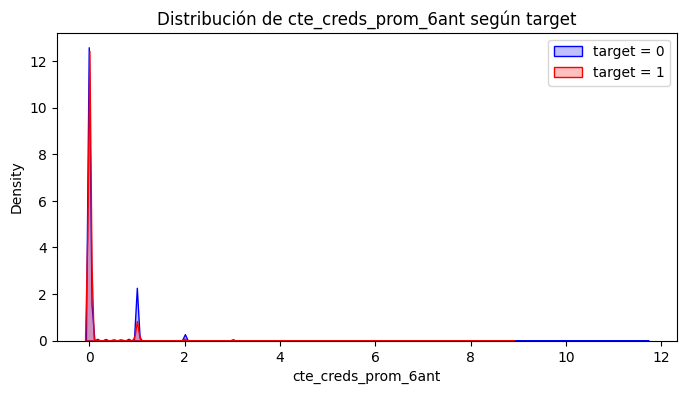

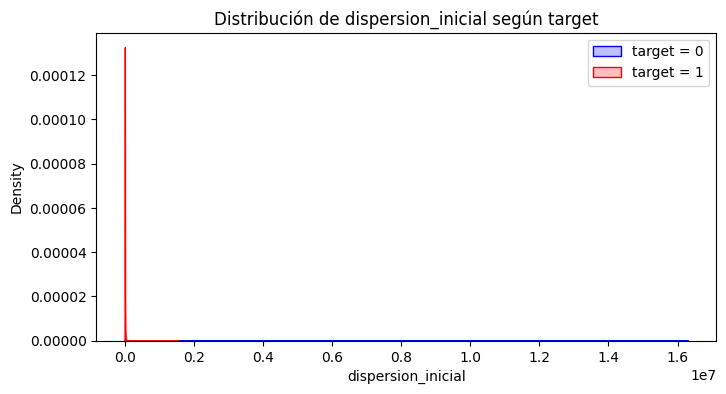

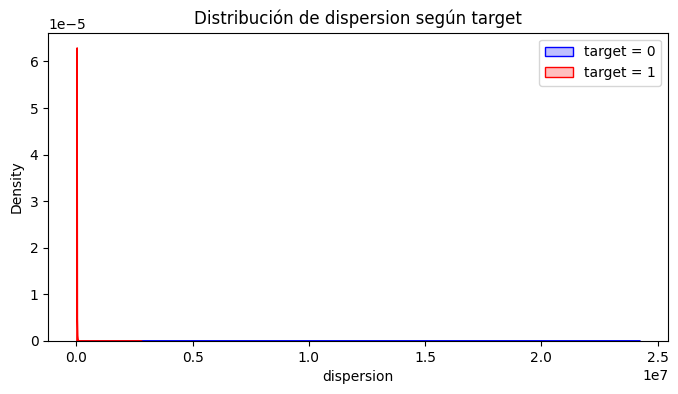

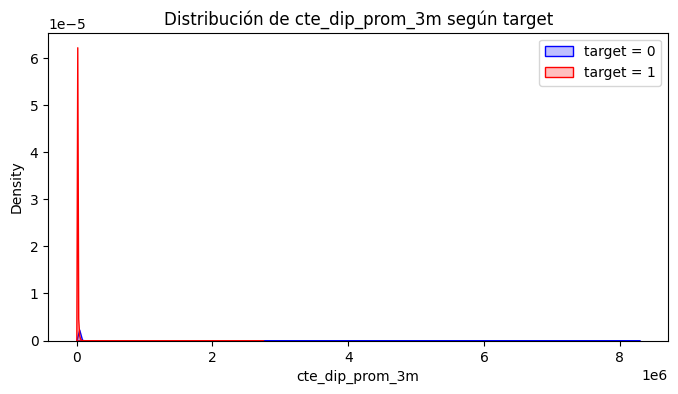

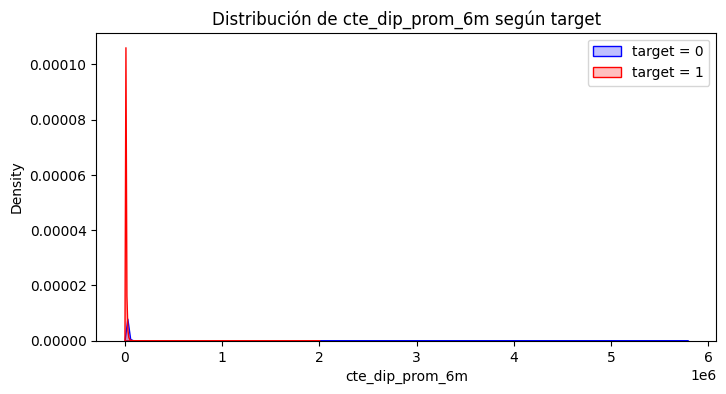

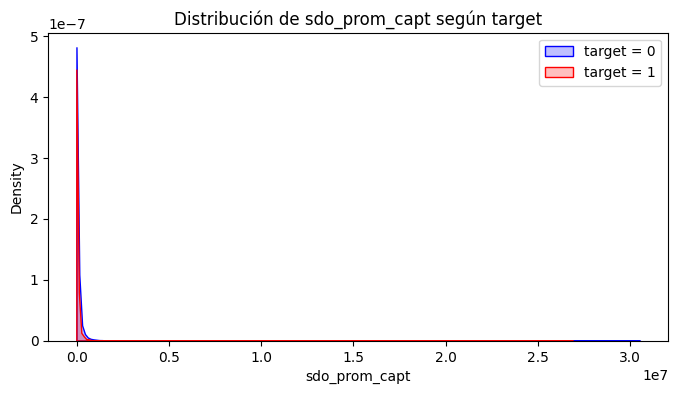

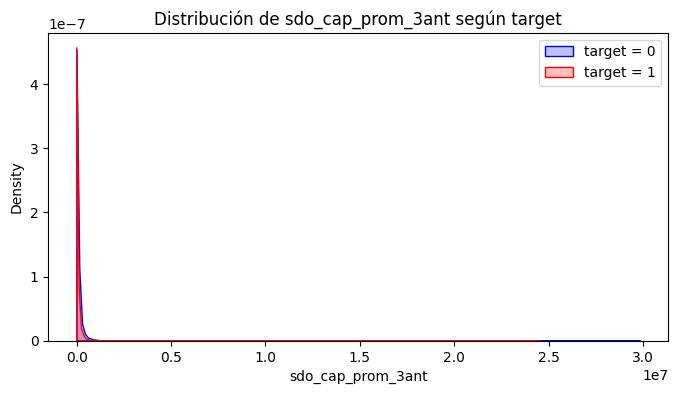

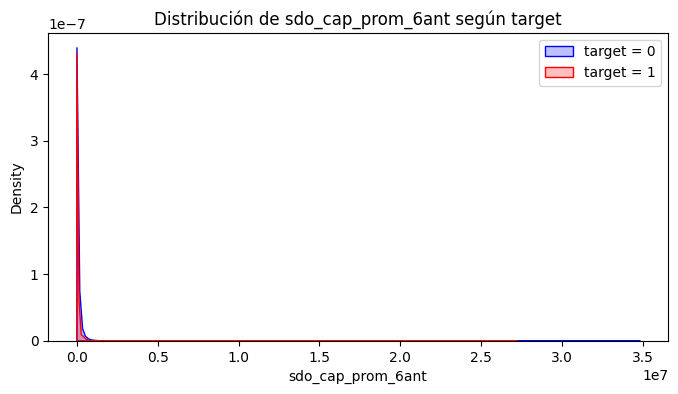

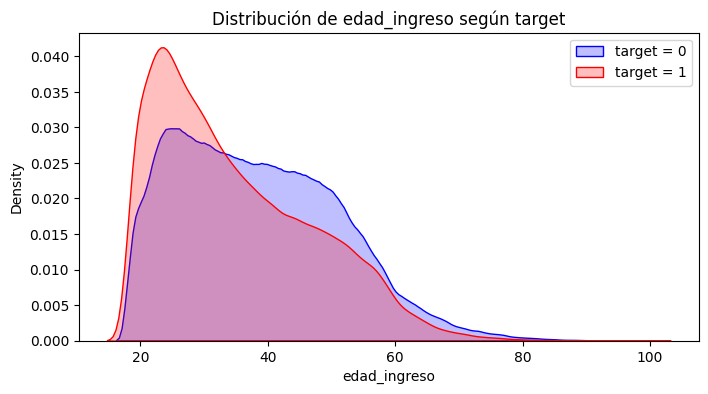

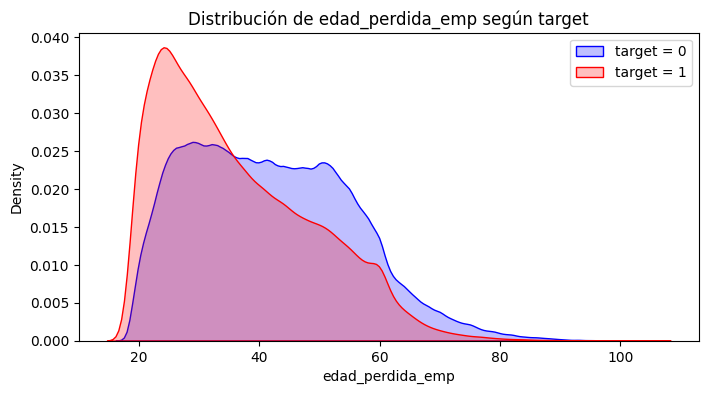

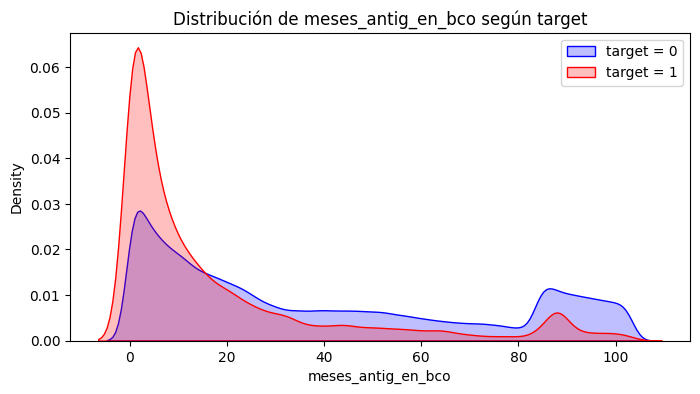

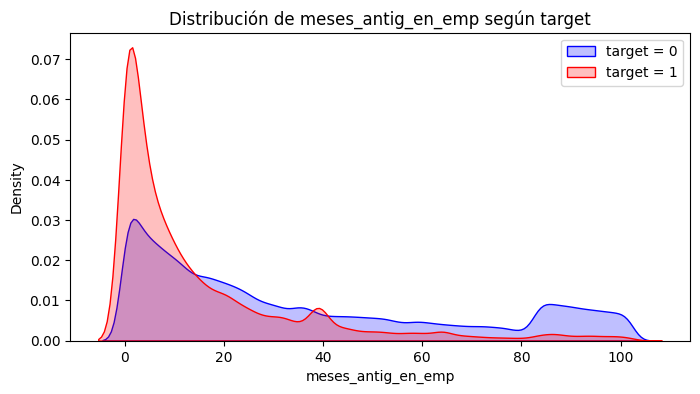

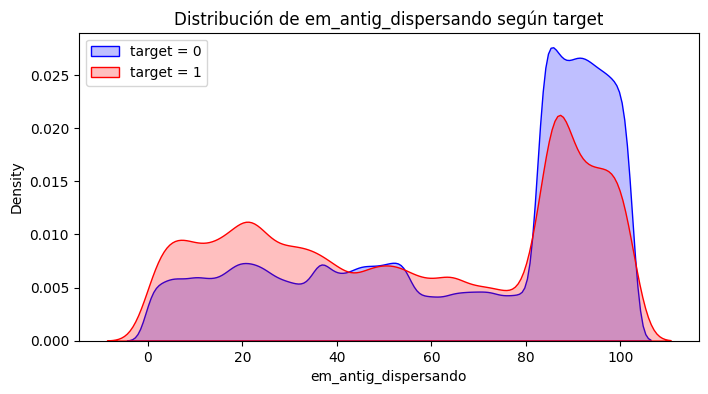

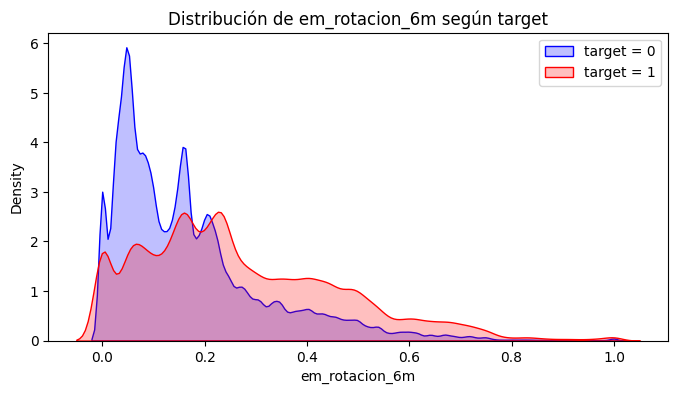

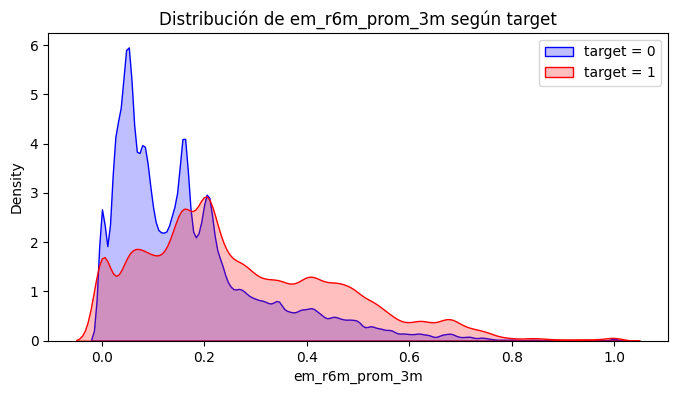

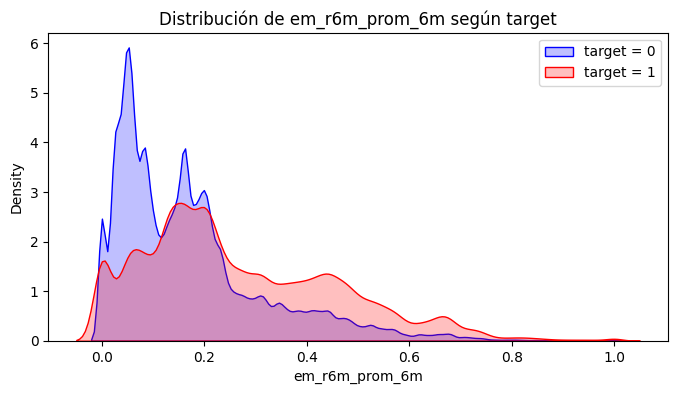

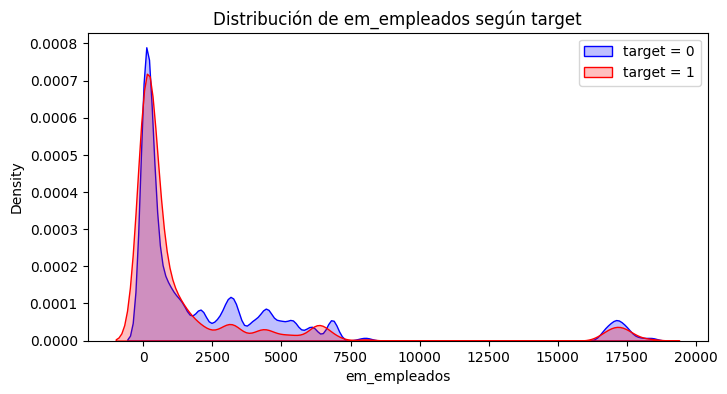

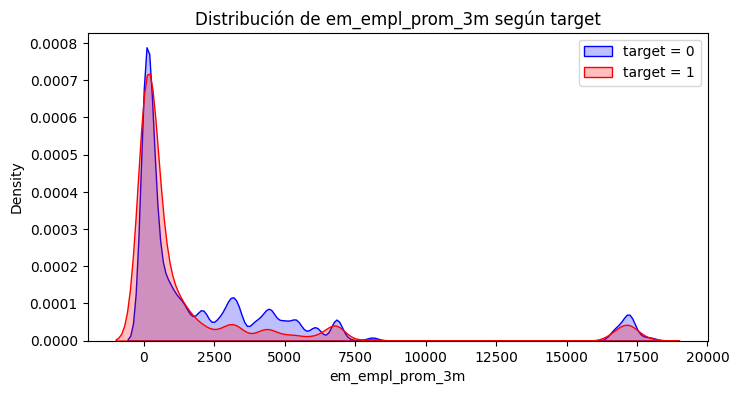

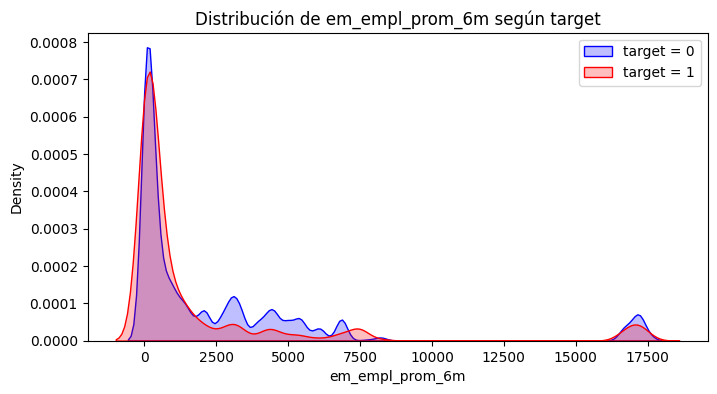

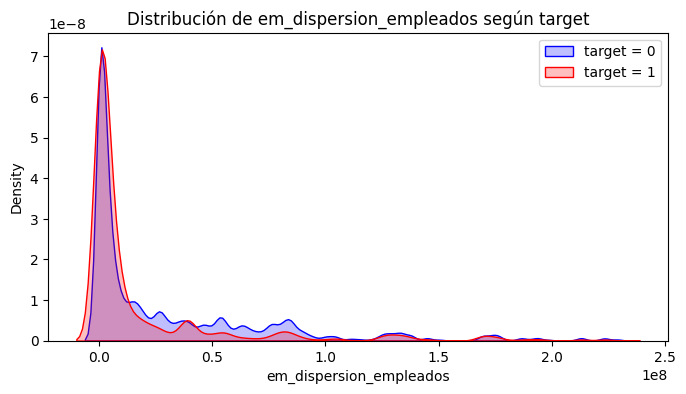

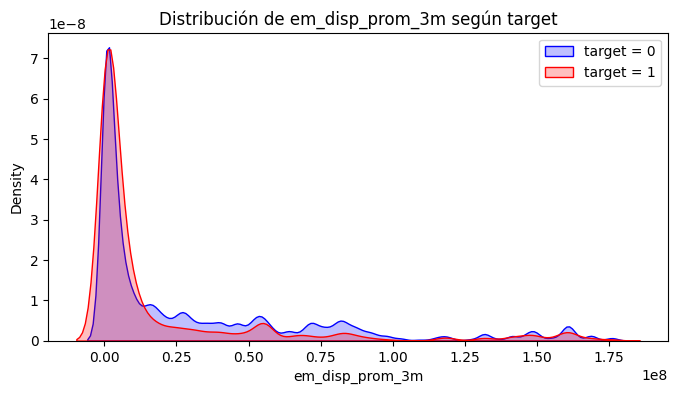

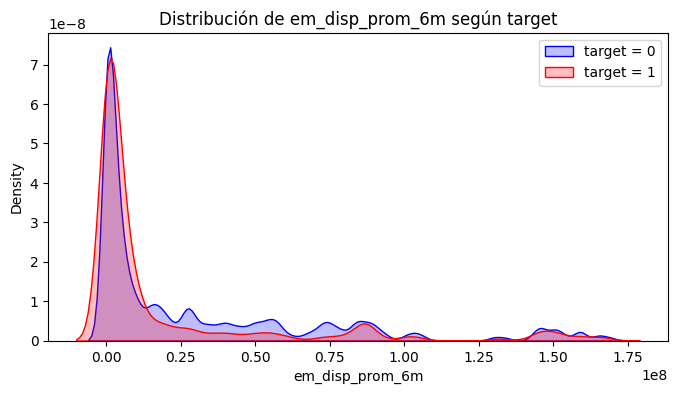

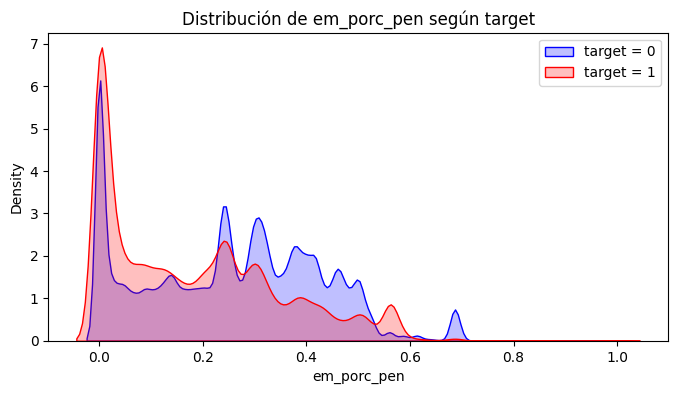

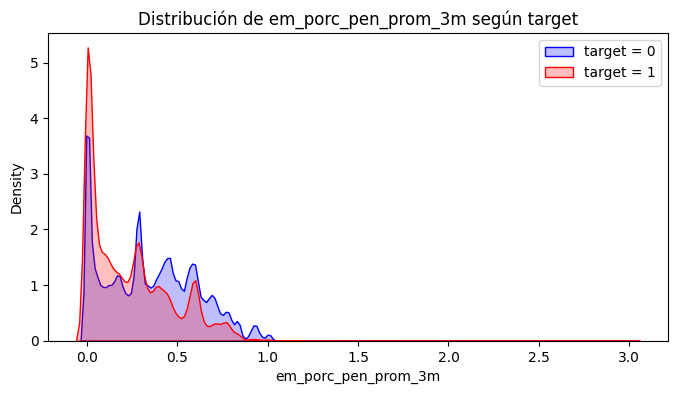

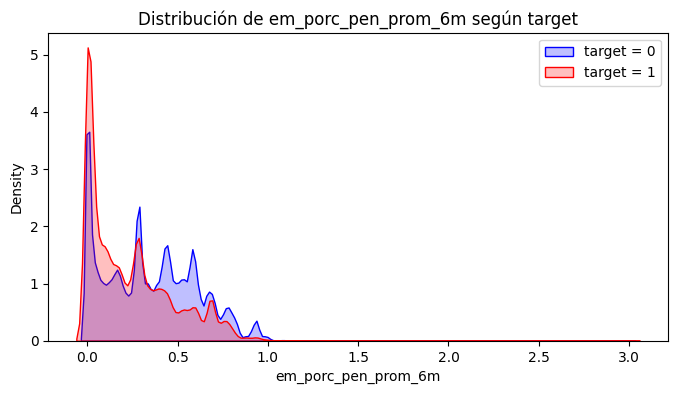

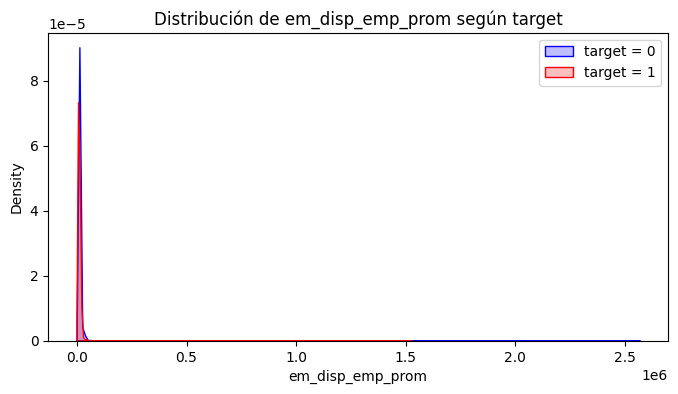

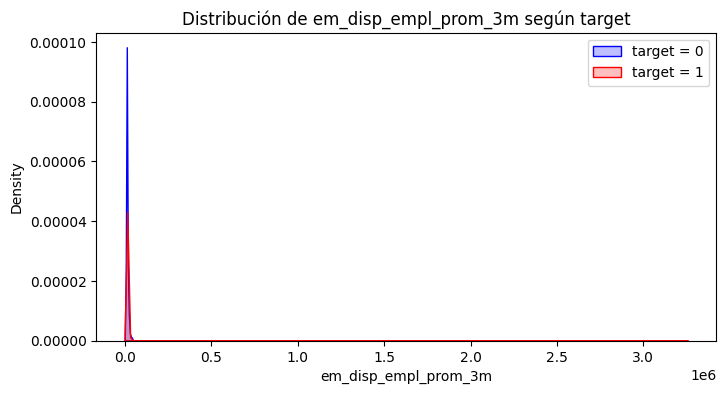

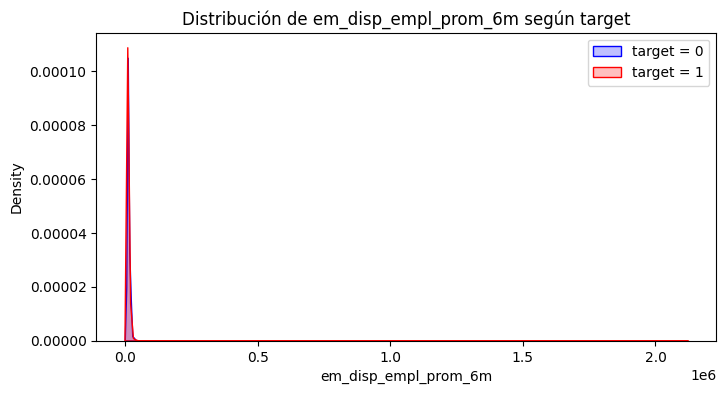

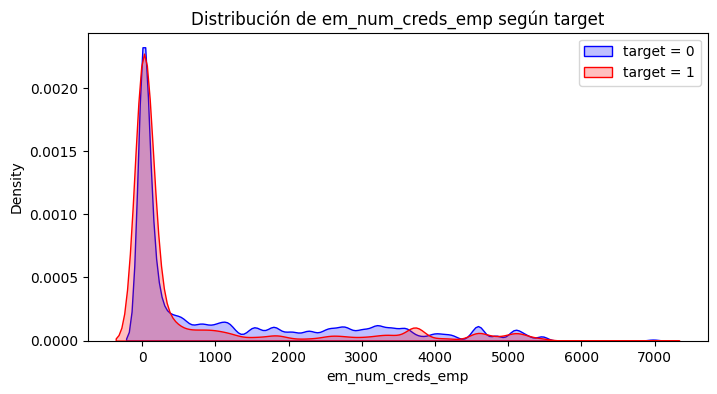

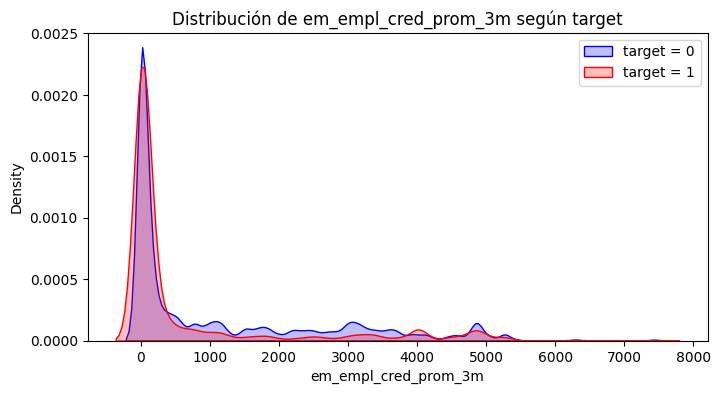

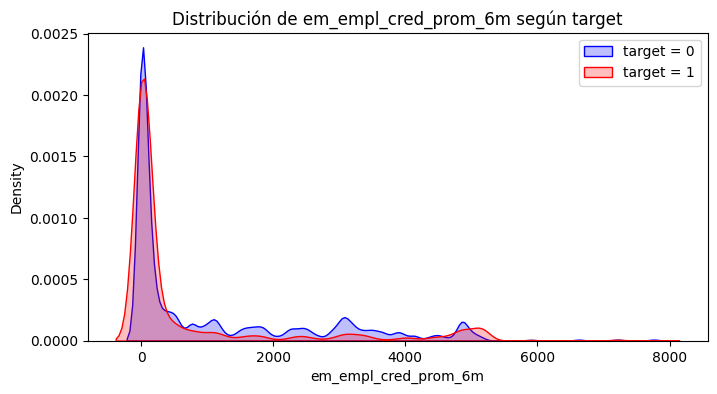

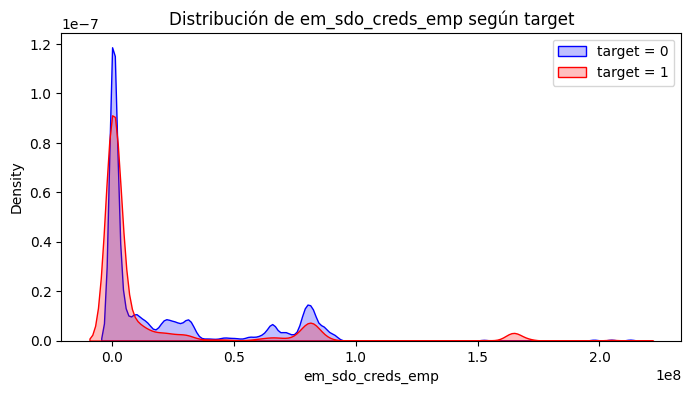

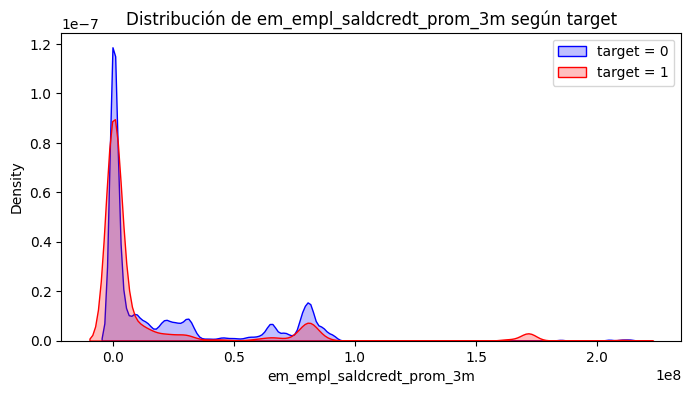

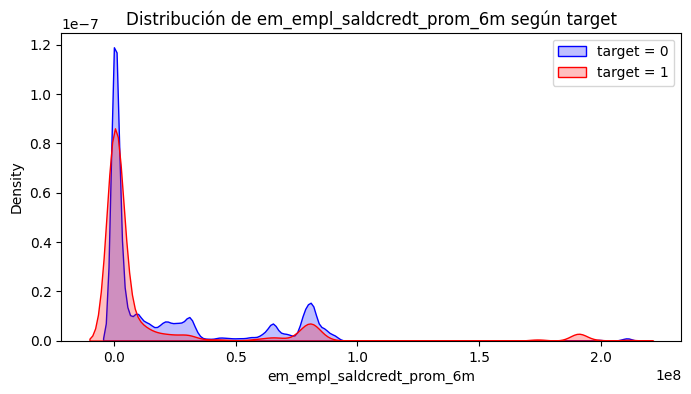

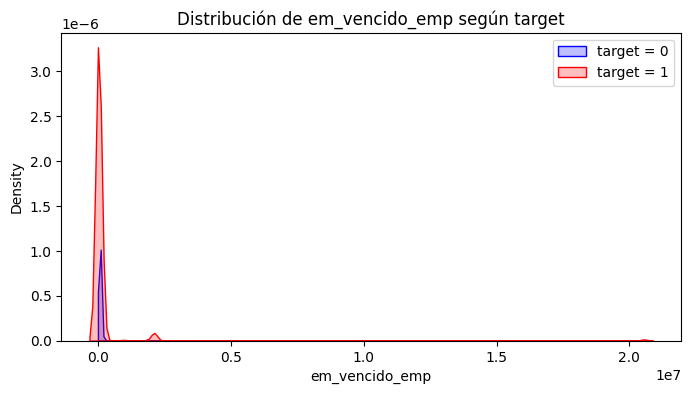

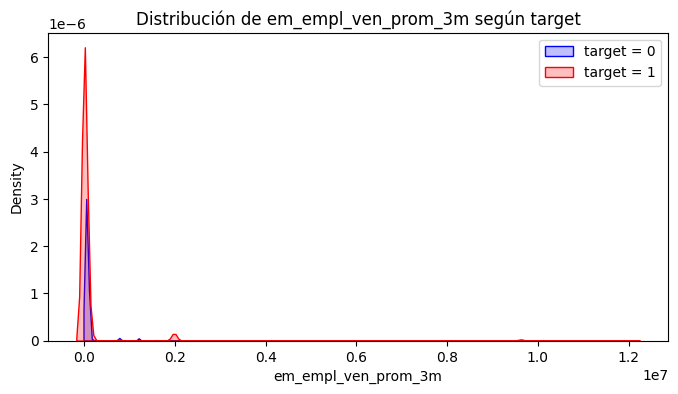

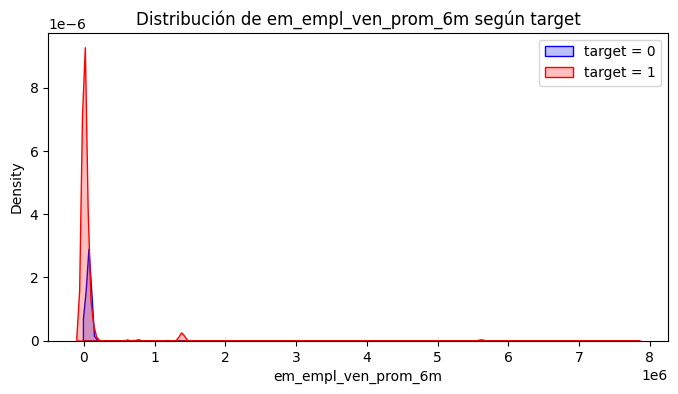

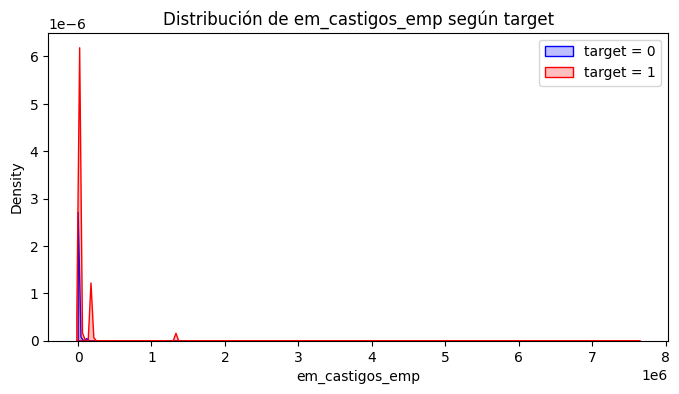

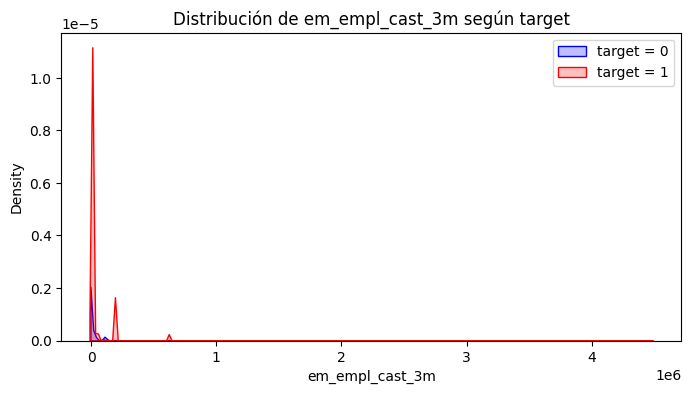

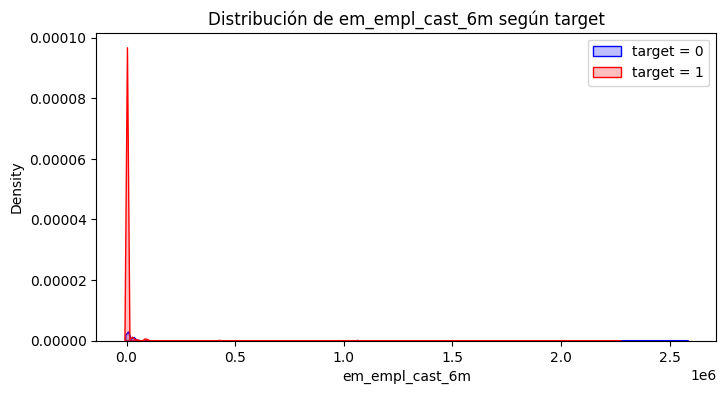

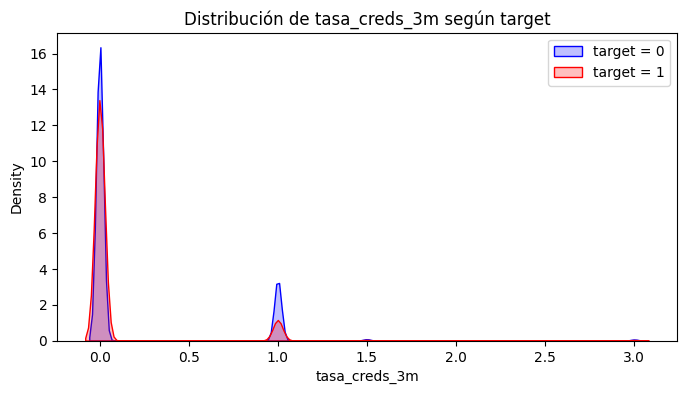

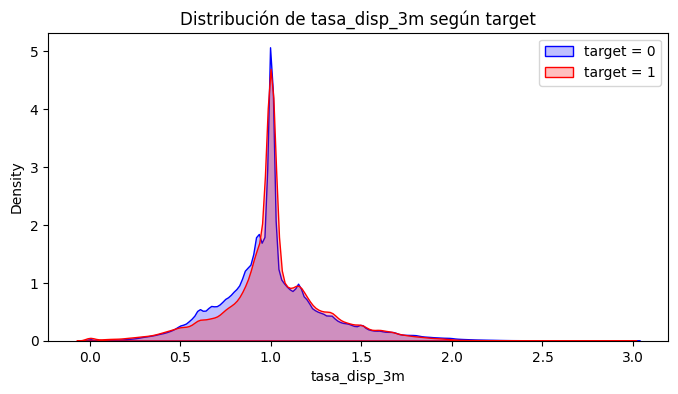

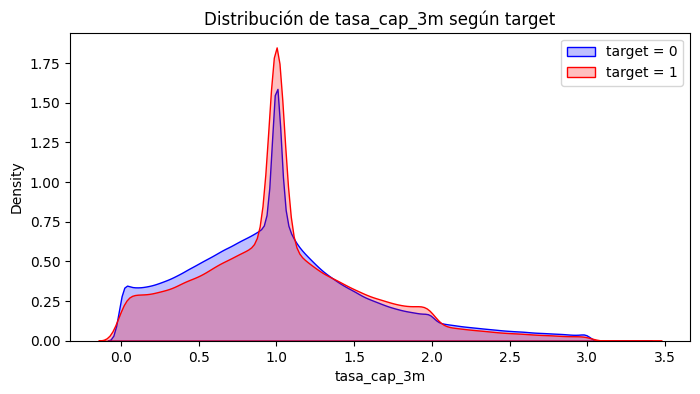

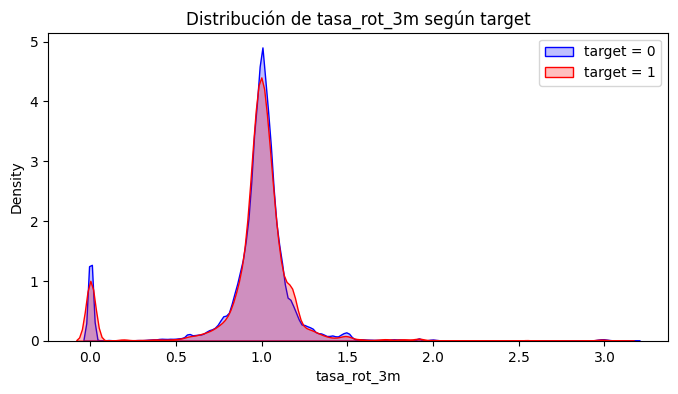

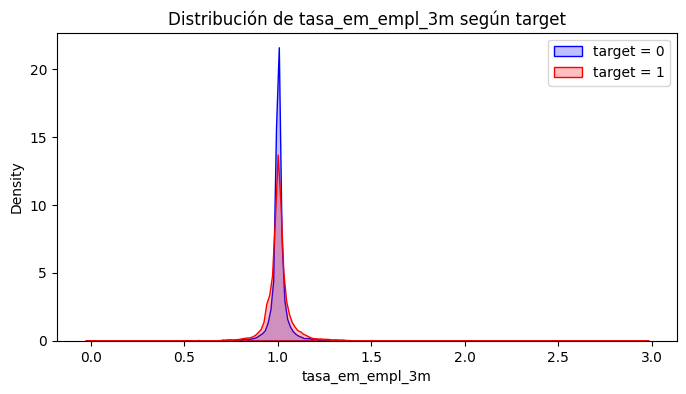

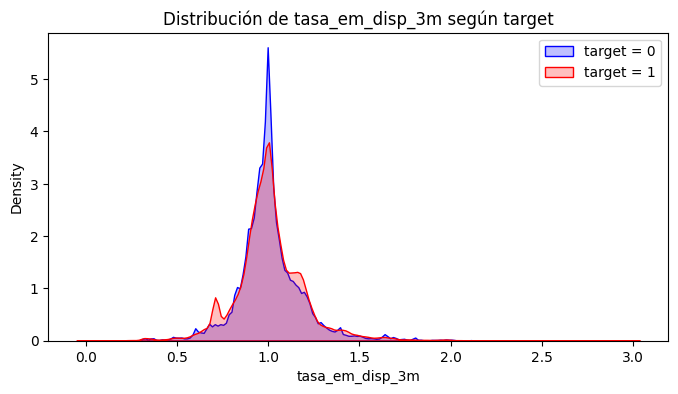

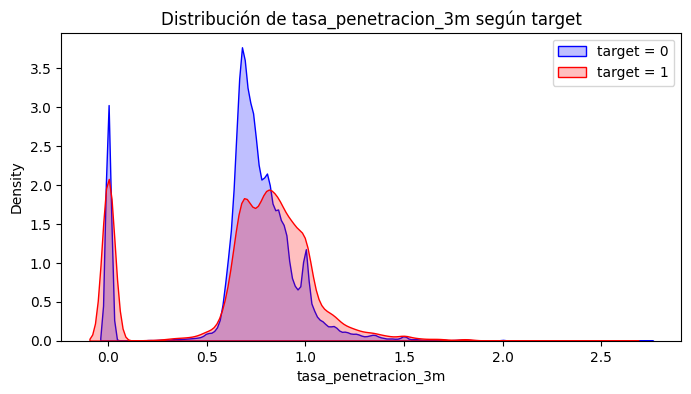

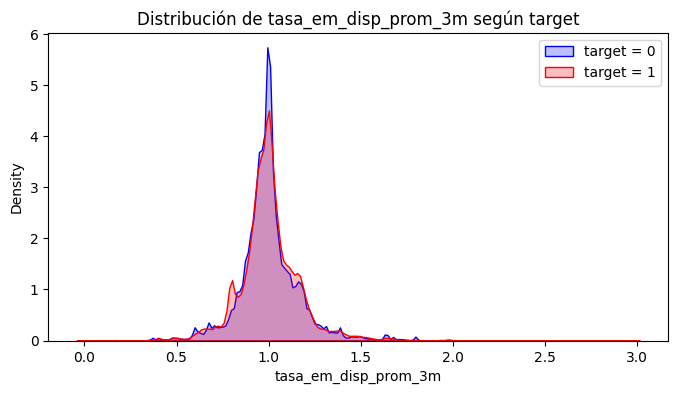

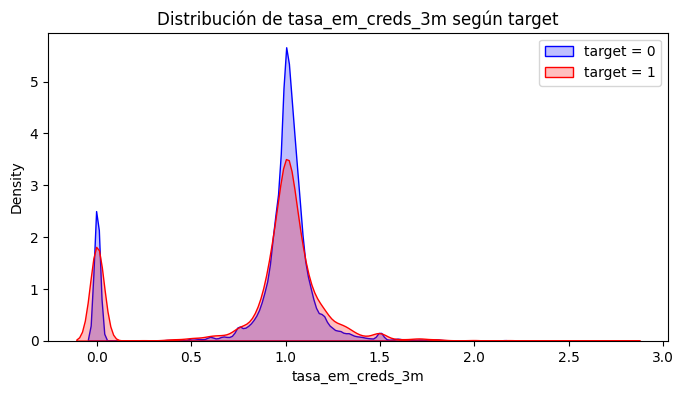

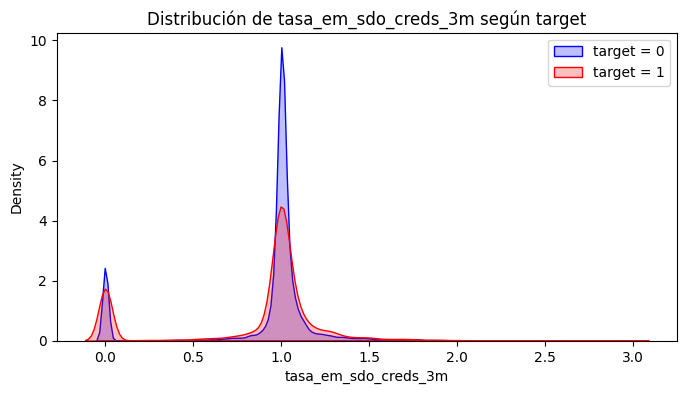

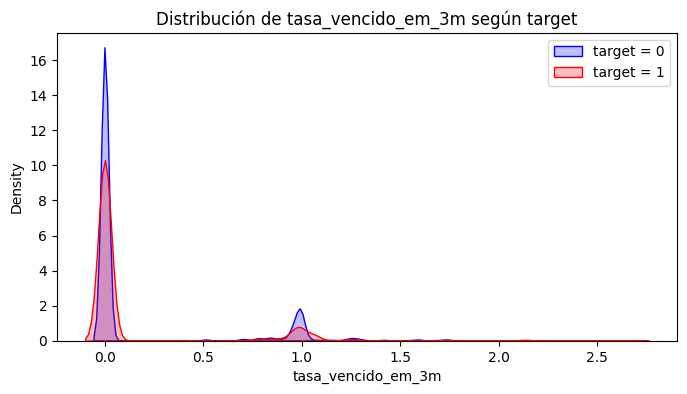

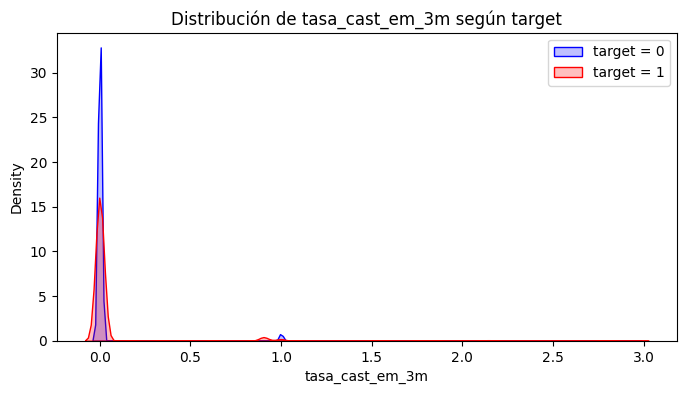

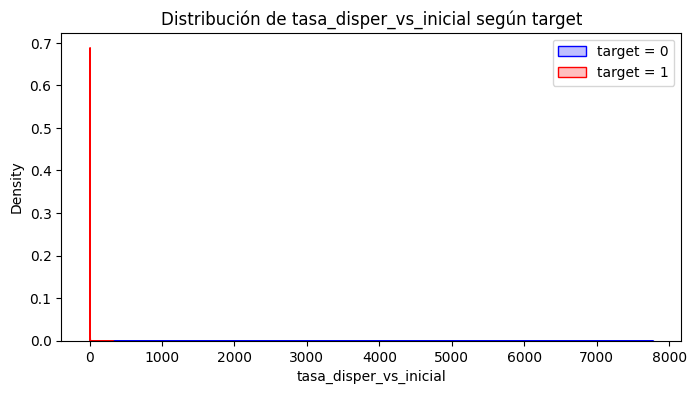

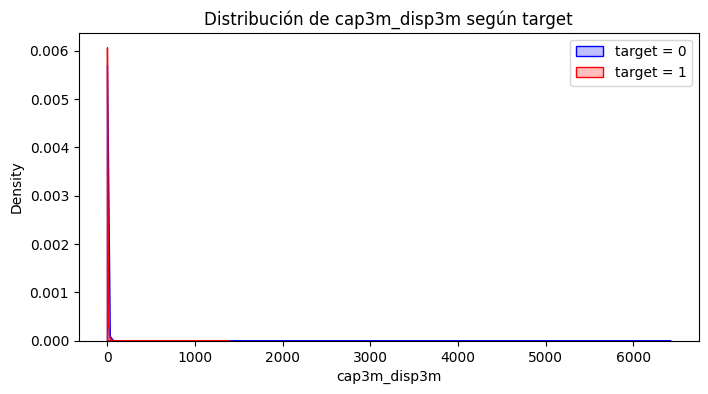

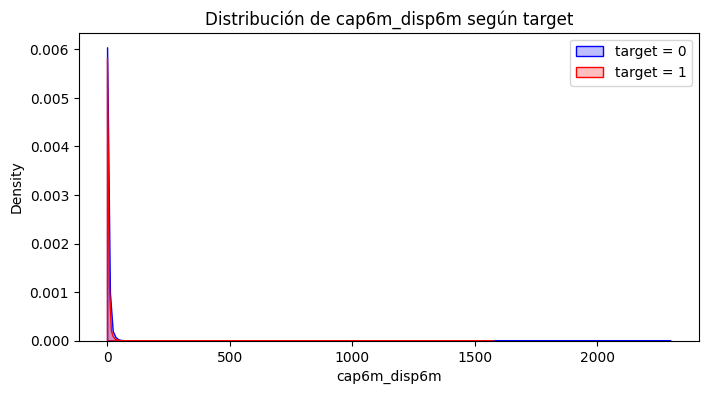

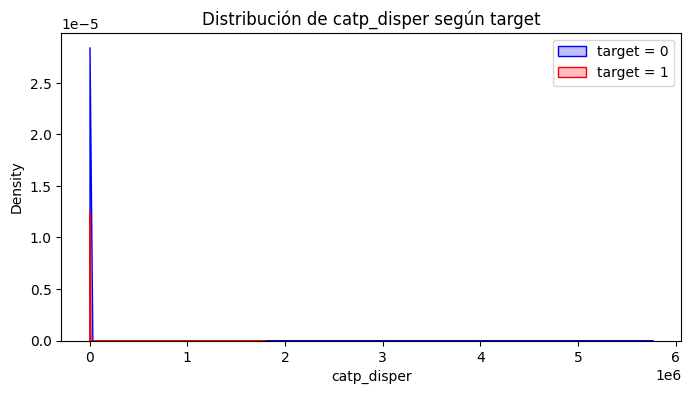

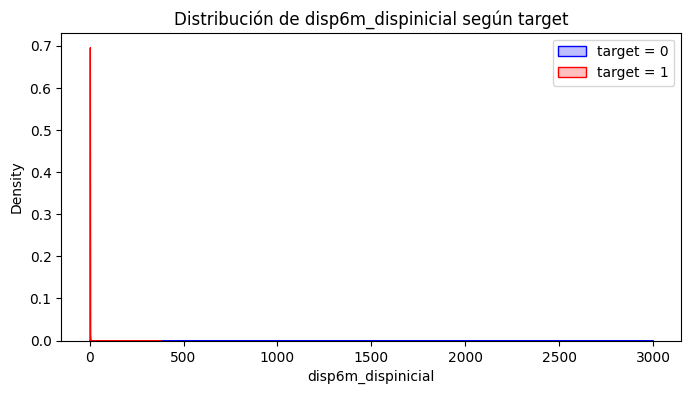

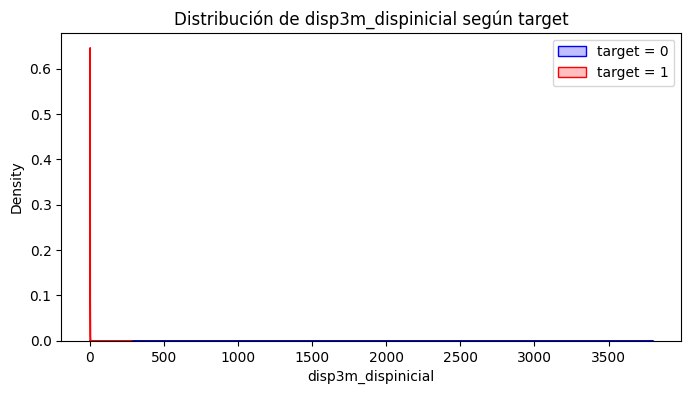

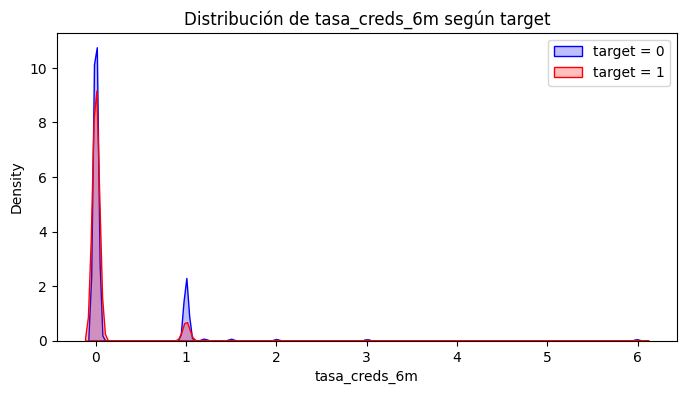

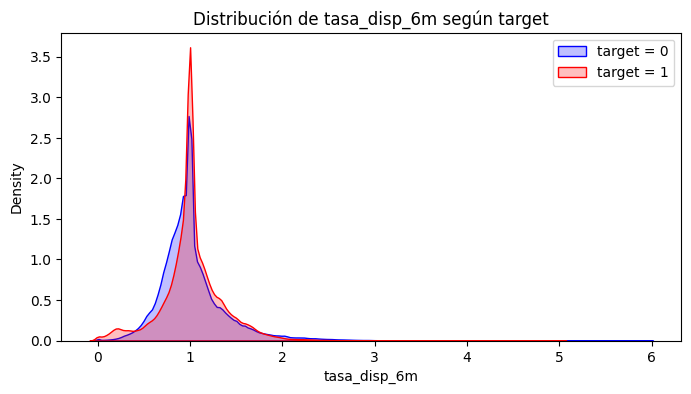

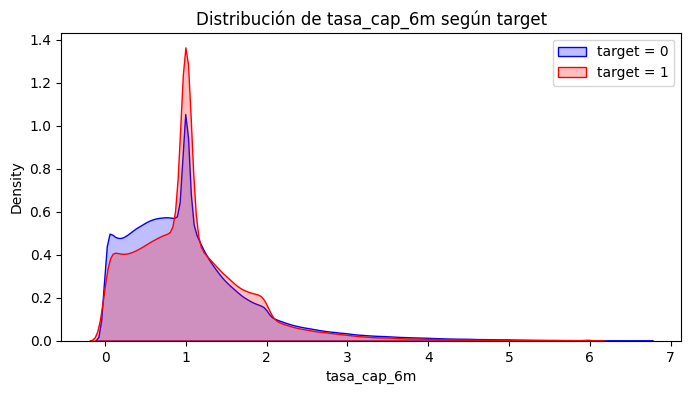

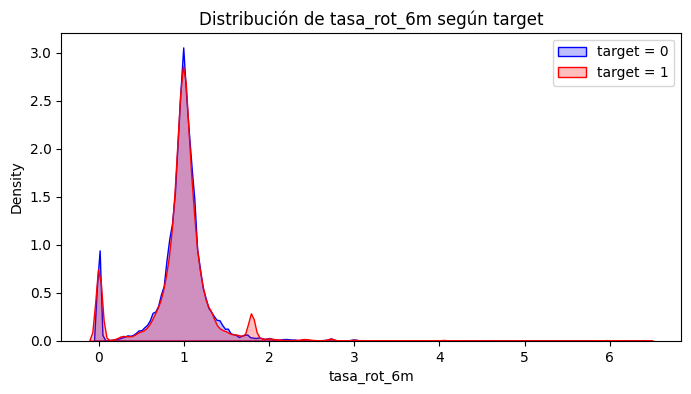

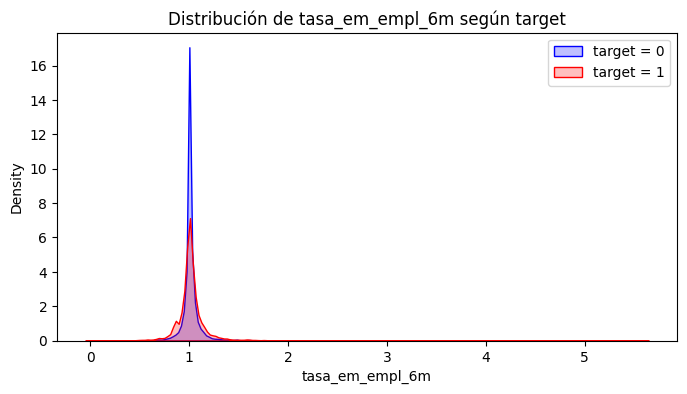

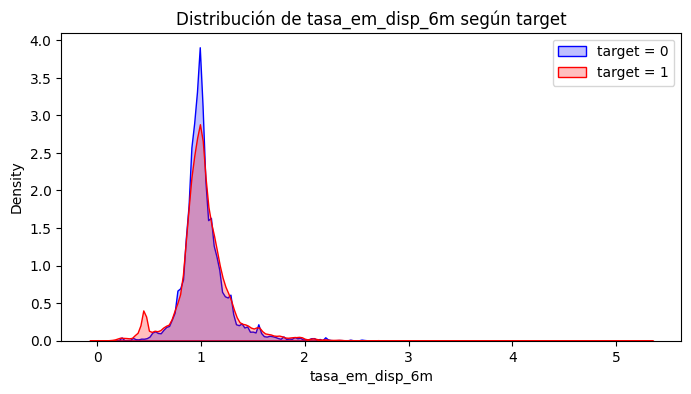

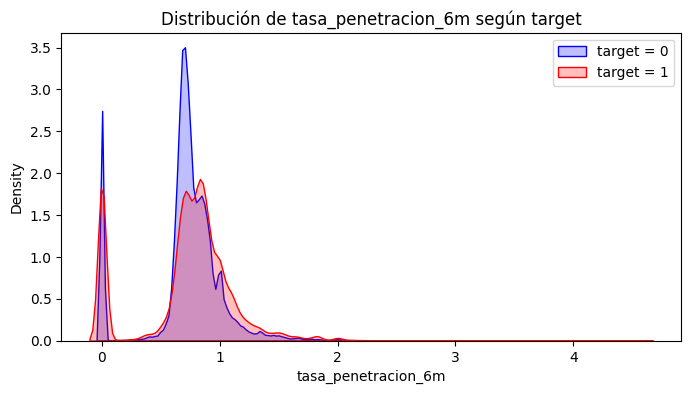

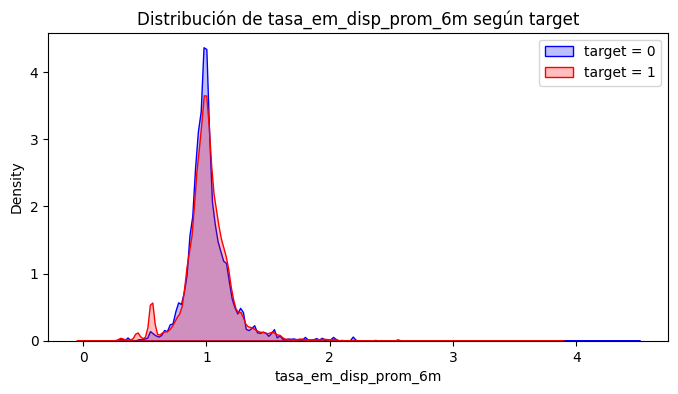

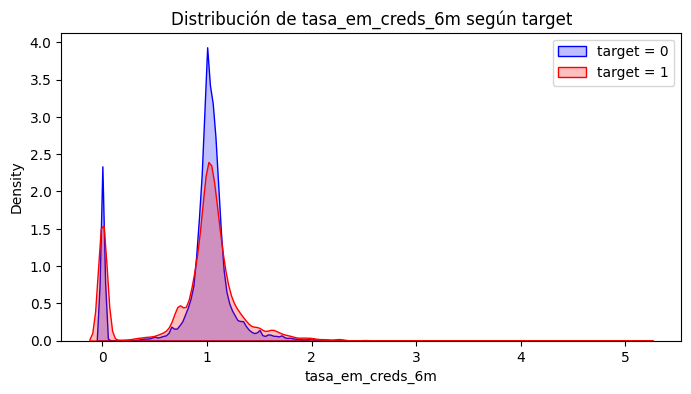

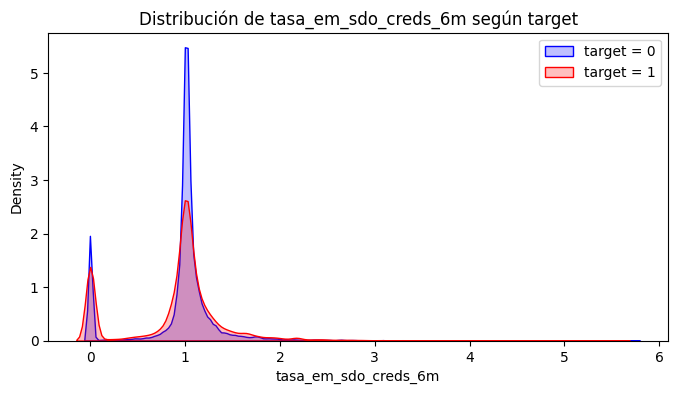

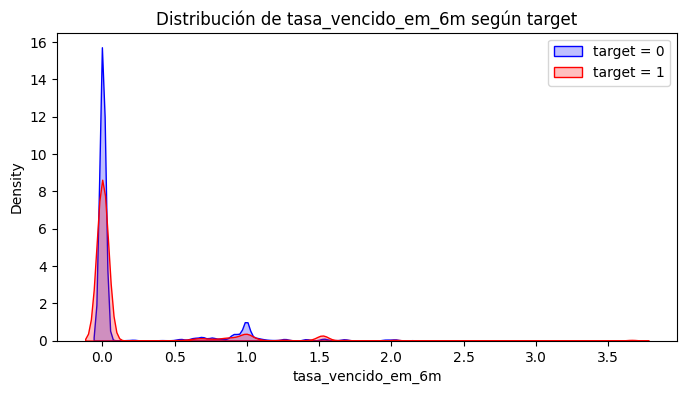

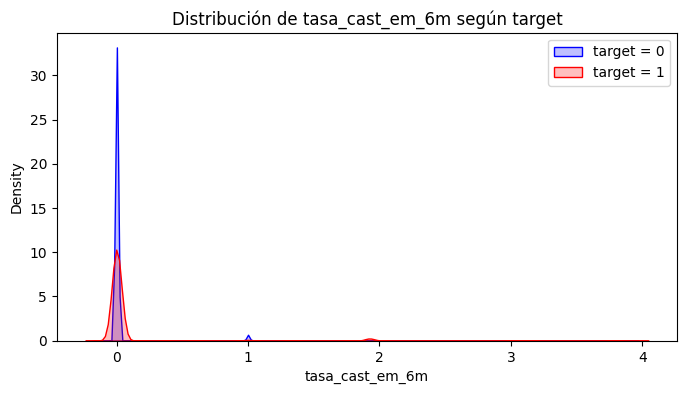

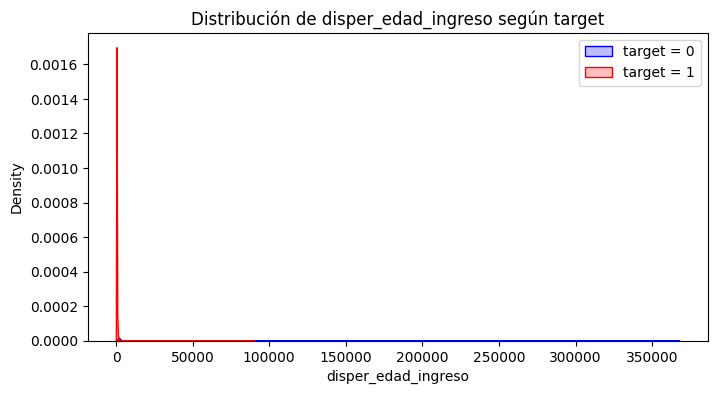

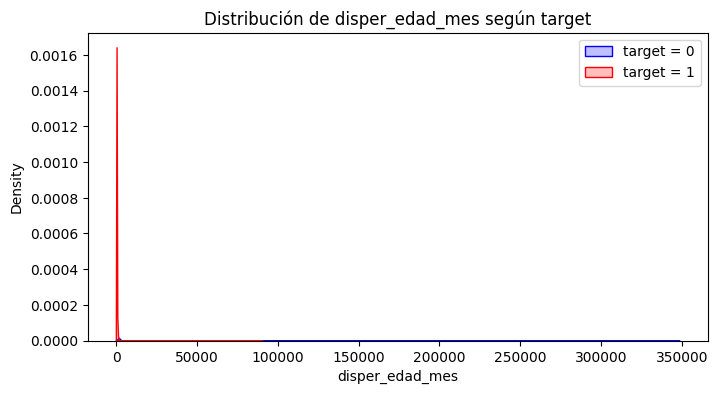

In [ ]:
# Filtrar DataFrames según el valor de 'target'
df_target_0 = datos_df[datos_df['target'] == 0]
df_target_1 = datos_df[datos_df['target'] == 1]

# Crear un gráfico KDE para cada variable en 'numericas', separando por 'target'
for col in numericas:
    plt.figure(figsize=(8, 4))

    # KDE para target == 0
    sns.kdeplot(df_target_0[col], fill=True, label="target = 0", color='blue')

    # KDE para target == 1
    sns.kdeplot(df_target_1[col], fill=True, label="target = 1", color='red')

    # Título y leyenda
    plt.title(f"Distribución de {col} según target")
    plt.legend()
    plt.show()


Primero entrenaremos el modelo considerando los outliers, si no se obtiene buen rendimiento, se entrenará haciendo transformación  logarítmica, por ejemplo, o bien eliminarlos.

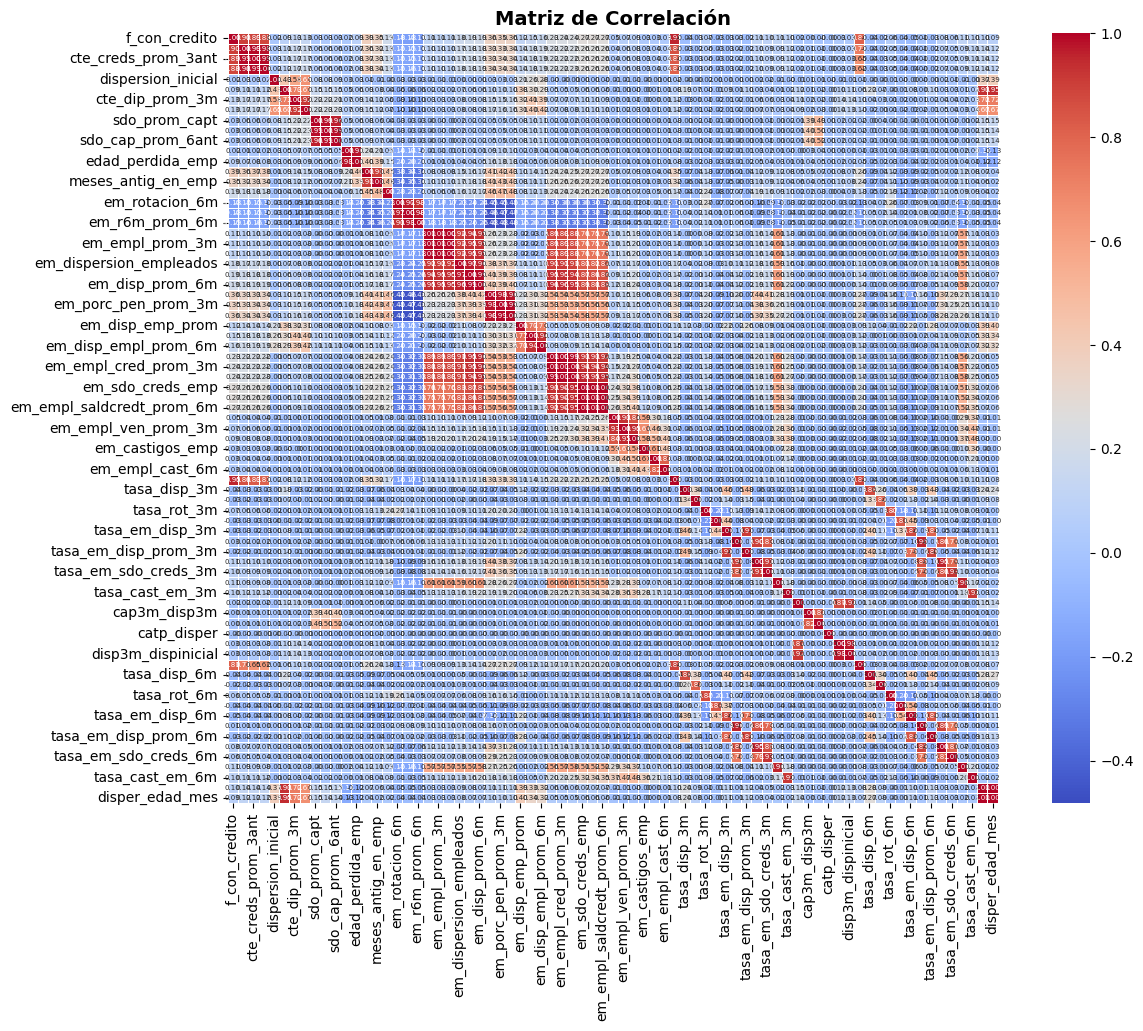

In [ ]:
#Correlación de variables numéricas
corr = datos_df[numericas].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True, cbar=True, annot_kws={"size": 5})

#sns.heatmap(round(datos_df.corr(),2),annot=True)

plt.title("Matriz de Correlación", fontsize=14, fontweight='bold')
plt.show()

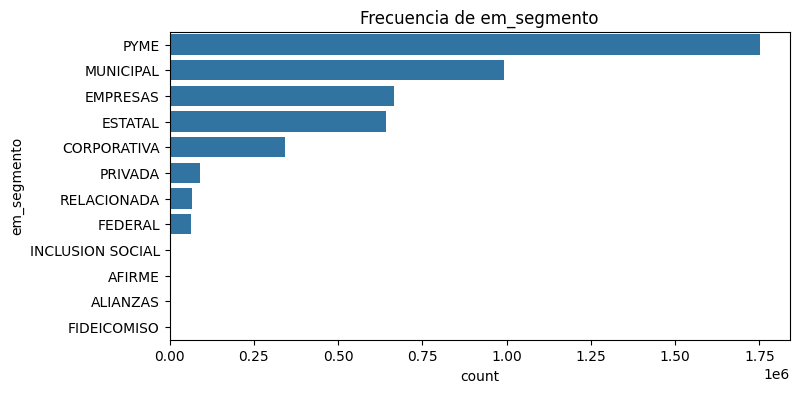

La columna em_tipo_gob no está en el DataFrame


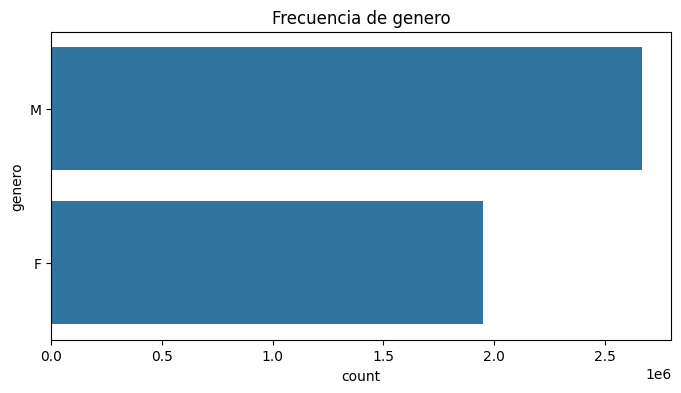

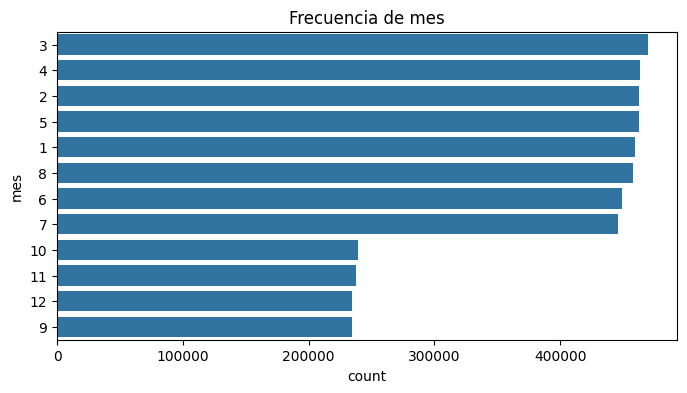

In [ ]:
# Gráficos de barras para variables categóricas

for col in categoricas:
    if col in datos_df.columns:  # Verifica que la columna existe antes de graficar
        plt.figure(figsize=(8, 4))
        sns.countplot(y=datos_df[col], order=datos_df[col].value_counts().index)
        plt.title(f"Frecuencia de {col}")
        plt.show()
    else:
        print(f"La columna {col} no está en el DataFrame")

In [48]:
categoricas = ['em_segmento', 'genero', 'mes']

In [16]:
datos_df[categoricas].describe(include="object").T

,count,unique,top,freq
em_segmento,7347882,5,PYME,2750916
genero,7347882,2,M,4293837
mes,7347882,12,3,693513



Análisis de la columna: em_segmento
Frecuencia:
 em_segmento
PYME           2750916
MUNICIPAL      1579637
ESTATAL        1121293
EMPRESAS       1018756
CORPORATIVO     877280
Name: count, dtype: int64
Porcentaje:
 em_segmento
PYME          37.44
MUNICIPAL     21.50
ESTATAL       15.26
EMPRESAS      13.86
CORPORATIVO   11.94
Name: proportion, dtype: float64


<ipython-input-31-296df5b64158>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col_cat, data=datos_df, palette="pastel")


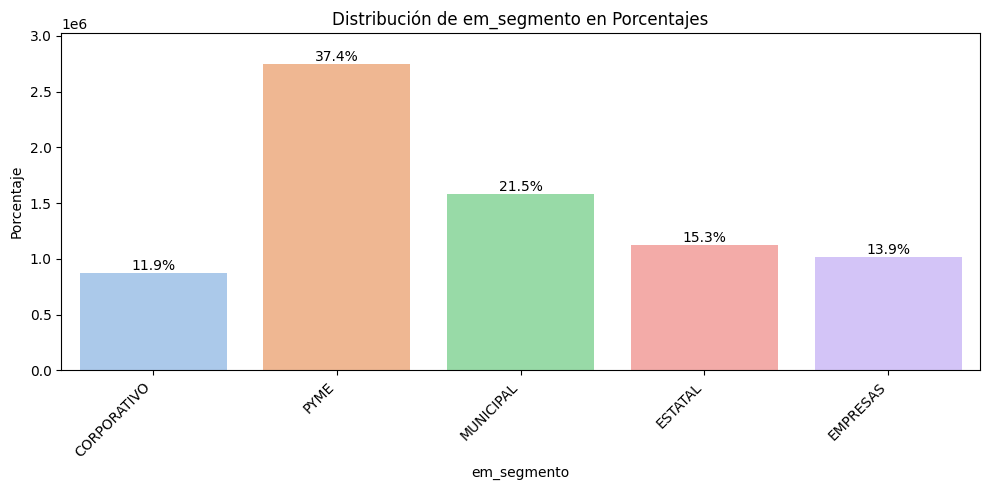


Análisis de la columna: genero
Frecuencia:
 genero
M    4293837
F    3054045
Name: count, dtype: int64
Porcentaje:
 genero
M   58.44
F   41.56
Name: proportion, dtype: float64


<ipython-input-31-296df5b64158>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col_cat, data=datos_df, palette="pastel")


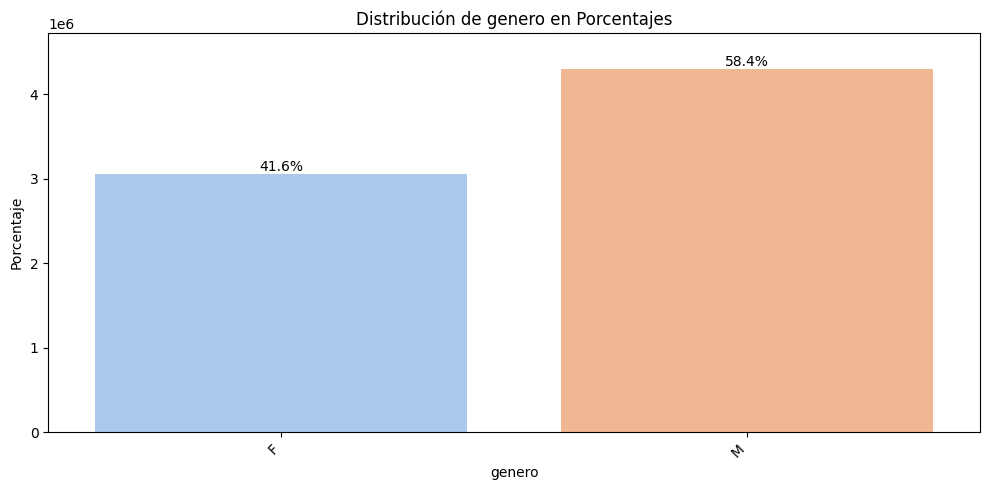


Análisis de la columna: mes
Frecuencia:
 mes
3     693513
8     686749
4     686251
2     684770
5     684667
1     680764
7     677390
6     674506
10    475549
11    471214
9     468560
12    463949
Name: count, dtype: int64
Porcentaje:
 mes
3    9.44
8    9.35
4    9.34
2    9.32
5    9.32
1    9.26
7    9.22
6    9.18
10   6.47
11   6.41
9    6.38
12   6.31
Name: proportion, dtype: float64


<ipython-input-31-296df5b64158>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col_cat, data=datos_df, palette="pastel")


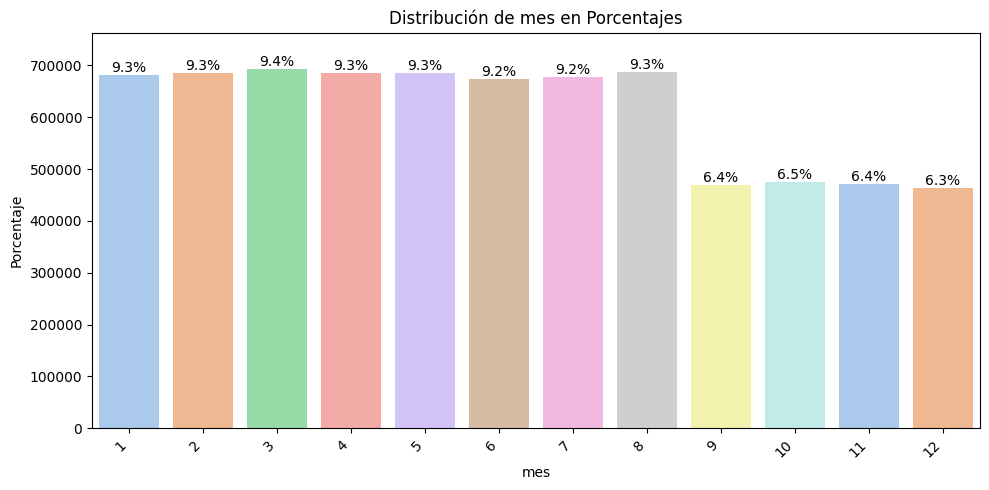

In [31]:
for col_cat in categoricas:
    plt.figure(figsize=(10, 5))  # Ajustar tamaño de la figura

    # Calcular frecuencia y porcentaje
    frecuencia = datos_df[col_cat].value_counts()
    porcentaje = datos_df[col_cat].value_counts(normalize=True) * 100  # Convertir a porcentaje

    print(f"\nAnálisis de la columna: {col_cat}")
    print("Frecuencia:\n", frecuencia)
    print("Porcentaje:\n", porcentaje)

    # Gráfico de barras con proporciones
    ax = sns.countplot(x=col_cat, data=datos_df, palette="pastel")

    # Agregar etiquetas de porcentaje sobre las barras
    for p in ax.patches:
        ax.annotate(f'{p.get_height()/len(datos_df)*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')

    plt.title(f"Distribución de {col_cat} en Porcentajes")
    plt.ylabel("Porcentaje")
    plt.xlabel(col_cat)

    # Ajuste para evitar que los nombres de las categorías se encimen
    plt.xticks(rotation=45, ha="right")  # Rota etiquetas y las alinea a la derecha si es necesario

    plt.ylim(0, max(frecuencia) * 1.1)  # Ajuste de escala para etiquetas
    plt.tight_layout()  # Optimiza el espacio de la gráfica
    plt.show()

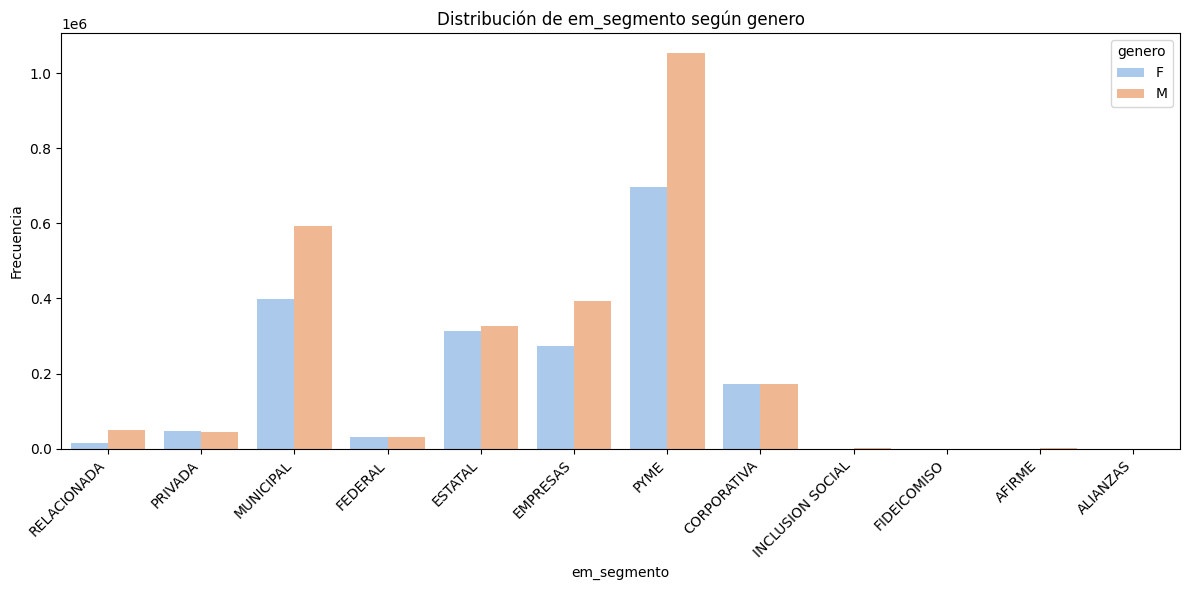

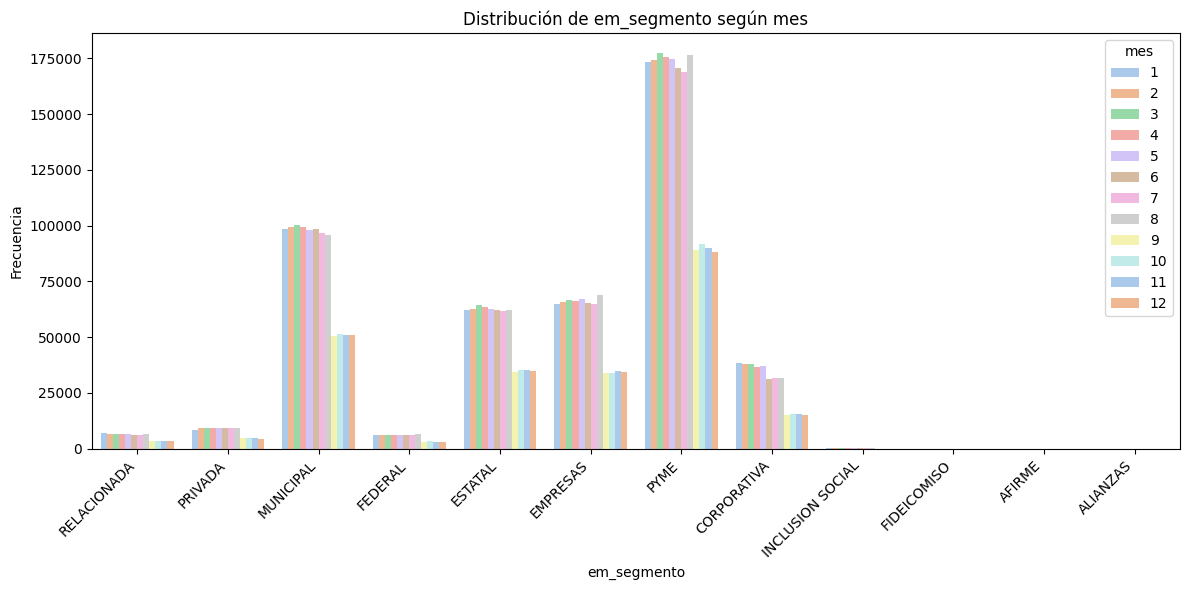

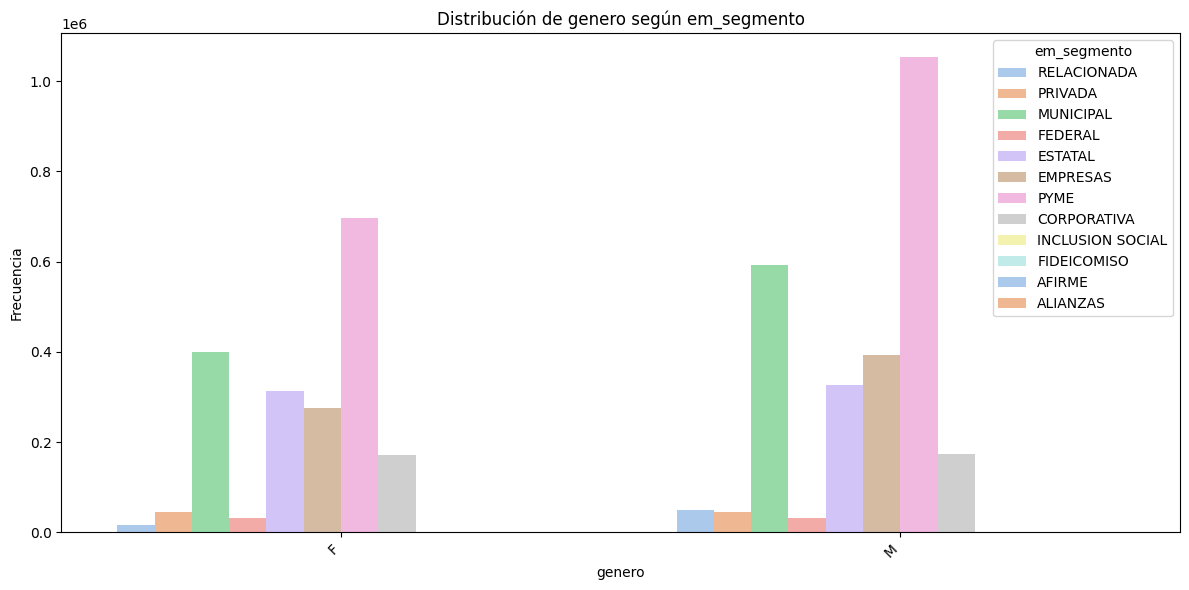

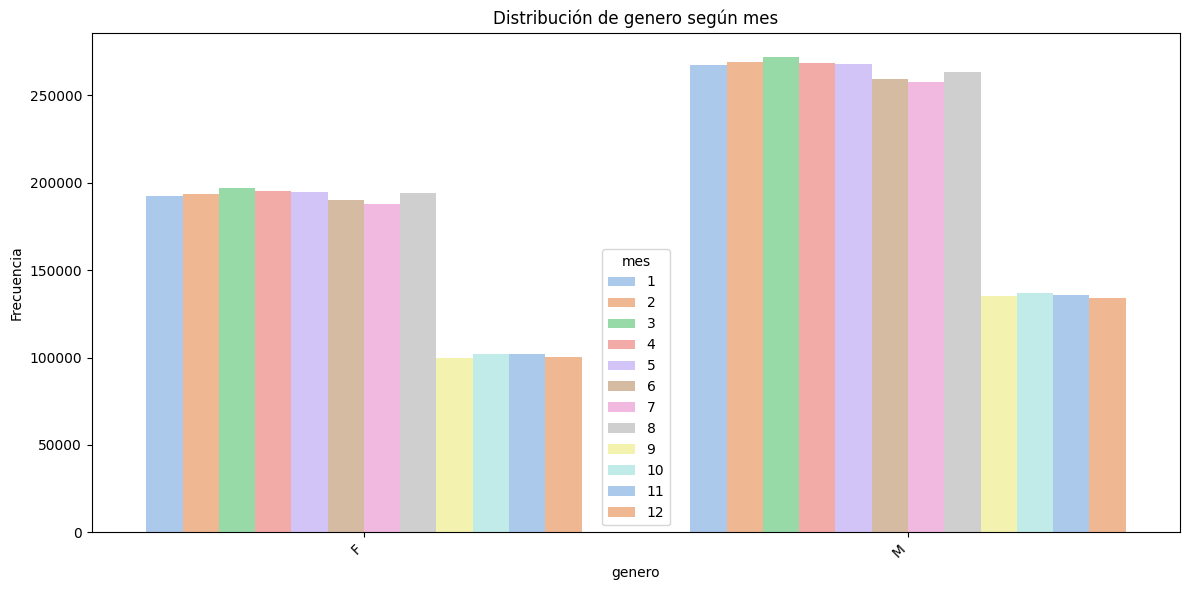

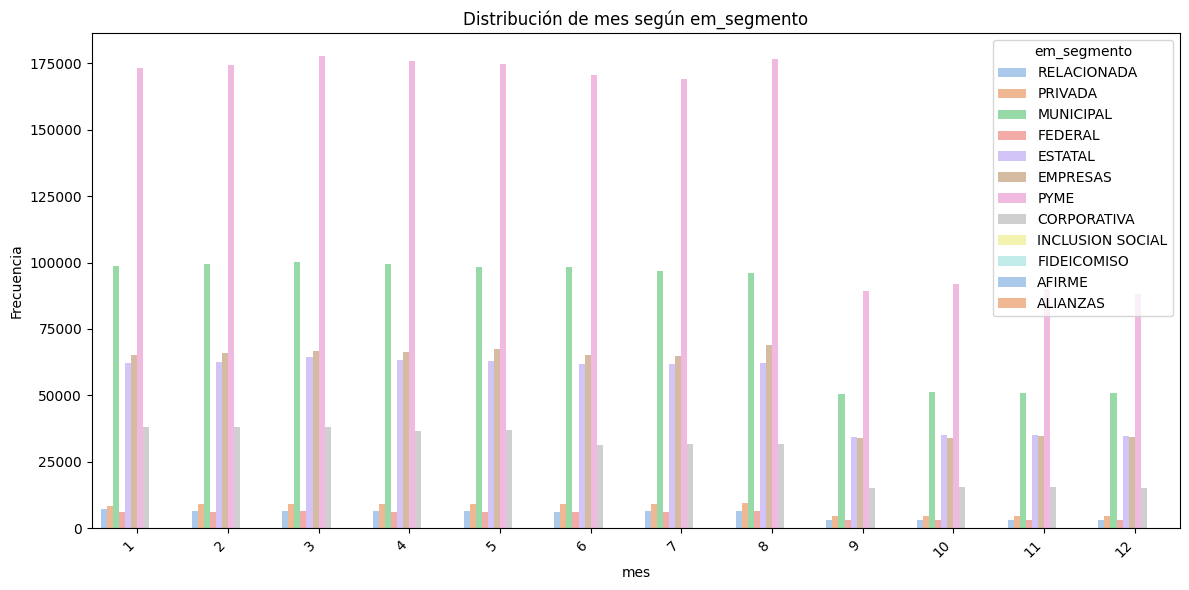

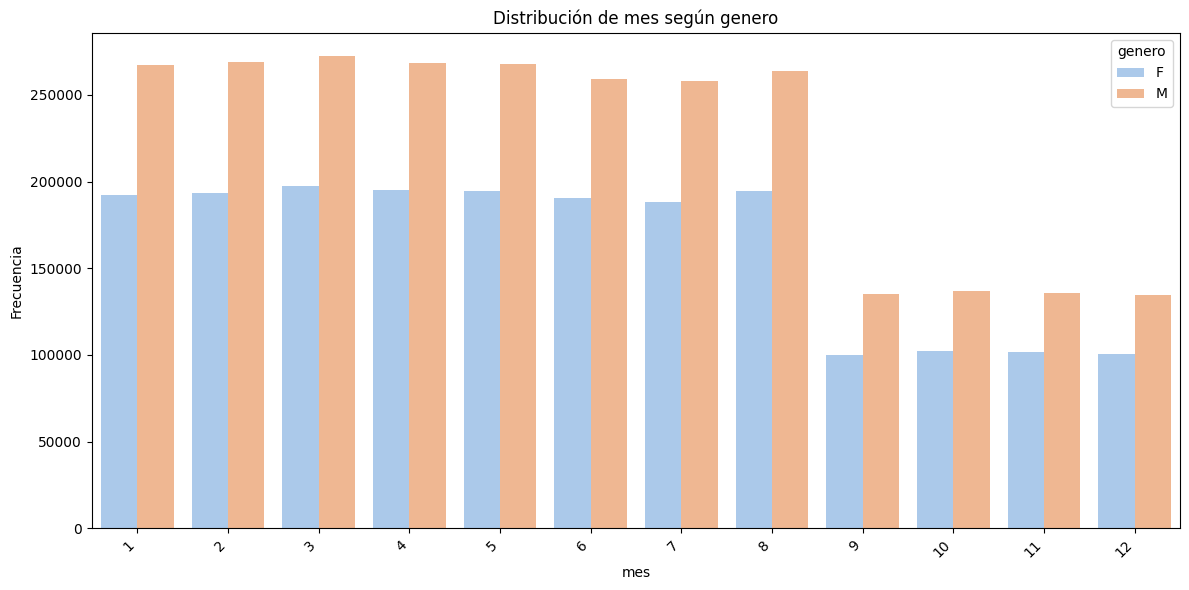

In [ ]:
# Análisis bivariado con gráfico de barras


for columna_1 in categoricas:
    for columna_2 in categoricas:
        if columna_1 != columna_2:
            plt.figure(figsize=(12, 6))  # Ajuste del tamaño de la figura

            ax = sns.countplot(x=columna_1, hue=columna_2, data=datos_df, palette="pastel")

            plt.title(f"Distribución de {columna_1} según {columna_2}")

            # Rota las etiquetas del eje X si hay muchas categorías
            plt.xticks(rotation=45, ha="right")

            plt.xlabel(columna_1)
            plt.ylabel("Frecuencia")

            # Ajusta automáticamente la disposición de los elementos en la figura
            plt.tight_layout()

            plt.show()

## **Ingeniería de Características**

La **ingeniería de características** (o feature engineering en inglés) es el proceso de transformar y crear nuevas características (o variables) a partir de los datos originales con el fin de mejorar el desempeño de un modelo de aprendizaje automático. Esto involucra tanto la creación de nuevas características como la transformación, selección y limpieza de las existentes para hacerlas más útiles para los algoritmos.

In [49]:
categoricas

['em_segmento', 'genero', 'mes']

Codificación de variables categóricas.

In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Copia del dataframe original
df_transformed = datos_df.copy()

# Definir las columnas que deben omitirse
columnas_omitidas = ['uuid_rec', 'mes_informacion', 'target', 'f_con_credito', 'creditos',
                     'cte_creds_prom_3ant', 'cte_creds_prom_6ant']

# Eliminar columnas no deseadas
df_transformed = df_transformed.drop(columns=columnas_omitidas, errors='ignore')

# Identificación de variables
num_cols = df_transformed.select_dtypes(include=[np.number]).columns.tolist()
bin_cols = [col for col in num_cols if set(df_transformed[col].dropna().unique()).issubset({0, 1})]  # Variables binarias
num_cols = list(set(num_cols) - set(bin_cols))  # Solo numéricas (excluye binarias)

cat_cols = df_transformed.select_dtypes(exclude=[np.number]).columns.tolist()  # Variables categóricas

# Escalar variables numéricas (considerando valores negativos)
# Agregar como nota


scaler = StandardScaler()
df_transformed[num_cols] = scaler.fit_transform(df_transformed[num_cols])

# One-Hot Encoding para variables categóricas (evita alta dimensionalidad)
encoder = OneHotEncoder(drop="first", sparse_output=False)  # Elimina una categoría para evitar colinealidad
encoded_cats = encoder.fit_transform(df_transformed[cat_cols])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(cat_cols))

# Concatenar datos transformados
df_transformed = df_transformed.drop(columns=cat_cols)  # Elimina originales categóricas
df_transformed = pd.concat([df_transformed, encoded_cat_df], axis=1)  # Une one-hot


In [51]:
df_transformed.columns

Index(['dispersion_inicial', 'dispersion', 'cte_dip_prom_3m',
       'cte_dip_prom_6m', 'sdo_prom_capt', 'sdo_cap_prom_3ant',
       'sdo_cap_prom_6ant', 'edad_ingreso', 'edad_perdida_emp',
       'meses_antig_en_bco', 'meses_antig_en_emp', 'em_antig_dispersando',
       'em_rotacion_6m', 'em_r6m_prom_3m', 'em_r6m_prom_6m', 'em_empleados',
       'em_empl_prom_3m', 'em_empl_prom_6m', 'em_dispersion_empleados',
       'em_disp_prom_3m', 'em_disp_prom_6m', 'em_porc_pen',
       'em_porc_pen_prom_3m', 'em_porc_pen_prom_6m', 'em_disp_emp_prom',
       'em_disp_empl_prom_3m', 'em_disp_empl_prom_6m', 'em_num_creds_emp',
       'em_empl_cred_prom_3m', 'em_empl_cred_prom_6m', 'em_sdo_creds_emp',
       'em_empl_saldcredt_prom_3m', 'em_empl_saldcredt_prom_6m',
       'em_vencido_emp', 'em_empl_ven_prom_3m', 'em_empl_ven_prom_6m',
       'em_castigos_emp', 'em_empl_cast_3m', 'em_empl_cast_6m',
       'tasa_creds_3m', 'tasa_disp_3m', 'tasa_cap_3m', 'tasa_rot_3m',
       'tasa_em_empl_3m', 'tasa_e

In [52]:
df_transformed.head()

,dispersion_inicial,dispersion,cte_dip_prom_3m,cte_dip_prom_6m,sdo_prom_capt,sdo_cap_prom_3ant,sdo_cap_prom_6ant,edad_ingreso,edad_perdida_emp,meses_antig_en_bco,...,mes_11,mes_12,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9
0,0.716970,0.369160,0.693744,0.829203,1.061745,1.606887,1.396039,2.130397,2.044011,1.112126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.505843,2.090951,3.542155,4.579078,31.208738,33.297776,38.663113,0.888178,1.164682,1.112126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.036525,0.386692,0.748874,0.939088,11.425389,10.156886,10.092045,1.354010,1.237960,1.112126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.657815,0.323382,0.550388,0.724775,2.104476,5.388083,9.393413,0.267068,0.578463,1.112126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.883740,1.165785,3.431650,4.372356,44.427056,45.051219,44.920230,0.888178,1.164682,1.112126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Modelos sin PCA

In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE  # Importar SMOTE

# Separar características (X) y target (y)
X = df_transformed  # Características
y = datos_df['target']  # Target original

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Balanceo de clases con SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)  # 'auto' ajusta automáticamente al 50% de las clases minoritarias
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


# Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Ajustar la clase minoritaria al 50% de la mayoritaria
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución después de SMOTE:")
print(y_train_res.value_counts())

In [ ]:
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE con menor generación de datos sintéticos
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Definir los modelos y sus hiperparámetros optimizados
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=500),
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {'max_depth': [3, 5, None], 'min_samples_split': [2, 5]}
    },
    'RandomForest': {
        'model': RandomForestClassifier(n_estimators=30, max_depth=5, n_jobs=-1),
        'params': {}
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=30, max_depth=3, use_label_encoder=False, eval_metric='logloss'),
        'params': {}
    },
    'SVM': {
        'model': SVC(probability=True),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    },
    'NeuralNetwork': {
        'model': MLPClassifier(max_iter=500),
        'params': {'hidden_layer_sizes': [(50,), (100,)], 'alpha': [0.0001, 0.001]}
    }
}

best_models = {}



In [ ]:

# Reducir el tamaño de X_train_res si es demasiado grande
sample_size = min(30000, len(X_train_res))
X_train_res_sample, y_train_res_sample = X_train_res.sample(sample_size, random_state=42), y_train_res.sample(sample_size, random_state=42)


In [ ]:

for name, mp in models.items():
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_res_sample, y_train_res_sample)
    best_models[name] = grid_search.best_estimator_
    print(f"Mejor modelo para {name}: {grid_search.best_params_}")

# Evaluación en conjunto de prueba
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=3)
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
    plt.plot(train_sizes, test_mean, 'o-', label='Validación')
    plt.title(f'Curva de Aprendizaje - {title}')
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('Precisión')
    plt.legend()
    plt.show()

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\nEvaluación del modelo {name}:")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))
    if y_prob is not None:
        print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

    # Graficar curva de aprendizaje solo si hay pocos datos
    if len(X_train_res_sample) <= 5000:
        plot_learning_curve(model, X_train_res_sample, y_train_res_sample, name)

## Con PCA

In [35]:
# Aplicar PCA
pca = PCA(n_components=0.95)  # Mantiene el 95% de la varianza explicada
pca_transformed = pca.fit_transform(df_transformed)

# Convertir resultado de PCA a DataFrame
df_pca = pd.DataFrame(pca_transformed, columns=[f'PC{i+1}' for i in range(pca_transformed.shape[1])])

# Mostrar varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Varianza explicada por cada componente principal:")
print(explained_variance)

# Mostrar el DataFrame transformado con PCA
print("\nDataFrame final con PCA aplicado:")
print(df_pca.head())

Varianza explicada por cada componente principal:
[0.2011027  0.0767406  0.07002702 0.06248906 0.05703677 0.04697697
 0.04602498 0.03971706 0.03533357 0.02719103 0.0264861  0.02477869
 0.02353916 0.02205914 0.02087443 0.01879983 0.01761537 0.01591847
 0.01512558 0.01495451 0.01446402 0.01375887 0.01334865 0.0080088
 0.007514   0.0069948  0.00558775 0.00524551 0.00463339 0.00416809
 0.00328994 0.0031564 ]

DataFrame final con PCA aplicado:
    PC1   PC2   PC3    PC4   PC5   PC6   PC7   PC8   PC9  PC10  ...  PC23  \
0 -0.45  3.26  2.05  -3.80 -1.15  0.22  1.01 -0.35  0.39  0.35  ...  0.89   
1  6.17  6.96 23.93 -14.52  8.04 -6.10 43.55  1.14  0.52 -3.10  ... -1.15   
2 -2.83 -1.99  9.11  -8.54  0.69 -2.05 14.54 -1.41 -2.49 -0.56  ... -0.02   
3  5.03  2.03  4.85  -3.21 -0.34 -1.27  8.74  0.17  0.71 -1.88  ...  0.27   
4  6.48  8.44 27.65 -18.38  9.28 -7.75 58.11  2.11 -0.10 -4.59  ... -3.03   

   PC24  PC25  PC26  PC27  PC28  PC29  PC30  PC31  PC32  
0  0.51 -0.33 -0.17 -0.23 -0.82 -0.2

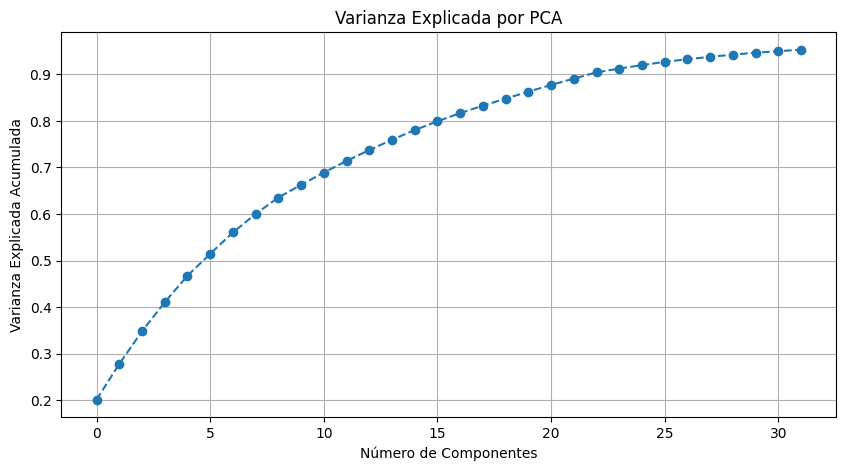

In [36]:

# Obtener la varianza explicada acumulada
explained_variance = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(explained_variance)

# Graficar la varianza acumulada
plt.figure(figsize=(10,5))
plt.plot(varianza_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por PCA')
plt.grid()
plt.show()


In [37]:
# Ver las cargas de las componentes principales
loadings = pca.components_

# Obtener los nombres de las variables originales después de One-Hot Encoding
# Para las variables categóricas codificadas
variables_originales = num_cols + list(encoder.get_feature_names_out(cat_cols))

# Crear un DataFrame de las cargas de las componentes principales y las variables
loadings_df = pd.DataFrame(loadings, columns=variables_originales)

# Mostrar el DataFrame con las cargas
print("Cargas de las Componentes Principales:")
print(loadings_df)

# Si deseas ver la contribución de cada variable a cada componente de forma ordenada
for i in range(loadings_df.shape[0]):  # Para cada componente
    print(f"\nComponent {i+1}:")
    print(loadings_df.iloc[i].sort_values(ascending=False))  # Ordena las cargas por importancia

Cargas de las Componentes Principales:
    tasa_creds_3m  tasa_em_creds_3m  em_porc_pen  em_empl_saldcredt_prom_3m  \
0            0.00              0.01         0.02                       0.02   
1            0.05              0.05         0.06                       0.07   
2            0.19              0.29         0.28                       0.26   
3           -0.07             -0.07        -0.10                      -0.11   
4            0.12              0.19         0.18                       0.16   
5           -0.04             -0.03        -0.04                      -0.04   
6           -0.06             -0.19        -0.10                      -0.08   
7           -0.05             -0.02        -0.03                      -0.03   
8           -0.03             -0.00        -0.03                      -0.03   
9            0.04              0.10         0.05                       0.04   
10          -0.03              0.01        -0.03                      -0.04   
11           

In [38]:
# Agregar comentarios

In [39]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score



In [40]:
# Obtener la varianza explicada acumulada
explained_variance = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(explained_variance)
varianza_acumulada

array([0.2011027 , 0.2778433 , 0.34787032, 0.41035938, 0.46739615,
       0.51437311, 0.5603981 , 0.60011516, 0.63544873, 0.66263977,
       0.68912587, 0.71390456, 0.73744371, 0.75950285, 0.78037729,
       0.79917711, 0.81679249, 0.83271096, 0.84783654, 0.86279105,
       0.87725507, 0.89101394, 0.9043626 , 0.9123714 , 0.91988539,
       0.92688019, 0.93246794, 0.93771345, 0.94234685, 0.94651494,
       0.94980488, 0.95296128])

In [41]:

# Número mínimo de componentes que explican el 95% de la varianza
num_componentes_optimos = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Número óptimo de componentes: {num_componentes_optimos}")


Número óptimo de componentes: 32


In [42]:

# Reducir el DataFrame a las componentes óptimas
df_pca_opt = df_pca.iloc[:, :num_componentes_optimos]
df_pca_opt.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32
0,-0.45,3.26,2.05,-3.80,-1.15,0.22,1.01,-0.35,0.39,0.35,...,0.89,0.51,-0.33,-0.17,-0.23,-0.82,-0.20,0.45,-0.66,0.26
1,6.17,6.96,23.93,-14.52,8.04,-6.10,43.55,1.14,0.52,-3.10,...,-1.15,0.48,-0.97,4.14,-1.59,0.29,-0.23,0.55,0.35,0.32
2,-2.83,-1.99,9.11,-8.54,0.69,-2.05,14.54,-1.41,-2.49,-0.56,...,-0.02,-0.18,-0.36,0.56,-1.03,-0.09,0.08,-0.08,-0.65,-0.11
3,5.03,2.03,4.85,-3.21,-0.34,-1.27,8.74,0.17,0.71,-1.88,...,0.27,-0.14,-0.81,0.87,-0.47,0.32,-0.13,0.38,-0.51,1.06
4,6.48,8.44,27.65,-18.38,9.28,-7.75,58.11,2.11,-0.10,-4.59,...,-3.03,0.42,-0.85,2.97,-0.72,0.23,-0.24,0.47,0.29,-0.09


In [43]:

# Definir la variable objetivo y las características
X = df_pca_opt  # Variables después de reducción con PCA
y = datos_df['target']  # Target original



In [44]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [45]:
# Manejar el desbalanceo con SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)



Entrenando LogisticRegression...
Accuracy del modelo LogisticRegression: 0.9574061107379879

Entrenando RandomForest...


KeyboardInterrupt: 

In [46]:
# Entrenar modelo de Regresión Logística
model = LogisticRegression(random_state=42)
model.fit(X_train_res, y_train_res)


LogisticRegression(random_state=42)

In [47]:

# Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [48]:
# Evaluación del modelo
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Matriz de confusión:
[[861016 545898]
 [ 16321  46342]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.61      0.75   1406914
           1       0.08      0.74      0.14     62663

    accuracy                           0.62   1469577
   macro avg       0.53      0.68      0.45   1469577
weighted avg       0.94      0.62      0.73   1469577

ROC AUC Score: 0.738907554367416


In [49]:
from sklearn.metrics import accuracy_score
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy del modelo: {accuracy}')


Accuracy del modelo: 0.6174280081955555


In [ ]:
#from sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import RandomForestClassifier


#from sklearn.svm import SVC
#import xgboost as xgb
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.naive_bayes import GaussianNB
#from sklearn.metrics import accuracy_score

# Crear un diccionario de modelos
#modelos = {
#    'LogisticRegression': LogisticRegression(random_state=42),
#    'RandomForest': RandomForestClassifier(random_state=42),
#    'SVM': SVC(random_state=42),
#    'XGBoost': xgb.XGBClassifier(random_state=42),
#    'KNN': KNeighborsClassifier(),
#    'DecisionTree': DecisionTreeClassifier(random_state=42),
#    'NaiveBayes': GaussianNB()
#}

# Ciclo para entrenar y evaluar todos los modelos
#for nombre_modelo, modelo in modelos.items():
#    print(f"Entrenando {nombre_modelo}...")

    # Entrenar el modelo
#    modelo.fit(X_train, y_train)

    # Hacer predicciones
#    y_pred = modelo.predict(X_test)

    # Evaluar el modelo
#    accuracy = accuracy_score(y_test, y_pred)

    # Imprimir los resultados
#    print(f'Accuracy del modelo {nombre_modelo}: {accuracy}\n')

**Sin PCA**

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE  # Importar SMOTE

# Separar características (X) y target (y)
X = df_transformed  # Características
y = datos_df['target']  # Target original

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:

# Balanceo de clases con SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)  # 'auto' ajusta automáticamente al 50% de las clases minoritarias
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)



In [21]:
# Crear y entrenar el modelo
model = LogisticRegression()
model.fit(X_train_res, y_train_res)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy del modelo: {accuracy}')


Accuracy del modelo: 0.7583726473672356



Importancia de las características (Regresión Logística):
                 Feature  Coefficient  Abs_Coefficient
8       edad_perdida_emp   -39.926414        39.926414
7           edad_ingreso    37.475530        37.475530
10    meses_antig_en_emp     6.742751         6.742751
69   disper_edad_ingreso    -3.634528         3.634528
27      em_num_creds_emp    -2.817693         2.817693
..                   ...          ...              ...
22   em_porc_pen_prom_3m    -0.015042         0.015042
40          tasa_disp_3m     0.013528         0.013528
60           tasa_rot_6m    -0.006830         0.006830
48  tasa_em_sdo_creds_3m    -0.006608         0.006608
54           catp_disper    -0.002701         0.002701

[87 rows x 3 columns]


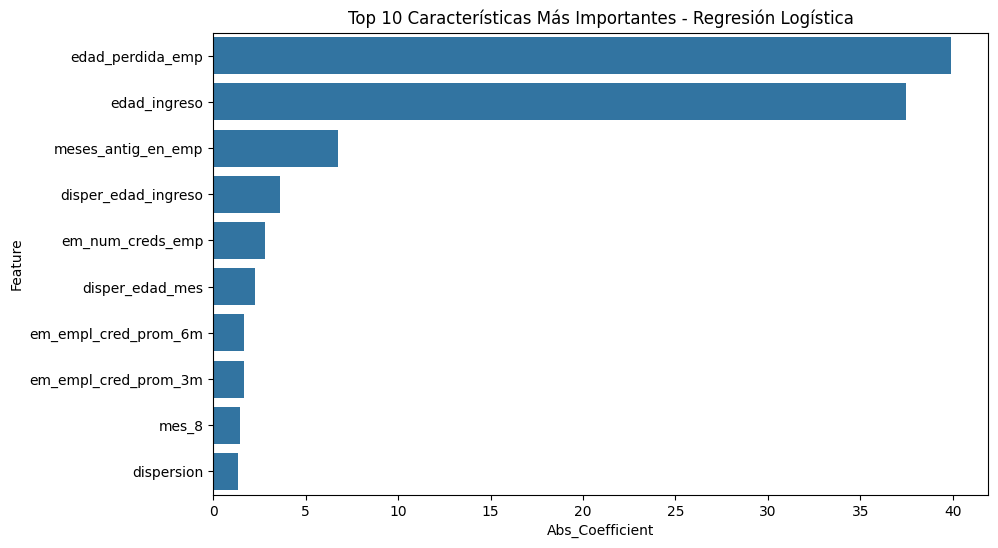

In [23]:

# Obtener los coeficientes del modelo
coeficientes = model.coef_[0]

# Crear un DataFrame con las características y sus coeficientes
feature_importance_df = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Coefficient': coeficientes
})

# Ordenar las características por la magnitud del coeficiente (valor absoluto)
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Mostrar las características más importantes
print("\nImportancia de las características (Regresión Logística):")
print(feature_importance_df)

# Graficar las características más importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_df.head(10))  # Mostrar top 10
plt.title("Top 10 Características Más Importantes - Regresión Logística")
plt.show()

In [24]:
# Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [25]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_ajustado = (y_pred_proba > 0.3).astype(int)  # Umbral de 0.3 en lugar de 0.5

In [29]:
# Evaluación del modelo
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score



print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Matriz de confusión:
[[1062634  344570]
 [  10520   51853]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86   1407204
           1       0.13      0.83      0.23     62373

    accuracy                           0.76   1469577
   macro avg       0.56      0.79      0.54   1469577
weighted avg       0.95      0.76      0.83   1469577

ROC AUC Score: 0.865907399606678


In [30]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Recall del modelo: {recall:.4f}')

Recall del modelo: 0.8313


Deben hacer un análisis de la métrica relevante. ¿Qué es más costoso para el negocio? Los falsos positivos o los negativos? Si son los primeros, hay que considerar la precisión, si son los negativos, la métrica más importante sería el recall.

1️⃣ Recall para la clase 1 (pérdida de empleo)
𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
=
𝑇
𝑃
𝑇
𝑃
+
𝐹
𝑁
=
51
,
853
51
,
853
+
10
,
520
=
0.83
Recall=
TP+FN
TP
​
 =
51,853+10,520
51,853
​
 =0.83
🔹 ✅ Excelente Recall (83%) → El modelo está capturando el 83% de los casos reales de pérdida de empleo, lo cual es bueno para tu objetivo.

2️⃣ Precisión para la clase 1
𝑃
𝑟
𝑒
𝑐
𝑖
𝑠
𝑖
𝑜
𝑛
=
𝑇
𝑃
𝑇
𝑃
+
𝐹
𝑃
=
51
,
853
51
,
853
+
344
,
570
=
0.13
Precision=
TP+FP
TP
​
 =
51,853+344,570
51,853
​
 =0.13
🔸 ❌ Baja Precisión (13%) → Muchos falsos positivos, lo que significa que hay muchas falsas alertas.

3️⃣ F1-score
𝐹
1
=
2
×
𝑃
𝑟
𝑒
𝑐
𝑖
𝑠
𝑖
𝑜
𝑛
×
𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
𝑃
𝑟
𝑒
𝑐
𝑖
𝑠
𝑖
𝑜
𝑛
+
𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
=
2
×
0.13
×
0.83
0.13
+
0.83
=
0.23
F1=2×
Precision+Recall
Precision×Recall
​
 =2×
0.13+0.83
0.13×0.83
​
 =0.23
🔹 Bajo F1-score (23%), pero como el recall es alto, el modelo cumple con la prioridad de minimizar falsos negativos.

4️⃣ ROC AUC Score
Un AUC de ROC alto sugiere que el modelo es bueno separando ambas clases. No lo has mencionado, pero si está por encima de 0.75 o 0.80, es aceptable.

🔹 Conclusión
✅ El modelo es bueno para el objetivo de minimizar falsos negativos porque:

Captura el 83% de los casos reales de pérdida de empleo (recall = 0.83).
Aunque tiene una precisión baja (13%), eso es aceptable en este caso, ya que es mejor tener falsos positivos que falsos negativos.
La matriz de confusión indica que el modelo identifica correctamente la mayoría de los empleados en riesgo.
🔸 ¿Cómo mejorarlo?
Si quieres reducir los falsos positivos sin sacrificar mucho recall, podrías:

Ajustar el umbral de decisión (por ejemplo, probar con 0.4 en lugar de 0.5).
Probar técnicas de balanceo de clases (como SMOTE o ajuste de class_weight en modelos como Random Forest o XGBoost).
Utilizar modelos más sofisticados como XGBoost o LightGBM para mejorar la separación entre clases.
📌 ¿Quieres que ajustemos el umbral para encontrar el punto óptimo entre precisión y recall? 🚀

Recomiendo utilizar la curva de aprendizaje que les proporciona una visualización clara del comportamiento del modelo en función del tamaño del conjunto de entrenamiento. Si la diferencia entre las puntuaciones de entrenamiento y validación es pequeña (menos del 5), indica que el modelo generaliza bien. Una diferencia del 20% o más entre el conjunto de entrenamiento y el conjunto de validación puede considerarse significativa y generalmente indica sobreajuste.

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Mejor modelo para LogisticRegression: {'C': 1, 'solver': 'liblinear'}
Mejor modelo para DecisionTree: {'max_depth': None, 'min_samples_split': 5}
Mejor modelo para RandomForest: {'max_depth': None, 'n_estimators': 100}

Evaluación del modelo LogisticRegression:
Matriz de confusión:
[[1045506  361698]
 [  10288   52085]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85   1407204
           1       0.13      0.84      0.22     62373

    accuracy                           0.75   1469577
   macro avg       0.56      0.79      0.53   1469577
weighted avg       0.95      0.75      0.82   1469577

ROC AUC Score: 0.8620949652377307


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

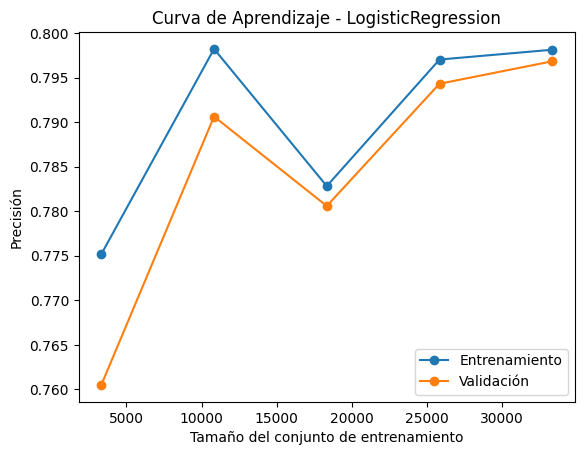


Evaluación del modelo DecisionTree:
Matriz de confusión:
[[1135876  271328]
 [  37425   24948]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88   1407204
           1       0.08      0.40      0.14     62373

    accuracy                           0.79   1469577
   macro avg       0.53      0.60      0.51   1469577
weighted avg       0.93      0.79      0.85   1469577

ROC AUC Score: 0.6100901659561008


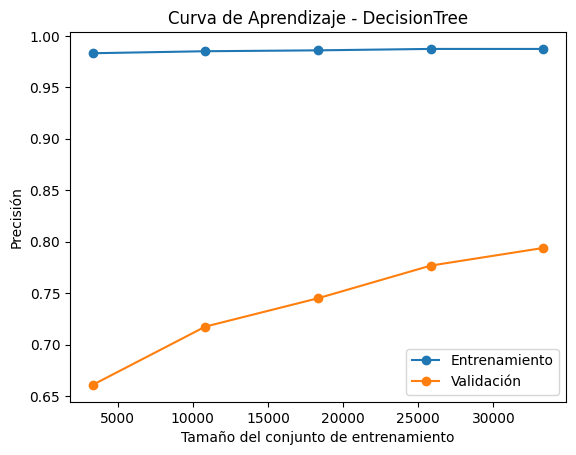


Evaluación del modelo RandomForest:
Matriz de confusión:
[[1118962  288242]
 [  23351   39022]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88   1407204
           1       0.12      0.63      0.20     62373

    accuracy                           0.79   1469577
   macro avg       0.55      0.71      0.54   1469577
weighted avg       0.94      0.79      0.85   1469577

ROC AUC Score: 0.7961881847144485


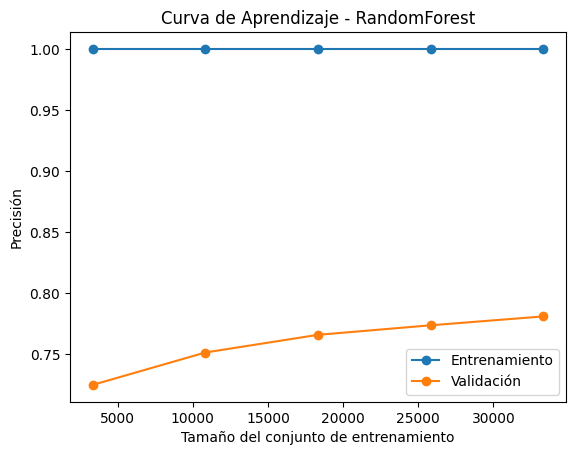

In [31]:
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Definir los modelos y sus hiperparámetros optimizados
models = {
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {'max_depth': [3, 5, None], 'min_samples_split': [2, 5]}
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {'n_estimators': [50, 100], 'max_depth': [5, None]}
    }
}

best_models = {}

# Reducir el tamaño de X_train_res si es demasiado grande
if len(X_train_res) > 50000:
    X_train_res_sample, y_train_res_sample = X_train_res.sample(50000, random_state=42), y_train_res.sample(50000, random_state=42)
else:
    X_train_res_sample, y_train_res_sample = X_train_res, y_train_res

for name, mp in models.items():
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_res_sample, y_train_res_sample)
    best_models[name] = grid_search.best_estimator_
    print(f"Mejor modelo para {name}: {grid_search.best_params_}")

# Evaluación en conjunto de prueba
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\nEvaluación del modelo {name}:")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

    # Curva de aprendizaje
    train_sizes, train_scores, test_scores = learning_curve(model, X_train_res_sample, y_train_res_sample, cv=3)
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
    plt.plot(train_sizes, test_mean, 'o-', label='Validación')
    plt.title(f'Curva de Aprendizaje - {name}')
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('Precisión')
    plt.legend()
    plt.show()


